<a href="https://colab.research.google.com/github/maulanataufiq30/Stone/blob/master/notebooka254078166%20new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
maulanataufiq_stone_2d_path = kagglehub.dataset_download('maulanataufiq/stone-2d')

print('Data source import complete.')


Using Colab cache for faster access to the 'stone-2d' dataset.
Data source import complete.


In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirby_2d25um_grayscale.raw - Copy (20).jpg
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygf10002.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygf0029.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygfr9000034.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirby_2d25um_grayscale.raw - Copy (21).png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbybg900013.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygf10023.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbybg900024.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygg900004.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbyb0009.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirby_2d25um_grayscale_filtered.gif - Copy (15).png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygr9000000.png
/kaggle/input/stone-2d/Raw_2D/mineral_class_8/Kirbygfg10028.png
/kaggle/input/stone-2d/Raw_2D/mineral

In [6]:
!pip install kagglehub kaggle opencv-python tifffile scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 18.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Buat direktori untuk menyimpan gambar augmented
os.makedirs('/kaggle/working/augmented', exist_ok=True)

# Konfigurasi augmentasi
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Path ke gambar asli (sesuaikan dengan struktur dataset Anda)
img_path = '/kaggle/input/stone-2d/Raw_2D/mineral_class_2/BanderaGray_2d25um_grayscale.raw.jpg'  # Ganti dengan path yang benar

# Muat gambar
img = load_img(img_path, target_size=(300, 300))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Hasilkan gambar augmented
i = 0
for batch in datagen.flow(x, batch_size=1,
                         save_to_dir='/kaggle/working/augmented',
                         save_prefix='banderab3',
                         save_format='jpeg'):
    i += 1
    if i > 20:  # Hasilkan 20 variasi per gambar
        break

print("Augmentasi selesai! Gambar disimpan di /kaggle/working/augmented/")

Augmentasi selesai! Gambar disimpan di /kaggle/working/augmented/


In [ ]:
import zipfile
import os

# Path ke folder yang ingin didownload
folder_path = '/kaggle/working/augmented'
zip_path = '/kaggle/working/augmented_images.zip'

# Buat file ZIP
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            # Menyimpan file dengan struktur folder yang relatif
            arcname = os.path.relpath(file_path, folder_path)
            zipf.write(file_path, arcname)

print(f"Folder {folder_path} telah dikompres menjadi {zip_path}")
print("Silakan download file ZIP melalui tab 'Data' -> 'Output' di panel kanan")

Folder /kaggle/working/augmented telah dikompres menjadi /kaggle/working/augmented_images.zip
Silakan download file ZIP melalui tab 'Data' -> 'Output' di panel kanan


In [ ]:
from PIL import Image
import numpy as np
import os
import tifffile
from pathlib import Path
from skimage import io, transform # Added skimage import

def convert_to_tiff(input_dir, output_dir):
    """Convert RAW/JPG/GIF images to TIFF format"""
    # Create output directory structure
    for root, dirs, files in os.walk(input_dir):
        for dir_name in dirs:
            Path(os.path.join(output_dir, dir_name)).mkdir(parents=True, exist_ok=True)

    supported_formats = ('.raw', '.jpg', '.jpeg', '.gif')

    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(supported_formats):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, input_dir)
                output_subdir = os.path.join(output_dir, relative_path)

                # Convert based on file type
                try:
                    if file.lower().endswith(('.raw')):
                        # RAW conversion (need to specify parameters)
                        convert_raw_to_tiff(input_path, output_subdir)

                    elif file.lower().endswith(('.jpg', '.jpeg', '.gif')):
                        # Standard image conversion
                        convert_image_to_tiff(input_path, output_subdir)

                except Exception as e:
                    print(f"Error converting {input_path}: {str(e)}")
                    continue

def convert_raw_to_tiff(raw_path, output_dir, width=2048, height=2048, dtype='uint16'):
    """Convert raw binary file to TIFF stack"""
    # Read raw binary data
    with open(raw_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=dtype)

    # Calculate number of slices
    num_slices = raw_data.size // (width * height)
    volume = raw_data[:width*height*num_slices].reshape((num_slices, height, width))

    # Save as TIFF stack
    output_path = os.path.join(output_dir, f"{Path(raw_path).stem}.tif")
    tifffile.imwrite(
        output_path,
        volume,
        metadata={'axes': 'ZYX'},
        imagej=True
    )

def convert_image_to_tiff(img_path, output_dir):
    """Convert JPG/GIF to TIFF stack"""
    img = Image.open(img_path)

    # Handle animated GIF
    if img_path.lower().endswith('.gif'):
        frames = []
        try:
            while True:
                frames.append(img.copy())
                img.seek(img.tell() + 1)
        except EOFError:
            pass

        if len(frames) > 1:
            volume = np.stack([np.array(frame.convert('L')) for frame in frames])
        else:
            volume = np.expand_dims(np.array(img.convert('L')), 0)
    else:
        volume = np.expand_dims(np.array(img.convert('L')), 0)

    # Save as TIFF
    output_path = os.path.join(output_dir, f"{Path(img_path).stem}.tif")
    tifffile.imwrite(
        output_path,
        volume,
        metadata={'axes': 'ZYX'},
        imagej=True
    )

def load_ct_volume(path, target_size=(64, 64, 64)):
    # Membaca citra micro-CT 3D (format .tiff stack)
    slices = [imread(os.path.join(path, f)) for f in sorted(os.listdir(path)) if f.endswith('.tif')]
    volume = np.stack(slices, axis=0)

    # Normalisasi [0, 1]
    volume = volume.astype('float32') / 255.0

    # Resize volume ke target_size (gunakan interpolasi trilinear)
    volume = transform.resize(volume, target_size, mode='constant', anti_aliasing=True)
    return volume


def prepare_dataset(data_dir, classes, samples_per_class=40): # Defining prepare_dataset before it is called
    volumes = []
    labels = []
    # mineral_classes = os.listdir(data_dir) # This line is removed and mineral_classes replaced with classes in for loop

    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        for sample in os.listdir(class_path)[:samples_per_class]:
            volume = load_ct_volume(os.path.join(class_path, sample))
            volumes.append(volume)
            labels.append(class_idx)

    return np.array(volumes), np.array(labels)

# ----------------------------------------
# MODIFIED PREPROCESSING PIPELINE
# ----------------------------------------
# Step 1: Convert raw data to TIFF
input_data_dir = "/kaggle/input/stone_3D/Raw_3D"
converted_data_dir = "/kaggle/working/convert data"

convert_to_tiff(input_data_dir, converted_data_dir)

# Step 2: Use converted TIFFs for preprocessing
# Assuming 'classes' is a list of mineral classes
#classes = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3', 'mineral_class_4', 'mineral_class_5', 'mineral_class_6', 'mineral_class_7', 'mineral_class_8','mineral_class_9','mineral_class_10'] # Added classes list. Replace with your actual mineral classes.
#X, y = prepare_dataset(converted_data_dir, classes, samples_per_class=40) # Calling the prepare_dataset function here

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

# Set path
input_base = "/kaggle/input/stone-3d/Raw_3D"
output_base = "/kaggle/working/Raw_3D_tiff"

# Create output directory
os.makedirs(output_base, exist_ok=True)

# Process all classes
for class_name in tqdm(os.listdir(input_base), desc="Classes"):
    class_path = os.path.join(input_base, class_name)

    if not os.path.isdir(class_path):
        continue

    # Create output class directory
    output_class_path = os.path.join(output_base, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    # Process all samples
    for sample_dir in tqdm(os.listdir(class_path), desc=f"Samples in {class_name}", leave=False):
        sample_path = os.path.join(class_path, sample_dir)

        if not os.path.isdir(sample_path):
            continue

        # Create output sample directory
        output_sample_path = os.path.join(output_class_path, sample_dir)
        os.makedirs(output_sample_path, exist_ok=True)

        # Process all images in sample directory
        for img_file in os.listdir(sample_path):
            img_path = os.path.join(sample_path, img_file)

            if os.path.isdir(img_path):
                continue

            # Prepare output filename
            filename, ext = os.path.splitext(img_file)
            output_path = os.path.join(output_sample_path, f"{filename}.tif")

            try:
                # Special handling for GIF (extract first frame)
                if ext.lower() in ['.gif', '.giff']:
                    gif = Image.open(img_path)
                    gif.seek(0)
                    frame = np.array(gif.convert('RGB'))
                    cv2.imwrite(output_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR),
                                [cv2.IMWRITE_TIFF_COMPRESSION, 5])
                    gif.close()

                # Handle all other image formats
                else:
                    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

                    # Preserve alpha channel if exists
                    if img.shape[2] == 4:
                        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
                    else:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                    # Save with LZW compression
                    cv2.imwrite(output_path, img, [cv2.IMWRITE_TIFF_COMPRESSION, 5])

            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")

# Compress output
#print("\nCompressing output...")
#os.system(f"cd /kaggle/working && zip -r -q Raw_3D_tiff.zip Raw_3D_tiff")

#print("\nConversion complete!")
#print(f"Output ZIP: /kaggle/working/Raw_3D_tiff.zip")

Samples in mineral_class_4:   0%|          | 0/21 [00:00<?, ?it/s]
                                                                  
Samples in mineral_class_1:   0%|          | 0/27 [00:00<?, ?it/s]
                                                                  
Samples in mineral_class_2:   0%|          | 0/45 [00:00<?, ?it/s]
                                                                  
Samples in mineral_class_5:   0%|          | 0/21 [00:00<?, ?it/s]
                                                                  
Samples in mineral_class_8:   0%|          | 0/21 [00:00<?, ?it/s]
                                                                  
Samples in mineral_class_9:   0%|          | 0/21 [00:00<?, ?it/s]
                                                                  
Samples in mineral_class_6:   0%|          | 0/21 [00:00<?, ?it/s]
                                                                  
Classes: 100%|██████████| 10/10 [00:00<00:00, 38.99it/s]      

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import tifffile
from skimage import io, transform
from tqdm import tqdm
import zipfile

# ======================================================================
# FUNGSI KONVERSI UTAMA (DIMODIFIKASI UNTUK KAGGLE)
# ======================================================================

def convert_to_tiff(input_dir, output_dir):
    """Convert RAW/JPG/GIF/PNG images to TIFF format (Kaggle version)"""
    # Create output directory structure
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Supported formats
    supported_formats = ('.raw', '.jpg', '.jpeg', '.gif', '.png', '.tif', '.tiff')

    for root, dirs, files in os.walk(input_dir):
        for file in tqdm(files, desc=f"Processing {os.path.basename(root)}"):
            if file.lower().endswith(supported_formats):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, input_dir)
                output_subdir = os.path.join(output_dir, relative_path)
                Path(output_subdir).mkdir(parents=True, exist_ok=True)

                try:
                    if file.lower().endswith(('.raw')):
                        convert_raw_to_tiff(input_path, output_subdir)
                    else:
                        convert_image_to_tiff(input_path, output_subdir)
                except Exception as e:
                    print(f"Error converting {input_path}: {str(e)}")

def convert_raw_to_tiff(raw_path, output_dir, width=2048, height=2048, dtype='uint16'):
    """Convert raw binary file to TIFF stack"""
    # Read raw binary data
    with open(raw_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=dtype)

    # Calculate number of slices
    num_slices = raw_data.size // (width * height)
    volume = raw_data[:width*height*num_slices].reshape((num_slices, height, width))

    # Save as TIFF stack
    output_path = os.path.join(output_dir, f"{Path(raw_path).stem}.tif")
    tifffile.imwrite(
        output_path,
        volume,
        metadata={'axes': 'ZYX'},
        imagej=True
    )

def convert_image_to_tiff(img_path, output_dir):
    """Convert JPG/GIF/PNG to TIFF"""
    if img_path.lower().endswith('.gif'):
        # Handle animated GIF
        gif = Image.open(img_path)
        frames = []
        try:
            while True:
                gif.seek(gif.tell())
                frames.append(gif.copy())
                gif.seek(gif.tell() + 1)
        except EOFError:
            pass

        if len(frames) > 0:
            volume = np.stack([np.array(frame.convert('L')) for frame in frames])
            output_path = os.path.join(output_dir, f"{Path(img_path).stem}.tif")
            tifffile.imwrite(
                output_path,
                volume,
                metadata={'axes': 'ZYX'},
                imagej=True
            )
    else:
        # Handle other image formats
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        # Preserve alpha channel if exists
        if img is not None:
            if len(img.shape) == 3 and img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
            elif len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            elif len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

            output_path = os.path.join(output_dir, f"{Path(img_path).stem}.tif")
            cv2.imwrite(output_path, img, [cv2.IMWRITE_TIFF_COMPRESSION, 5])

# ======================================================================
# FUNGSI LOADING & PREPROCESSING (DIMODIFIKASI UNTUK KAGGLE)
# ======================================================================

def load_ct_volume(path, target_size=(64, 64, 64)):
    """Load 3D CT volume from folder of TIFF slices"""
    # Get sorted list of TIFF files
    tiff_files = sorted([f for f in os.listdir(path) if f.endswith('.tif')])

    if not tiff_files:
        raise ValueError(f"No TIFF files found in {path}")

    # Read slices
    slices = [io.imread(os.path.join(path, f)) for f in tiff_files]
    volume = np.stack(slices, axis=0)

    # Normalize [0, 1]
    volume = volume.astype('float32') / 255.0

    # Resize volume
    volume = transform.resize(volume, target_size, mode='constant', anti_aliasing=True)
    return volume

def prepare_dataset(data_dir, classes, samples_per_class=40, target_size=(64, 64, 64)):
    """Prepare dataset from converted TIFF directories"""
    volumes = []
    labels = []

    for class_idx, class_name in enumerate(tqdm(classes, desc="Classes")):
        class_path = os.path.join(data_dir, class_name)

        # Get sample directories
        samples = sorted(os.listdir(class_path))[:samples_per_class]

        for sample in tqdm(samples, desc=f"{class_name}", leave=False):
            sample_path = os.path.join(class_path, sample)
            if os.path.isdir(sample_path):
                try:
                    volume = load_ct_volume(sample_path, target_size)
                    volumes.append(volume)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"Error loading {sample_path}: {str(e)}")

    return np.array(volumes), np.array(labels)

# ======================================================================
# EKSEKUSI UTAMA DI KAGGLE
# ======================================================================
if __name__ == "__main__":
    # Konfigurasi path Kaggle
    INPUT_BASE = "/kaggle/input/stone-2d"
    OUTPUT_BASE = "/kaggle/working"

    # Path dataset
    input_data_dir = os.path.join(INPUT_BASE, "Raw_2D")
    converted_data_dir = os.path.join(OUTPUT_BASE, "Raw_2D_tiff")

    # Daftar kelas mineral
    mineral_classes = [
        'mineral_class_1', 'mineral_class_2', 'mineral_class_3',
        'mineral_class_4', 'mineral_class_5', 'mineral_class_6', 'mineral_class_7','mineral_class_8','mineral_class_9','mineral_class_10'
    ]

    # Langkah 1: Konversi ke TIFF
    print("="*80)
    print("Memulai konversi dataset ke format TIFF")
    print("="*80)
    convert_to_tiff(input_data_dir, converted_data_dir)

    # Kompresi output
    #print("\nMengkompresi hasil konversi...")
    #shutil.make_archive(os.path.join(OUTPUT_BASE, "stone_3d_tiff"), 'zip', converted_data_dir)

    # Langkah 2: Persiapan dataset
    print("\n" + "="*80)
    print("Mempersiapkan dataset untuk training")
    print("="*80)
    X, y = prepare_dataset(converted_data_dir, mineral_classes, samples_per_class=100)

    # Simpan dataset yang sudah diproses
    np.save(os.path.join(OUTPUT_BASE, "X_3d.npy"), X)
    np.save(os.path.join(OUTPUT_BASE, "y_labels.npy"), y)

    print("\n" + "="*80)
    print("Proses selesai!")
    print(f"Dataset shape: {X.shape}")
    print(f"Output tersedia di: {OUTPUT_BASE}")
    print("="*80)

Memulai konversi dataset ke format TIFF


Processing Raw_2D: 0it [00:00, ?it/s]
Processing mineral_class_7: 100%|██████████| 1003/1003 [00:35<00:00, 28.27it/s]



Mempersiapkan dataset untuk training


mineral_class_1:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_2:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_3:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_4:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_5:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_6:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_7:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_8:   0%|          | 0/100 [00:00<?, ?it/s]
                                                        
mineral_class_9:   0%|          | 0/100 [00:00<?, ?it/s]
                               


Proses selesai!
Dataset shape: (0,)
Output tersedia di: /kaggle/working


In [12]:
import os
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import tifffile
from skimage import io, transform
from tqdm import tqdm
import shutil
import warnings

warnings.filterwarnings('ignore')

# ======================================================================
# FUNGSI KONVERSI UTAMA (TETAP SAMA — SUDAH BEKERJA BAIK)
# ======================================================================

def convert_to_tiff(input_dir, output_dir):
    """Convert RAW/JPG/GIF/PNG images to TIFF format"""
    if not os.path.exists(input_dir):
        raise FileNotFoundError(f"Input directory tidak ditemukan: {input_dir}")

    Path(output_dir).mkdir(parents=True, exist_ok=True)
    supported_formats = ('.raw', '.jpg', '.jpeg', '.gif', '.png', '.bmp', '.tif', '.tiff')

    total_files = 0
    for root, dirs, files in os.walk(input_dir):
        total_files += len([f for f in files if f.lower().endswith(supported_formats)])

    print(f"Total file yang akan dikonversi: {total_files}")
    converted = 0
    errors = 0

    for root, dirs, files in os.walk(input_dir):
        valid_files = [f for f in files if f.lower().endswith(supported_formats)]
        if not valid_files:
            continue

        relative_path = os.path.relpath(root, input_dir)
        output_subdir = os.path.join(output_dir, relative_path)
        Path(output_subdir).mkdir(parents=True, exist_ok=True)

        for file in tqdm(valid_files, desc=f"Processing {relative_path or 'root'}", leave=False):
            input_path = os.path.join(root, file)
            try:
                if file.lower().endswith('.raw'):
                    convert_raw_to_tiff(input_path, output_subdir)
                else:
                    convert_image_to_tiff(input_path, output_subdir)
                converted += 1
            except Exception as e:
                print(f"Error converting {input_path}: {str(e)}")
                errors += 1

    print(f"Konversi selesai: {converted} sukses, {errors} error")

def convert_raw_to_tiff(raw_path, output_dir, width=2048, height=2048, dtype='uint16'):
    """Convert raw binary file to TIFF stack"""
    dtype_map = {
        'uint8': np.uint8, 'uint16': np.uint16, 'uint32': np.uint32,
        'int8': np.int8, 'int16': np.int16, 'int32': np.int32,
        'float32': np.float32, 'float64': np.float64
    }

    if dtype not in dtype_map:
        raise ValueError(f"dtype '{dtype}' tidak didukung.")

    np_dtype = dtype_map[dtype]
    file_size = os.path.getsize(raw_path)
    bytes_per_pixel = np_dtype().itemsize
    expected_size = width * height * bytes_per_pixel

    if file_size % expected_size != 0:
        print(f"Warning: File size {file_size} tidak kelipatan {expected_size}.")

    num_slices = max(1, file_size // expected_size)

    with open(raw_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=np_dtype)

    total_pixels = width * height * num_slices
    volume = raw_data[:total_pixels].reshape((num_slices, height, width))

    output_path = os.path.join(output_dir, f"{Path(raw_path).stem}.tif")
    tifffile.imwrite(output_path, volume, metadata={'axes': 'ZYX'}, imagej=True, compression='zlib')

def convert_image_to_tiff(img_path, output_dir):
    """Convert JPG/GIF/PNG/BMP/TIF to TIFF"""
    stem = Path(img_path).stem

    if img_path.lower().endswith('.gif'):
        gif = Image.open(img_path)
        frames = []
        try:
            while True:
                frames.append(np.array(gif.copy().convert('L')))
                gif.seek(gif.tell() + 1)
        except EOFError:
            pass

        if len(frames) > 1:
            volume = np.stack(frames, axis=0)
            output_path = os.path.join(output_dir, f"{stem}.tif")
            tifffile.imwrite(output_path, volume, metadata={'axes': 'ZYX'}, imagej=True, compression='zlib')
        elif len(frames) == 1:
            output_path = os.path.join(output_dir, f"{stem}.tif")
            tifffile.imwrite(output_path, frames[0], compression='zlib')
        else:
            raise ValueError("GIF kosong")

    elif img_path.lower().endswith(('.tif', '.tiff')):
        output_path = os.path.join(output_dir, f"{stem}.tif")
        shutil.copy2(img_path, output_path)
    else:
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise ValueError(f"OpenCV gagal membaca: {img_path}")

        if len(img.shape) == 3:
            if img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
            elif img.shape[2] == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        output_path = os.path.join(output_dir, f"{stem}.tif")
        tifffile.imwrite(output_path, img, compression='zlib')

# ======================================================================
# FUNGSI LOADING & PREPROCESSING — DIPERBAIKI UNTUK STRUKTUR FLAT
# ======================================================================

def load_image_2d(img_path, target_size=(64, 64)):
    """
    Load single 2D image dan resize ke target_size
    Output: array shape (H, W) dengan nilai [0, 1]
    """
    img = io.imread(img_path)

    # Handle berbagai format gambar
    if img.ndim == 3:
        # RGBA → ambil 3 channel pertama
        if img.shape[2] == 4:
            img = img[:, :, :3]
        # RGB → Grayscale (rata-rata)
        if img.shape[2] == 3:
            img = np.mean(img, axis=2)

    # Pastikan 2D
    img = np.squeeze(img)
    if img.ndim != 2:
        img = img[:, :, 0] if img.ndim >= 3 else img

    # Resize ke target_size
    img_resized = transform.resize(
        img,
        target_size,
        mode='constant',
        anti_aliasing=True,
        preserve_range=True
    )

    # Normalisasi ke [0, 1]
    if img_resized.dtype == np.uint16:
        img_resized = img_resized.astype('float32') / 65535.0
    elif img_resized.dtype == np.uint8:
        img_resized = img_resized.astype('float32') / 255.0
    else:
        img_min, img_max = img_resized.min(), img_resized.max()
        if img_max > img_min:
            img_resized = (img_resized - img_min) / (img_max - img_min)
        else:
            img_resized = img_resized.astype('float32')

    return img_resized.astype('float32')

def prepare_dataset_flat(data_dir, classes, samples_per_class=None, target_size=(64, 64)):
    """
    ===================================================================
    PERUBAHAN UTAMA: Dataset flat — file TIFF langsung di folder kelas
    ===================================================================

    Struktur yang diharapkan:
        data_dir/
        ├── mineral_class_1/
        │   ├── Bereagfg900011.tif      ← file langsung di sini
        │   ├── bereagf00003.tif
        │   └── ... (1085 file)
        ├── mineral_class_2/
        │   └── ... (1112 file)
        └── ...

    Output: X shape (N, H, W, 1), y shape (N,)
    """
    images = []
    labels = []

    print(f"\n{'='*70}")
    print(f"Loading dataset dari: {data_dir}")
    print(f"Kelas: {classes}")
    print(f"{'='*70}")

    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"data_dir tidak ada: {data_dir}")

    for class_idx, class_name in enumerate(tqdm(classes, desc="Classes")):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.exists(class_path):
            print(f"⚠️ Folder kelas tidak ditemukan: {class_path}")
            continue

        # ============================================================
        # PERUBAHAN: Ambil SEMUA file TIFF langsung dari folder kelas
        # (bukan dari subfolder!)
        # ============================================================
        tiff_files = sorted([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.tif', '.tiff'))
        ])

        # Batasi jumlah sampel per kelas jika di-set
        if samples_per_class is not None:
            tiff_files = tiff_files[:samples_per_class]

        print(f"📊 Kelas '{class_name}': {len(tiff_files)} gambar")

        if not tiff_files:
            print(f"⚠️ Tidak ada file TIFF di: {class_path}")
            continue

        # Load setiap gambar
        for tiff_file in tqdm(tiff_files, desc=f"{class_name}", leave=False):
            img_path = os.path.join(class_path, tiff_file)

            try:
                img = load_image_2d(img_path, target_size)
                images.append(img)
                labels.append(class_idx)
            except Exception as e:
                print(f"⚠️ Error loading {img_path}: {str(e)}")

    if not images:
        raise ValueError("Tidak ada gambar yang berhasil di-load!")

    # Stack ke array: (N, H, W)
    X = np.stack(images, axis=0)
    y = np.array(labels)

    # Add channel dimension untuk CNN: (N, H, W, 1)
    X = np.expand_dims(X, axis=-1)

    return X, y

# ======================================================================
# EKSEKUSI UTAMA DI KAGGLE
# ======================================================================
if __name__ == "__main__":
    INPUT_BASE = "/kaggle/input/stone-2d"
    OUTPUT_BASE = "/kaggle/working"

    input_data_dir = os.path.join(INPUT_BASE, "Raw_2D")
    converted_data_dir = os.path.join(OUTPUT_BASE, "Raw_2D_tiff")

    # Daftar kelas mineral
    mineral_classes = [
        'mineral_class_1', 'mineral_class_2', 'mineral_class_3',
        'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
        'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
        'mineral_class_10'
    ]

    # ================================================================
    # Langkah 1: Konversi ke TIFF (skip jika sudah ada)
    # ================================================================
    if not os.path.exists(converted_data_dir) or not os.listdir(converted_data_dir):
        print("="*80)
        print("Memulai konversi dataset ke format TIFF")
        print("="*80)
        convert_to_tiff(input_data_dir, converted_data_dir)
    else:
        print(f"✅ Folder konversi sudah ada: {converted_data_dir}")
        print("Skip konversi, langsung ke preparasi dataset.")

    # ================================================================
    # Langkah 2: Persiapan dataset — GUNAKAN prepare_dataset_flat
    # ================================================================
    print("\n" + "="*80)
    print("Mempersiapkan dataset untuk training (Flat 2D Structure)")
    print("="*80)

    try:
        # PERUBAHAN: Gunakan prepare_dataset_flat, bukan prepare_dataset
        X, y = prepare_dataset_flat(
            converted_data_dir,
            mineral_classes,
            samples_per_class=100,   # None = ambil semua
            target_size=(64, 64)
        )

        # Simpan dataset
        np.save(os.path.join(OUTPUT_BASE, "X_2d.npy"), X)
        np.save(os.path.join(OUTPUT_BASE, "y_labels.npy"), y)

        print("\n" + "="*80)
        print("✅ PROSES SELESAI!")
        print(f"   Dataset shape: {X.shape}")      # (N, 64, 64, 1)
        print(f"   Labels shape:  {y.shape}")
        print(f"   Jumlah kelas: {len(np.unique(y))}")
        print(f"   Output:        {OUTPUT_BASE}")
        print("="*80)

    except Exception as e:
        print(f"\n❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

Memulai konversi dataset ke format TIFF
Total file yang akan dikonversi: 10324


Konversi selesai: 10324 sukses, 0 error

Mempersiapkan dataset untuk training (Flat 2D Structure)

Loading dataset dari: /kaggle/working/Raw_2D_tiff
Kelas: ['mineral_class_1', 'mineral_class_2', 'mineral_class_3', 'mineral_class_4', 'mineral_class_5', 'mineral_class_6', 'mineral_class_7', 'mineral_class_8', 'mineral_class_9', 'mineral_class_10']


Classes:   0%|          | 0/10 [00:00<?, ?it/s]

📊 Kelas 'mineral_class_1': 100 gambar



Classes:  10%|█         | 1/10 [00:03<00:27,  3.01s/it]

...

📊 Kelas 'mineral_class_9': 100 gambar



Classes:  90%|█████████ | 9/10 [00:27<00:03,  3.27s/it]

📊 Kelas 'mineral_class_10': 100 gambar



Classes: 100%|██████████| 10/10 [00:31<00:00,  3.14s/it]


✅ PROSES SELESAI!
   Dataset shape: (1000, 64, 64, 1)
   Labels shape:  (1000,)
   Jumlah kelas: 10
   Output:        /kaggle/working


In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import tifffile
from skimage import io, transform
from tqdm import tqdm
import shutil
import warnings

warnings.filterwarnings('ignore')

# ======================================================================
# DETEKSI LINGKUNGAN & KONFIGURASI PATH
# ======================================================================

def get_environment_paths():
    """
    Deteksi otomatis lingkungan: Kaggle, Google Colab, atau Lokal
    """
    # Cek Kaggle
    if os.path.exists("/kaggle/input"):
        print("✅ Environment: Kaggle Notebook")
        return {
            "input_base": "/kaggle/input",
            "output_base": "/kaggle/working",
            "env": "kaggle"
        }

    # Cek Google Colab
    elif os.path.exists("/content"):
        print("✅ Environment: Google Colab")
        return {
            "input_base": "/content",
            "output_base": "/content",
            "env": "colab"
        }

    # Lokal atau lainnya
    else:
        print("✅ Environment: Local / Other")
        # Gunakan current directory
        cwd = os.getcwd()
        return {
            "input_base": os.path.join(cwd, "data"),
            "output_base": os.path.join(cwd, "output"),
            "env": "local"
        }

# ======================================================================
# FUNGSI KONVERSI UTAMA
# ======================================================================

def convert_to_tiff(input_dir, output_dir):
    """
    Convert RAW/JPG/GIF/PNG images to TIFF format
    """
    if not os.path.exists(input_dir):
        raise FileNotFoundError(f"❌ Input directory tidak ditemukan: {input_dir}\n"
                               f"Pastikan dataset sudah di-upload atau path sudah benar.")

    Path(output_dir).mkdir(parents=True, exist_ok=True)

    supported_formats = ('.raw', '.jpg', '.jpeg', '.gif', '.png', '.bmp', '.tif', '.tiff')

    total_files = 0
    for root, dirs, files in os.walk(input_dir):
        total_files += len([f for f in files if f.lower().endswith(supported_formats)])

    print(f"📊 Total file yang akan dikonversi: {total_files}")

    converted = 0
    errors = 0

    for root, dirs, files in os.walk(input_dir):
        valid_files = [f for f in files if f.lower().endswith(supported_formats)]

        if not valid_files:
            continue

        relative_path = os.path.relpath(root, input_dir)
        output_subdir = os.path.join(output_dir, relative_path)
        Path(output_subdir).mkdir(parents=True, exist_ok=True)

        for file in tqdm(valid_files, desc=f"Processing {relative_path or 'root'}", leave=False):
            input_path = os.path.join(root, file)

            try:
                if file.lower().endswith('.raw'):
                    convert_raw_to_tiff(input_path, output_subdir)
                else:
                    convert_image_to_tiff(input_path, output_subdir)
                converted += 1
            except Exception as e:
                print(f"⚠️ Error converting {input_path}: {str(e)}")
                errors += 1

    print(f"\n✅ Konversi selesai: {converted} sukses, {errors} error")

def convert_raw_to_tiff(raw_path, output_dir, width=2048, height=2048, dtype='uint16'):
    """
    Convert raw binary file to TIFF stack
    """
    dtype_map = {
        'uint8': np.uint8, 'uint16': np.uint16, 'uint32': np.uint32,
        'int8': np.int8, 'int16': np.int16, 'int32': np.int32,
        'float32': np.float32, 'float64': np.float64
    }

    if dtype not in dtype_map:
        raise ValueError(f"dtype '{dtype}' tidak didukung.")

    np_dtype = dtype_map[dtype]
    file_size = os.path.getsize(raw_path)
    bytes_per_pixel = np_dtype().itemsize
    expected_size = width * height * bytes_per_pixel

    if file_size % expected_size != 0:
        print(f"⚠️ Warning: File size {file_size} tidak kelipatan {expected_size}.")

    num_slices = max(1, file_size // expected_size)

    with open(raw_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=np_dtype)

    total_pixels = width * height * num_slices
    volume = raw_data[:total_pixels].reshape((num_slices, height, width))

    output_path = os.path.join(output_dir, f"{Path(raw_path).stem}.tif")
    tifffile.imwrite(
        output_path,
        volume,
        metadata={'axes': 'ZYX'},
        imagej=True,
        compression='zlib'
    )

def convert_image_to_tiff(img_path, output_dir):
    """
    Convert JPG/GIF/PNG/BMP/TIF to TIFF
    """
    stem = Path(img_path).stem

    if img_path.lower().endswith('.gif'):
        # Handle animated GIF
        gif = Image.open(img_path)
        frames = []

        try:
            while True:
                frames.append(np.array(gif.copy().convert('L')))
                gif.seek(gif.tell() + 1)
        except EOFError:
            pass

        if len(frames) > 1:
            volume = np.stack(frames, axis=0)
            output_path = os.path.join(output_dir, f"{stem}.tif")
            tifffile.imwrite(output_path, volume, metadata={'axes': 'ZYX'}, imagej=True, compression='zlib')
        elif len(frames) == 1:
            output_path = os.path.join(output_dir, f"{stem}.tif")
            tifffile.imwrite(output_path, frames[0], compression='zlib')
        else:
            raise ValueError("GIF kosong")

    elif img_path.lower().endswith(('.tif', '.tiff')):
        output_path = os.path.join(output_dir, f"{stem}.tif")
        shutil.copy2(img_path, output_path)

    else:
        # JPG/PNG/BMP → TIFF
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise ValueError(f"OpenCV gagal membaca: {img_path}")

        if len(img.shape) == 3:
            if img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
            elif img.shape[2] == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        output_path = os.path.join(output_dir, f"{stem}.tif")
        tifffile.imwrite(output_path, img, compression='zlib')

# ======================================================================
# FUNGSI LOADING & PREPROCESSING
# ======================================================================

def load_ct_volume(path, target_size=(64, 64, 64)):
    """
    Load 3D CT volume dari folder berisi file TIFF slices
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Path tidak ada: {path}")

    if not os.path.isdir(path):
        raise NotADirectoryError(f"Bukan folder: {path}")

    # Get sorted list of TIFF files
    tiff_files = sorted([
        f for f in os.listdir(path)
        if f.lower().endswith(('.tif', '.tiff'))
    ])

    if not tiff_files:
        # Coba cek apakah ada file lain yang bisa di-load
        all_files = os.listdir(path)
        print(f"   📂 Folder: {path}")
        print(f"   📄 Semua file: {all_files[:10]}{'...' if len(all_files) > 10 else ''}")
        raise ValueError(f"Tidak ada file TIFF di: {path}")

    # Read slices
    slices = []
    for f in tiff_files:
        img_path = os.path.join(path, f)
        try:
            img = io.imread(img_path)
            slices.append(img)
        except Exception as e:
            print(f"   ⚠️ Gagal load {f}: {e}")

    if not slices:
        raise ValueError(f"Tidak ada slice yang berhasil di-load dari: {path}")

    # Stack menjadi volume (Z, Y, X)
    volume = np.stack(slices, axis=0)

    # Normalisasi
    if volume.dtype == np.uint16:
        volume = volume.astype('float32') / 65535.0
    elif volume.dtype == np.uint8:
        volume = volume.astype('float32') / 255.0
    else:
        volume = volume.astype('float32')
        vol_min, vol_max = volume.min(), volume.max()
        if vol_max > vol_min:
            volume = (volume - vol_min) / (vol_max - vol_min)

    # Resize
    if volume.shape != target_size:
        volume = transform.resize(volume, target_size, mode='constant', anti_aliasing=True, preserve_range=False)

    return volume.astype('float32')

def prepare_dataset(data_dir, classes, samples_per_class=40, target_size=(64, 64, 64)):
    """
    Prepare dataset dari folder TIFF
    Struktur yang diharapkan: data_dir/class_name/sample_folder/*.tif
    """
    volumes = []
    labels = []

    print(f"\n{'='*60}")
    print(f"DEBUG: Mencari dataset di: {data_dir}")
    print(f"DEBUG: Kelas yang dicari: {classes}")
    print(f"{'='*60}")

    # Cek apakah data_dir ada
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"❌ data_dir tidak ada: {data_dir}")

    # List semua isi data_dir untuk debug
    print(f"\n📂 Isi {data_dir}:")
    if os.path.exists(data_dir):
        all_items = os.listdir(data_dir)
        print(f"   {all_items}")

        # Tampilkan struktur folder
        for item in all_items:
            item_path = os.path.join(data_dir, item)
            if os.path.isdir(item_path):
                sub_items = os.listdir(item_path)
                print(f"   📂 {item}/ → {len(sub_items)} items")
                for sub in sub_items[:3]:
                    sub_path = os.path.join(item_path, sub)
                    if os.path.isdir(sub_path):
                        print(f"      📂 {sub}/")
                    else:
                        print(f"      📄 {sub}")

    for class_idx, class_name in enumerate(tqdm(classes, desc="Classes")):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.exists(class_path):
            print(f"⚠️ Folder kelas tidak ditemukan: {class_path}")
            continue

        # Get sample directories only
        samples = sorted([
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ])[:samples_per_class]

        print(f"\n📊 Kelas '{class_name}': {len(samples)} sampel ditemukan")

        if not samples:
            print(f"⚠️ Tidak ada subfolder di: {class_path}")
            print(f"   Isi folder: {os.listdir(class_path)}")
            continue

        for sample in tqdm(samples, desc=f"{class_name}", leave=False):
            sample_path = os.path.join(class_path, sample)

            try:
                volume = load_ct_volume(sample_path, target_size)
                volumes.append(volume)
                labels.append(class_idx)
            except Exception as e:
                print(f"⚠️ Error loading {sample_path}: {str(e)}")

    if not volumes:
        raise ValueError("Tidak ada volume yang berhasil di-load!")

    X = np.stack(volumes, axis=0)
    y = np.array(labels)

    # Add channel dimension untuk CNN 3D: (N, Z, Y, X, C)
    X = np.expand_dims(X, axis=-1)

    return X, y

# ======================================================================
# EKSEKUSI UTAMA
# ======================================================================
if __name__ == "__main__":

    # Deteksi lingkungan dan dapatkan path
    env = get_environment_paths()
    INPUT_BASE = env["input_base"]
    OUTPUT_BASE = env["output_base"]

    print(f"\n📁 Input base:  {INPUT_BASE}")
    print(f"📁 Output base: {OUTPUT_BASE}")

    # ================================================================
    # KONFIGURASI PATH - SESUAIKAN DENGAN STRUKTUR DATASET ANDA!
    # ================================================================

    # Opsi 1: Jika dataset sudah di-upload ke Kaggle/Colab
    # Sesuaikan nama folder dataset Anda!
    input_data_dir = os.path.join(INPUT_BASE, "stone-2d", "Raw_2D")  # Kaggle path
    # input_data_dir = os.path.join(INPUT_BASE, "Raw_2D")  # Jika langsung di root

    # Opsi 2: Jika running lokal, ganti dengan path absolut ke dataset Anda
    # input_data_dir = "/path/ke/dataset/Raw_2D"

    converted_data_dir = os.path.join(OUTPUT_BASE, "Raw_2D_tiff")

    # Daftar kelas mineral - SESUAIKAN DENGAN NAMA FOLDER DI DATASET!
    mineral_classes = [
        'mineral_class_1', 'mineral_class_2', 'mineral_class_3',
        'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
        'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
        'mineral_class_10'
    ]

    # ================================================================
    # LANGKAH 1: KONVERSI KE TIFF
    # ================================================================
    print("\n" + "="*80)
    print("LANGKAH 1: KONVERSI DATASET KE TIFF")
    print("="*80)

    try:
        convert_to_tiff(input_data_dir, converted_data_dir)
    except FileNotFoundError as e:
        print(f"\n❌ {e}")
        print("\n💡 Solusi:")
        print("   1. Pastikan dataset sudah di-upload ke Kaggle/Colab")
        print("   2. Atau ubah 'input_data_dir' ke path yang benar")
        print("   3. Cek struktur folder dengan os.listdir()")
        exit(1)

    # ================================================================
    # LANGKAH 2: PERSIAPAN DATASET
    # ================================================================
    print("\n" + "="*80)
    print("LANGKAH 2: PREPARASI DATASET")
    print("="*80)

    try:
        X, y = prepare_dataset(
            converted_data_dir,
            mineral_classes,
            samples_per_class=100,
            target_size=(64, 64, 64)
        )

        # Simpan dataset
        np.save(os.path.join(OUTPUT_BASE, "X_3d.npy"), X)
        np.save(os.path.join(OUTPUT_BASE, "y_labels.npy"), y)

        print("\n" + "="*80)
        print("✅ PROSES SELESAI!")
        print(f"   Dataset shape: {X.shape}")  # (N, 64, 64, 64, 1)
        print(f"   Labels shape:  {y.shape}")
        print(f"   Output:        {OUTPUT_BASE}")
        print("="*80)

    except Exception as e:
        print(f"\n❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

In [ ]:
!pip install tensorflow numpy scikit-image scikit-learn opencv-python tifffile faiss-cpu fastapi uvicorn nest_asyncio pyngrok tensorflow-addons faiss-gpu
!pip install tensorflow-addons --upgrade --no-deps  # Upgrade tensorflow-addons
!pip install tensorflow --upgrade
!pip install keras --upgrade

ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu
  Using cached tensorflow_addons-0.23.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 10.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 16.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.0 MB/s eta 0:00:00:00:01
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found exis

In [ ]:
# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
!pip install faiss-gpu-cu12==1.11.0
!pip install fastapi uvicorn
!pip install pyngrok imagecodecs czifile
!pip install rasterio gdal
import imagecodecs
tifffile.tifffile.imagecodecs = imagecodecs
import numpy as np
import tensorflow as tf
import tifffile
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from fastapi import FastAPI, File, UploadFile
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from scipy import ndimage
from skimage import transform
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import HTMLResponse
from tensorflow.keras import layers, models, regularizers
import io
import shutil
import os
import cv2
from PIL import Image
from pathlib import Path
import tifffile
from skimage import io, transform
from tqdm import tqdm

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. PREPROCESSING MODULE
# ---------------------------
class VolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size

    def process(self, volume):
        """Full preprocessing pipeline"""
        # 1. Normalize
        volume = self.normalize(volume)

        # 2. Resample
        volume = self.resample(volume)

        # 3. Augment
        volume = self.augment(volume)

        return volume[..., np.newaxis]  # Add channel dim

    def normalize(self, volume):
        """Normalize intensity to 0-1 range"""
        p1, p99 = np.percentile(volume, (1, 99))
        return (np.clip(volume, p1, p99) - p1) / (p99 - p1 + 1e-8)

    def resample(self, volume):
        """Resample dengan memastikan ukuran akhir"""
        # Check if volume is 2D or 3D
        if volume.ndim == 2:  # 2D case
            zoom_factors = [
                t / s for t, s in zip(self.target_size[:2], volume.shape)
            ]
        else:  # 3D case
            zoom_factors = [
                t / s for t, s in zip(self.target_size, volume.shape)
            ]

        # Pastikan faktor zoom valid
        zoom_factors = [zf if zf > 0 else 1 for zf in zoom_factors]

        resampled = ndimage.zoom(
            volume,
            zoom_factors,
            order=3,
            mode='nearest'
        )

        # Crop/pad ke ukuran target
        if volume.ndim == 2:  # 2D case
            pad_width = [(0, max(0, ts - rs)) for ts, rs in zip(self.target_size[:2], resampled.shape)]
            cropped = resampled[:self.target_size[0], :self.target_size[1]]
        else:  # 3D case
            pad_width = [(0, max(0, ts - rs)) for ts, rs in zip(self.target_size, resampled.shape)]
            cropped = resampled[
                :self.target_size[0],
                :self.target_size[1],
                :self.target_size[2]
            ]

        return np.pad(cropped, pad_width, mode='constant')

    def augment(self, volume):
        """3D spatial augmentation"""
         # If the volume is 2D, skip rotation
        if volume.ndim == 2:
          if np.random.rand() > 0.5:
              volume = np.flip(volume, 0)
          return volume

        # Random rotation
        angle = np.random.uniform(-15, 15)
        axes = np.random.choice([0, 1], 2, replace=False)
        return ndimage.rotate(volume, angle, axes=axes, reshape=False)

# ---------------------------
# 2. DATA LOADER MODULE
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64)):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = VolumePreprocessor(target_shape)
        self.target_shape = target_shape

    def load(self, max_samples=100):
        volumes, labels = [], []

        for class_idx, class_name in enumerate(self.classes):
            class_path = self.data_dir/class_name
            samples = list(class_path.glob("*.tif"))[:max_samples]

            print(f"🖼️  Loading {len(samples)} {class_name} samples...")
            for path in samples:
                try:
                    # Load volume
                    volume = tifffile.imread(path)

                    # Preprocess
                    vol = self.preprocessor.process(volume)

                    # Resize if needed
                    if vol.shape[:-1] != self.target_shape:  # Exclude channel dim
                        vol = transform.resize(
                            vol,
                            self.target_shape + (1,),
                            mode='constant',
                            anti_aliasing=True
                        )

                    volumes.append(vol)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"❌ Error processing {path}: {e}")
                    continue

        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. MODEL ARCHITECTURE MODULE (FIXED)
# ---------------------------
class ChannelAttention(layers.Layer):
    """Simplified Channel Attention Module"""
    def __init__(self, ratio=8):
        super().__init__()
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]
        self.shared_dense = tf.keras.Sequential([
            layers.Dense(channel // self.ratio, activation='relu'),
            layers.Dense(channel, activation='sigmoid')
        ])
        super().build(input_shape)

    def call(self, inputs):
        # Global average pooling
        gap = tf.reduce_mean(inputs, axis=[1, 2, 3], keepdims=True)
        return inputs * self.shared_dense(gap)

class MineralNet(tf.keras.Model):
    def __init__(self, input_shape):
        super().__init__()

        # 3D-CNN Stream
        self.cnn = tf.keras.Sequential([
            layers.Conv3D(16, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(32, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(64, 3, activation='relu', padding='same'),
            ChannelAttention(),
            layers.GlobalAveragePooling3D()
        ])

        # Fusion and projection
        self.fusion = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ])

    def call(self, inputs):
        # Handle 2D input by adding depth dimension
        if inputs.shape.ndims == 4:  # 2D input: (batch, H, W, C)
            inputs = tf.expand_dims(inputs, axis=1)  # Add depth dim -> (batch, 1, H, W, C)

        # Process through CNN
        features = self.cnn(inputs)
        return self.fusion(features)

# ---------------------------
# 4. TRIPLET MINING MODULE
# ---------------------------
class TripletEngine:
    def __init__(self, model):
        self.model = model
        self.index = faiss.IndexFlatL2(128)

    def build_index(self, X):
        print("\n🔨 Building FAISS index...")
        features = self.model.predict(X, verbose=0)
        self.index.add(features.astype('float32'))

    def mine(self, X, y, n_neighbors=5):
        print("\n⛏️  Mining hard triplets...")
        features = self.model.predict(X, verbose=0)

        # Reset index
        self.index = faiss.IndexFlatL2(128)
        self.index.add(features.astype('float32'))
        distances, indices = self.index.search(features, n_neighbors+1)

        triplets = []
        for i in range(len(X)):
            # Find positive samples (same class)
            pos_indices = np.where(y[indices[i][1:]] == y[i])[0] + 1

            # Find negative samples (different class)
            neg_indices = np.where(y[indices[i][1:]] != y[i])[0] + 1

            # Ensure we have both
            if len(pos_indices) > 0 and len(neg_indices) > 0:
                # Hard positive: farthest positive
                pos = indices[i][pos_indices[np.argmax(distances[i][pos_indices])]]

                # Hard negative: closest negative
                neg = indices[i][neg_indices[np.argmin(distances[i][neg_indices])]]

                triplets.append((i, pos, neg))

        return triplets

# ---------------------------
# 5. TRAINING MODULE
# ---------------------------
class Trainer:
    def __init__(self, model):
        self.model = model
        self.engine = TripletEngine(model)

        # Triplet loss function
        self.triplet_loss = tf.keras.losses.TripletSemiHardLoss()

        # Compile model
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(0.001),
            loss=self.triplet_loss
        )

        self.callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                "best_model.h5",
                save_best_only=True,
                monitor='loss',
                mode='min'
            ),
            tf.keras.callbacks.CSVLogger('training.log'),
            tf.keras.callbacks.TerminateOnNaN()
        ]

    def train(self, X_train, y_train, X_val, y_val, epochs=50):
        print("\n🚀 Starting training...")

        for epoch in range(epochs):
            print(f"\n═════════ Epoch {epoch+1}/{epochs} ═════════")

            # Update index & mine triplets every 5 epochs
            if epoch % 5 == 0:
                self.engine.build_index(X_train)
                triplets = self.engine.mine(X_train, y_train)
                train_data = self._create_train_data(X_train, triplets)

            # Train one epoch
            history = self.model.fit(
                train_data,
                epochs=1,
                callbacks=self.callbacks,
                verbose=1
            )

        print("\n✅ Training completed!")

    def _create_train_data(self, X, triplets):
        anchors = X[[t[0] for t in triplets]]
        positives = X[[t[1] for t in triplets]]
        negatives = X[[t[2] for t in triplets]]
        return tf.data.Dataset.from_tensor_slices(
            (anchors, positives, negatives)
        ).batch(16).prefetch(2)

# ---------------------------
# 6. EVALUATION MODULE
# ---------------------------
class Evaluator:
    def __init__(self, model, index):
        self.model = model
        self.index = index

    def precision_at_k(self, X, y, k=5):
        print(f"\n🧮 Calculating Precision@{k}...")
        features = self.model.predict(X, verbose=0)
        _, indices = self.index.search(features, k)

        precision = []
        for i in range(len(X)):
            correct = sum(y[indices[i]] == y[i])
            precision.append(correct/k)

        return np.mean(precision)

    def visualize_tsne(self, X, y):
        print("\n🎨 Generating t-SNE visualization...")
        features = self.model.predict(X, verbose=0)
        tsne = TSNE(n_components=2).fit_transform(features)

        plt.figure(figsize=(10,8))
        plt.scatter(tsne[:,0], tsne[:,1], c=y, cmap='tab10')
        plt.title("t-SNE of Rock Embeddings")
        plt.savefig("tsne.png")
        plt.show()

# ---------------------------
# 7. DEPLOYMENT MODULE
# ---------------------------
class CBIRServer:
    def __init__(self, model_path):
        self.model = tf.keras.models.load_model(
            model_path,
            custom_objects={'ChannelAttention': ChannelAttention}
        )
        self.index = faiss.IndexFlatL2(128)
        self.app = FastAPI()

        # Configure CORS
        self.app.add_middleware(
            CORSMiddleware,
            allow_origins=["*"],
            allow_methods=["*"],
            allow_headers=["*"]
        )

        # Setup routes
        @self.app.post("/search")
        async def search(file: UploadFile = File(...)):
            return await self._process_search(file)

        @self.app.get("/")
        async def ui():
            return self._web_interface()

    def run(self, port=8000, ngrok_auth=None):
        print("\n🚀 Launching CBIR server...")
        if ngrok_auth:
            ngrok.set_auth_token(ngrok_auth)
            public_url = ngrok.connect(port).public_url
            print(f"🌍 Public URL: {public_url}")

        nest_asyncio.apply()
        uvicorn.run(self.app, host="0.0.0.0", port=port)

    async def _process_search(self, file):
        try:
            # Validate file type
            if not file.filename.lower().endswith(('.tif', '.tiff')):
                return {"error": "Only TIFF files are supported"}

            # Read content
            content = await file.read()

            # Validate file size
            if len(content) > 10 * 1024 * 1024:  # 10 MB
                return {"error": "File size exceeds 10 MB limit"}

            # Process volume
            volume = tifffile.imread(io.BytesIO(content))
            preprocessor = VolumePreprocessor(target_size=(64, 64, 64))
            volume = preprocessor.process(volume)

            # Add batch dimension
            volume = np.expand_dims(volume, axis=0)

            # Extract features
            features = self.model.predict(volume)

            # Search index
            distances, indices = self.index.search(features, 5)

            return {
                "results": [
                    {"id": int(idx), "distance": float(dist)}
                    for dist, idx in zip(distances[0], indices[0])
                ]
            }
        except Exception as e:
            return {"error": str(e)}

    def _web_interface(self):
        return HTMLResponse("""
            <!DOCTYPE html>
            <html>
            <head>
                <title>Rock CBIR System</title>
                <style>
                    body { font-family: Arial, sans-serif; margin: 40px; }
                    .container { max-width: 800px; margin: 0 auto; }
                    h1 { text-align: center; color: #2c3e50; }
                    .upload-box {
                        border: 2px dashed #3498db;
                        border-radius: 10px;
                        padding: 30px;
                        text-align: center;
                        background-color: #f8f9fa;
                        margin-bottom: 20px;
                    }
                    .btn {
                        background-color: #3498db;
                        color: white;
                        padding: 10px 20px;
                        border: none;
                        border-radius: 5px;
                        cursor: pointer;
                        font-size: 16px;
                    }
                    .btn:hover { background-color: #2980b9; }
                </style>
            </head>
            <body>
                <div class="container">
                    <h1>Rock Content-Based Image Retrieval</h1>
                    <div class="upload-box">
                        <form action="/search" method="post" enctype="multipart/form-data">
                            <input type="file" name="file" id="file-input" style="display: none;">
                            <label for="file-input" class="btn">Choose TIFF File</label>
                            <p id="file-name">No file selected</p>
                            <button type="submit" class="btn">Search Similar Rocks</button>
                        </form>
                    </div>
                </div>
                <script>
                    document.getElementById('file-input').addEventListener('change', function(e) {
                        document.getElementById('file-name').textContent = e.target.files[0].name;
                    });
                </script>
            </body>
            </html>
        """)

# ---------------------------
# MAIN EXECUTION FLOW
# ---------------------------
if __name__ == "__main__":
    # 1. Initialize components
    DATA_DIR = "/kaggle/working/Raw_2D_tiff"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']

    # 2. Load data
    print("="*80)
    print("🚚 Loading dataset...")
    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(64,64,64))
    X, y = dataset.load(max_samples=100)
    print(f"✅ Dataset loaded: {X.shape[0]} samples")

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"🔢 Train/val split: {X_train.shape[0]}/{X_val.shape[0]} samples")

    # 3. Build model
    print("\n🧠 Building model...")
    model = MineralNet(input_shape=(64,64,64,1))
    model.build(input_shape=(None, 64,64,64,1))
    model.summary()

    # 4. Train
    print("\n🏋️ Starting training...")
    trainer = Trainer(model)
    trainer.train(X_train, y_train, X_val, y_val, epochs=10)

    # 5. Evaluate
    print("\n📊 Evaluating model...")
    evaluator = Evaluator(model, trainer.engine.index)
    precision = evaluator.precision_at_k(X_val, y_val)
    print(f"✅ Validation Precision@5: {precision:.4f}")
    evaluator.visualize_tsne(X_val, y_val)

    # 6. Build index with full dataset
    print("\n🔨 Building production index...")
    trainer.engine.build_index(X)
    faiss.write_index(trainer.engine.index, "rock_index.faiss")

    # 7. Deploy
    print("\n🚀 Deploying model...")
    server = CBIRServer("best_model.h5")
    server.index = trainer.engine.index  # Use the trained index
    server.run(ngrok_auth="2wCivC14NEGZe5IUUH7OlldqSat_5Q5vWTMiQ8TqQu5Px6JQX")

NameError: name 'tifffile' is not defined

2 Physical GPUs, 2 Logical GPUs
🔍 Verifying data directory...
✅ Data directory found: /kaggle/working/Raw_2D_tiff/
📂 Found 2345 TIFF files in dataset

🚚 Loading dataset with GPU acceleration...
⚡ Preloading data to GPU memory...
🖼️  Preloading 105 mineral_class_1 samples...
🖼️  Preloading 130 mineral_class_2 samples...
🖼️  Preloading 130 mineral_class_3 samples...
🖼️  Preloading 130 mineral_class_4 samples...
🖼️  Preloading 130 mineral_class_5 samples...
🖼️  Preloading 130 mineral_class_6 samples...
🖼️  Preloading 130 mineral_class_7 samples...
🖼️  Preloading 130 mineral_class_8 samples...
🖼️  Preloading 130 mineral_class_9 samples...
🖼️  Preloading 113 mineral_class_10 samples...
✅ Preloaded 1258 samples to GPU memory
✅ Dataset loaded: 1258 samples
🔢 Train/val split: 1006/252 samples

🧠 Building classification-optimized MineralNet...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mineral_net_4 (MineralNet)           │ (None, 128)                 │         120,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,290 (1.23 MB)

 Trainable params: 321,266 (1.23 MB)

 Non-trainable params: 1,024 (4.00 KB)


⚙️  Compiling model with optimized settings...

🏋️ Starting classification training...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.1423 - loss: 2.8461
Epoch 1: val_accuracy improved from -inf to 0.11905, saving model to best_classification_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.1422 - loss: 2.8453 - val_accuracy: 0.1190 - val_loss: 2.7679 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1617 - loss: 2.6872
Epoch 2: val_accuracy did not improve from 0.11905
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.1618 - loss: 2.6868 - val_accuracy: 0.1032 - val_loss: 2.7046 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1854 - loss: 2.5629
Epoch 3: val_accuracy improved from 0.11905 to 0.17460, saving model to best_classification_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.1857 - loss: 2.5623 - val_accuracy: 0.1746 - val_loss: 2.6469 - 

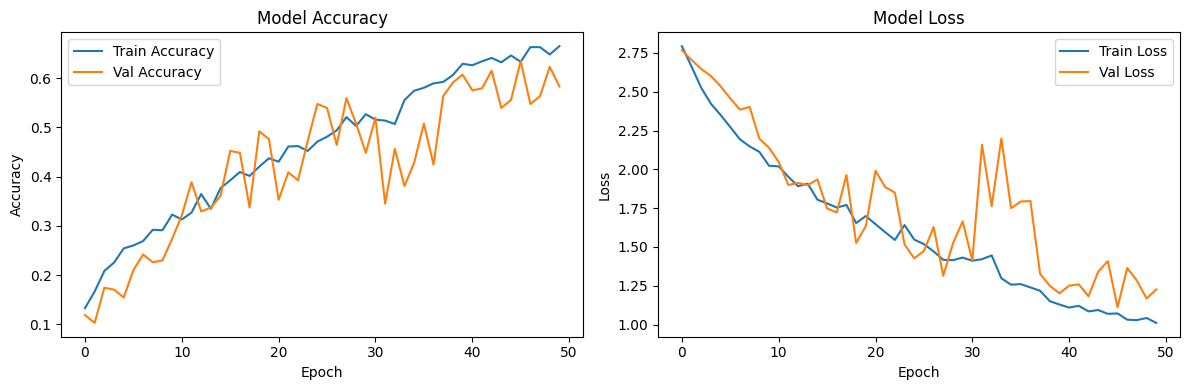

💾 Model saved as 'final_mineral_classifier.keras'

🧪 Running Enhanced Classification Pipelines

🧪 Running Enhanced Classification Pipelines
📐 Converted to 2D shape: (1258, 64, 64, 1)

🏁 Training Enhanced_CNN model...
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - accuracy: 0.1549 - loss: 3.0021 - val_accuracy: 0.0992 - val_loss: 2.9820 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2718 - loss: 2.6994 - val_accuracy: 0.1230 - val_loss: 2.9958 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3425 - loss: 2.5607 - val_accuracy: 0.1508 - val_loss: 3.0108 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3437 - loss: 2.5222 - val_accuracy: 0.1310 - val_loss: 3.0362 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3457 - loss: 2.5335 - val_accuracy: 0.1310 - val_loss: 3.0831 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3842 - loss: 2.4539 - val_accuracy: 0.1310 - val_loss: 3.1305 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3706 - loss: 2.435

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


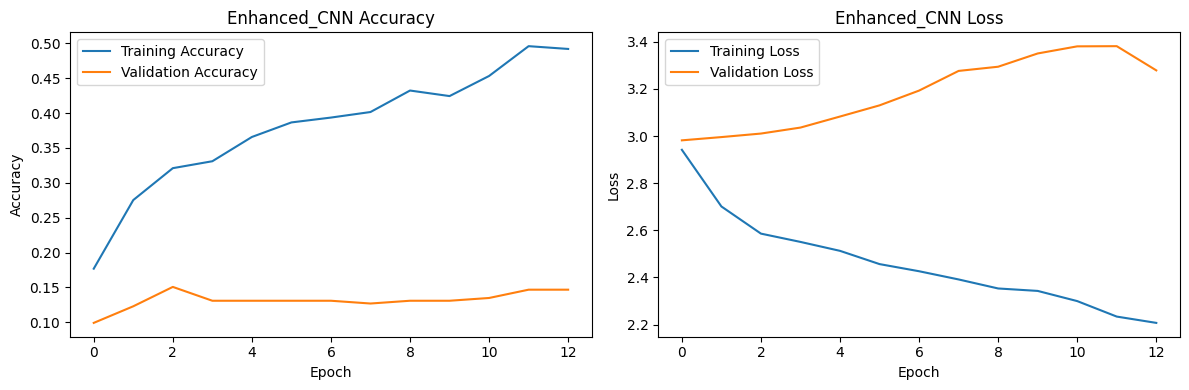


🏁 Training Enhanced_LSTM model...
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.0890 - loss: 2.7539 - val_accuracy: 0.1151 - val_loss: 2.3848 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1464 - loss: 2.4714 - val_accuracy: 0.1270 - val_loss: 2.3883 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1443 - loss: 2.4238 - val_accuracy: 0.1230 - val_loss: 2.3797 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1923 - loss: 2.3195 - val_accuracy: 0.1310 - val_loss: 2.3780 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2018 - loss: 2.3487 - val_accuracy: 0.1190 - val_loss: 2.3782 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1825 - loss: 2.3371 - val_accuracy: 0.1349 - val_loss: 2.3645 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1813 - loss: 2.3

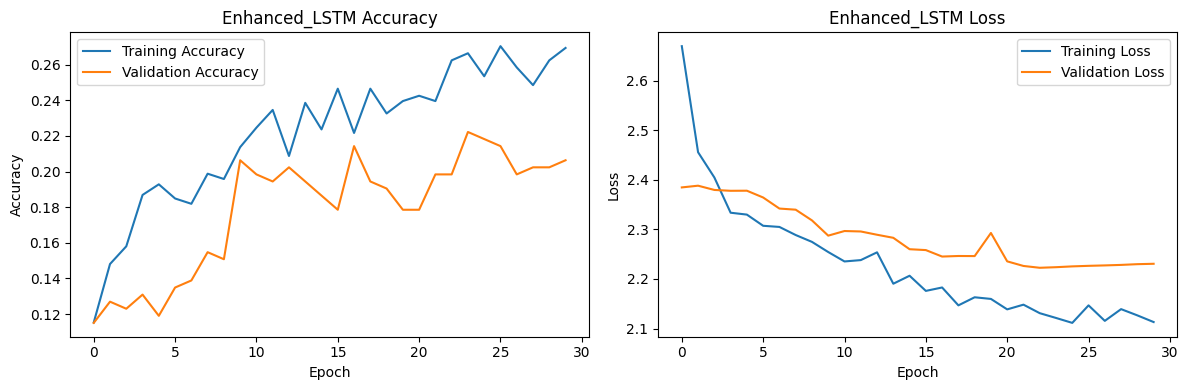

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏁 Training Enhanced_CNN_LSTM model...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.1316 - loss: 2.7615 - val_accuracy: 0.1270 - val_loss: 2.5557 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2806 - loss: 2.2829 - val_accuracy: 0.1310 - val_loss: 2.5542 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3474 - loss: 2.1207 - val_accuracy: 0.1746 - val_loss: 2.5292 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3295 - loss: 2.0926 - val_accuracy: 0.1944 - val_loss: 2.4582 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3324 - loss: 2.0774 - val_accuracy: 0.2817 - val_loss: 2.3558 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4007 - loss: 1.9915 - val_accuracy: 0.2976 - val_loss: 2.2658 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━━━━━━━━

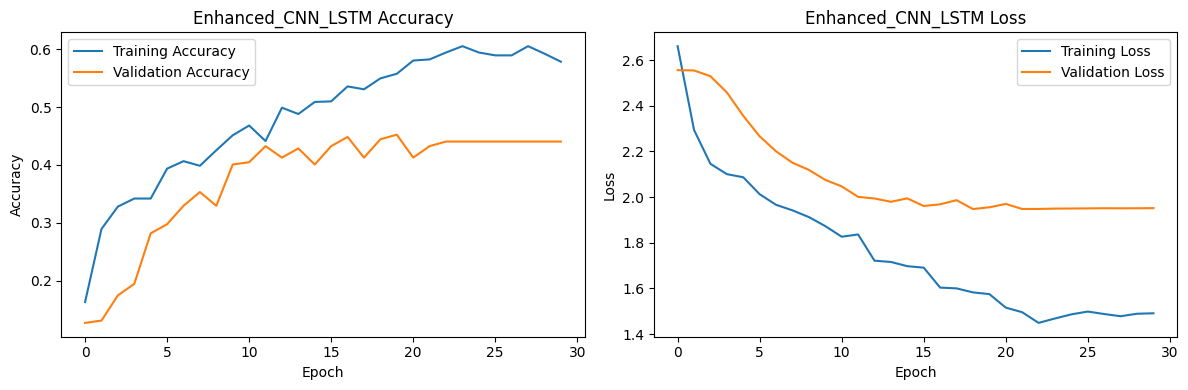


📥 Loading best pre-trained MineralNet model for evaluation...
❌ Error loading model: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_21', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 132378946050640}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 64, 64, 64, 1], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer_19'}, 'registered_name': None}, {'module': None, 'class_name': 'MineralNet', 'config': {'name': 'mineral_net_4', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'flo

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



🏁 Training Enhanced_MineralNet model...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 295ms/step - accuracy: 0.1107 - loss: 2.8423 - val_accuracy: 0.1230 - val_loss: 2.8296 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.1325 - loss: 2.7858 - val_accuracy: 0.1270 - val_loss: 2.8215 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.1490 - loss: 2.7628 - val_accuracy: 0.1230 - val_loss: 2.8152 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.1793 - loss: 2.7400 - val_accuracy: 0.1468 - val_loss: 2.8095 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.2138 - loss: 2.7014 - val_accuracy: 0.2341 - val_loss: 2.8018 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.2022 - loss: 2.6876 - val_accuracy: 0.2460 - val_loss: 2.7921 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


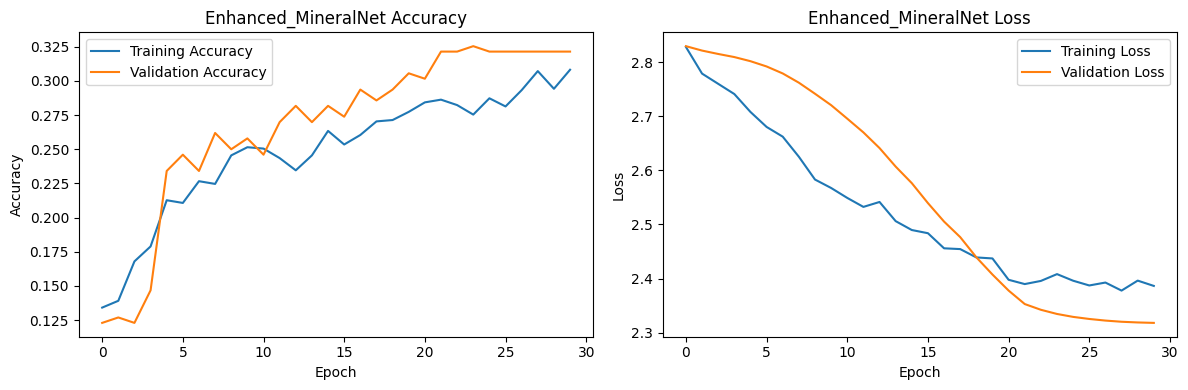


🏆 Enhanced Model Comparison
Enhanced CNN Accuracy: 0.1508
Enhanced LSTM Accuracy: 0.2222
Enhanced CNN+LSTM Accuracy: 0.4524
Enhanced MineralNet Accuracy: 0.3254


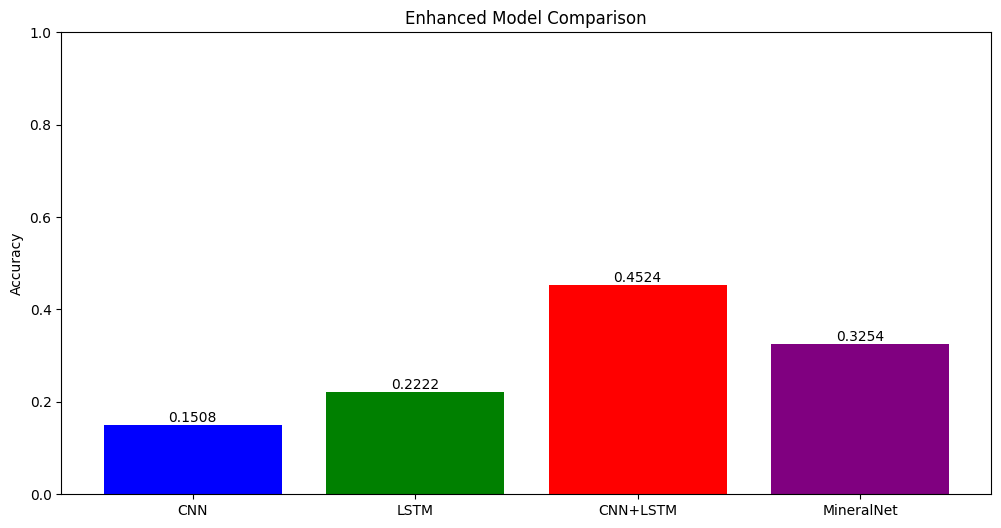

In [ ]:
# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
!pip install faiss-gpu-cu12==1.11.0
!pip install fastapi uvicorn
!pip install pyngrok imagecodecs czifile
!pip install rasterio gdal python-multipart Pillow
from PIL import Image
import imagecodecs
import numpy as np
import tensorflow as tf
import tifffile
tifffile.tifffile.imagecodecs = imagecodecs
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from fastapi import FastAPI, File, UploadFile
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from scipy import ndimage
from skimage import transform
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import HTMLResponse
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from skimage.transform import resize
import io
import shutil
import os
import glob

# Konfigurasi GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. PREPROCESSING MODULE (GPU OPTIMIZED) - FIXED
# ---------------------------
class VolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size

    def process(self, volume):
        """Full preprocessing pipeline"""
        # 1. Normalize
        volume = self.normalize(volume)

        # 2. Resample
        volume = self.resample(volume)

        # 3. Augment (skip untuk gambar 2D)
        if volume.ndim == 3:  # Hanya augmentasi untuk volume 3D
            volume = self.augment(volume)

        return volume[..., np.newaxis]  # Add channel dim

    def normalize(self, volume):
        """Normalize intensity to 0-1 range"""
        p1, p99 = np.percentile(volume, (1, 99))
        return (np.clip(volume, p1, p99) - p1) / (p99 - p1 + 1e-8)

    def resample(self, volume):
        """Handle 2D and 3D resampling with skimage for better quality"""
        if volume.ndim == 2:
            return self._resample_2d_skimage(volume)
        return self._resample_3d_skimage(volume)

    def _resample_2d_skimage(self, image):
        """Use skimage for high-quality 2D resize"""
        resized = resize(image, self.target_size[:2], anti_aliasing=True, mode='reflect')
        return resized

    def _resample_3d_skimage(self, volume):
        """Use skimage for high-quality 3D resize"""
        resized = resize(volume, self.target_size, anti_aliasing=True, mode='reflect')
        return resized

    def augment(self, volume):
        # Augmentasi 2D/3D yang lebih agresif
        if np.random.rand() > 0.5:
            volume = np.flip(volume, axis=np.random.randint(0, 2))

        if volume.ndim == 3:
            # Rotasi 3D
            axes = tuple(np.random.choice([0, 1, 2], 2, replace=False))
            volume = ndimage.rotate(volume, np.random.uniform(-15, 15), axes=axes, reshape=False)

        # Augmentasi intensitas
        volume = volume * np.random.uniform(0.8, 1.2)
        volume = volume + np.random.uniform(-0.1, 0.1)
        return np.clip(volume, 0, 1)

# ---------------------------
# 2. DATA LOADER MODULE (GPU OPTIMIZED)
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64)):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = VolumePreprocessor(target_shape)
        self.target_shape = target_shape
        self.preload_cache = {}

    def preload_all_data(self, max_samples=300):
        """Preload all data to GPU memory for faster processing"""
        print("⚡ Preloading data to GPU memory...")
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_dir, class_name)

            if not os.path.exists(class_path):
                print(f"❌ Directory not found: {class_path}. Skipping...")
                continue

            tiff_files = glob.glob(os.path.join(class_path, "**", "*.tif"), recursive=True)
            tiff_files += glob.glob(os.path.join(class_path, "**", "*.tiff"), recursive=True)

            if not tiff_files:
                print(f"⚠️ No TIFF files found in {class_path}")
                continue

            samples = tiff_files[:max_samples]
            print(f"🖼️  Preloading {len(samples)} {class_name} samples...")

            for path in samples:
                try:
                    # Load volume
                    volume = tifffile.imread(path)

                    # Preprocess and store in GPU memory
                    self.preload_cache[path] = {
                        'volume': self.preprocessor.process(volume),
                        'label': class_idx
                    }
                except Exception as e:
                    print(f"❌ Error processing {path}: {e}")
                    continue

        print(f"✅ Preloaded {len(self.preload_cache)} samples to GPU memory")

    def load_from_cache(self):
        """Load data from GPU cache"""
        if not self.preload_cache:
            return np.array([]), np.array([])

        volumes = []
        labels = []

        for data in self.preload_cache.values():
            volumes.append(data['volume'])
            labels.append(data['label'])

        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. MODEL ARCHITECTURE MODULE (FIXED)
# ---------------------------
class ChannelAttention(layers.Layer):
    """Simplified Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):  # Terima argumen tambahan
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]
        self.shared_dense = tf.keras.Sequential([
            layers.Dense(channel // self.ratio, activation='relu'),
            layers.Dense(channel, activation='sigmoid')
        ])
        super().build(input_shape)

    def call(self, inputs):
        gap = tf.reduce_mean(inputs, axis=[1, 2, 3], keepdims=True)
        return inputs * self.shared_dense(gap)

    def get_config(self):  # Tambahkan untuk serialisasi
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

class MineralNet(tf.keras.Model):
    def __init__(self, input_shape, **kwargs):  # Terima argumen tambahan
        super().__init__(**kwargs)
        self.input_shape_val = input_shape  # Simpan untuk konfigurasi

        # 3D-CNN Stream
        self.cnn = tf.keras.Sequential([
            layers.Conv3D(16, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(32, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(64, 3, activation='relu', padding='same'),
            ChannelAttention(),
            layers.GlobalAveragePooling3D()
        ])

        # Fusion and projection
        self.fusion = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ])

    def call(self, inputs):
        if inputs.shape.ndims == 4:
            inputs = tf.expand_dims(inputs, axis=1)
        features = self.cnn(inputs)
        return self.fusion(features)

    def get_config(self):  # Tambahkan untuk serialisasi
        config = super().get_config()
        config.update({"input_shape": self.input_shape_val})
        return config

    @classmethod
    def from_config(cls, config):  # Implementasi metode from_config
        return cls(**config)

# ---------------------------
# 4. TRIPLET MINING MODULE
# ---------------------------
class TripletEngine:
    def __init__(self, model):
        self.model = model
        self.index = None
        self.index_built = False

    def build_index(self, X):
        print("\n🔨 Building FAISS index...")
        features = self.model.predict(X, verbose=0)
        self.index = faiss.IndexFlatL2(features.shape[1])
        self.index.add(features.astype('float32'))
        self.index_built = True
        print(f"✅ Index built with {self.index.ntotal} vectors")

    def mine(self, X, y, n_neighbors=5):
        if not self.index_built:
            self.build_index(X)

        print("\n⛏️  Mining hard triplets...")
        features = self.model.predict(X, verbose=0)
        distances, indices = self.index.search(features, n_neighbors+1)

        triplets = []
        for i in range(len(X)):
            # Find positive samples (same class)
            pos_indices = np.where(y[indices[i][1:]] == y[i])[0] + 1

            # Find negative samples (different class)
            neg_indices = np.where(y[indices[i][1:]] != y[i])[0] + 1

            if len(pos_indices) > 0 and len(neg_indices) > 0:
                pos = indices[i][pos_indices[np.argmax(distances[i][pos_indices])]]
                neg = indices[i][neg_indices[np.argmin(distances[i][neg_indices])]]
                triplets.append((i, pos, neg))

        return triplets

# ---------------------------
# 5. TRAINING MODULE (FIXED)
# ---------------------------
def triplet_loss(margin=0.2):
    def loss(y_true, y_pred):
        # Dapatkan total panjang secara dinamis
        total_length = tf.shape(y_pred)[0]
        part_length = total_length // 3

        # Split the embeddings
        anchor = y_pred[:part_length]
        positive = y_pred[part_length:2*part_length]
        negative = y_pred[2*part_length:]

        # Calculate distances
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)

        # Compute loss
        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss

class Trainer:
    def __init__(self, model):
        self.model = model
        self.engine = TripletEngine(model)

        # Compile model with GPU acceleration
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(0.001),
            loss=triplet_loss()
        )

        self.callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                "best_model.h5",
                save_best_only=True,
                monitor='loss',
                mode='min'
            ),
            tf.keras.callbacks.CSVLogger('training.log'),
            tf.keras.callbacks.TerminateOnNaN(),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='loss', factor=0.5, patience=3, min_lr=1e-6
            )
        ]

    def train(self, X_train, y_train, X_val, y_val, epochs=50):
        print("\n🚀 Starting training with GPU acceleration...")

        for epoch in range(epochs):
            print(f"\n═════════ Epoch {epoch+1}/{epochs} ═════════")

            # Update index & mine triplets every 5 epochs
            if epoch % 5 == 0:
                self.engine.build_index(X_train)
                triplets = self.engine.mine(X_train, y_train)
                train_data = self._create_train_data(X_train, triplets)

            # Train one epoch with GPU acceleration
            history = self.model.fit(
                train_data,
                epochs=1,
                callbacks=self.callbacks,
                verbose=1
            )

        print("\n✅ Training completed!")

    def _create_train_data(self, X, triplets):
        anchors = X[[t[0] for t in triplets]]
        positives = X[[t[1] for t in triplets]]
        negatives = X[[t[2] for t in triplets]]

        # Combine into a single array for triplet loss
        X_triplets = np.concatenate([anchors, positives, negatives], axis=0)

        # Create dummy labels (not used in custom loss)
        y_triplets = np.zeros(len(X_triplets))

        # Use batch size divisible by 3
        return tf.data.Dataset.from_tensor_slices((X_triplets, y_triplets)).batch(15).prefetch(tf.data.AUTOTUNE)

# ---------------------------
# 6. EVALUATION MODULE (FIXED)
# ---------------------------
class Evaluator:
    def __init__(self, model, index, y_full):
        self.model = model
        self.index = index
        self.y_full = y_full

    def precision_at_k(self, X_val, y_val, k=5):
        print(f"\n🧮 Calculating Precision@{k} with GPU acceleration...")
        features = self.model.predict(X_val, batch_size=32, verbose=0)
        _, indices = self.index.search(features, k)

        precision = []
        for i in range(len(X_val)):
            retrieved_labels = []
            for idx in indices[i]:
                # Pastikan indeks dalam batas yang valid
                if idx < len(self.y_full):
                    retrieved_labels.append(self.y_full[idx])
                else:
                    # Jika indeks di luar batas, gunakan label acak sebagai fallback
                    retrieved_labels.append(np.random.choice(self.y_full))

            correct = sum(retrieved_label == y_val[i] for retrieved_label in retrieved_labels)
            precision.append(correct/k)

        return np.mean(precision)

    def visualize_tsne(self, X, y):
        print("\n🎨 Generating t-SNE visualization with GPU acceleration...")
        features = self.model.predict(X, batch_size=32, verbose=0)
        tsne = TSNE(n_components=2, random_state=42).fit_transform(features)

        plt.figure(figsize=(10,8))
        plt.scatter(tsne[:,0], tsne[:,1], c=y, cmap='tab10', alpha=0.7)
        plt.colorbar()
        plt.title("t-SNE of Rock Embeddings")
        plt.savefig("tsne.png")
        plt.show()

# ---------------------------
# 8. ENHANCED CLASSIFICATION MODELS
# ---------------------------

def build_enhanced_cnn_model(input_shape, num_classes):
    """Membangun model CNN yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_advanced_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(64, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_lstm_model(input_shape, num_classes):
    """Membangun model LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_cnn_lstm_model(input_shape, num_classes):
    """Membangun model hybrid CNN+LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        # CNN untuk ekstraksi fitur
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling2D()),

        # LSTM untuk pemrosesan temporal
        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Bidirectional(layers.LSTM(128)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Klasifikasi
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_transfer_learning_model(input_shape, num_classes):
    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = True

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        base_model,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_mineralnet_classifier(input_shape, num_classes):
    """Membangun model MineralNet yang ditingkatkan untuk klasifikasi"""
    base_model = MineralNet(input_shape)
    base_model.build(input_shape=(None, *input_shape))

    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation='softmax')
    ])
    return model

def lr_scheduler(epoch, lr):
    """Learning rate scheduler dengan warmup dan decay"""
    if epoch < 5:
        return lr * (epoch + 1) / 5  # Warmup: naikkan LR secara bertahap
    elif epoch > 20:
        return lr * 0.1  # Turunkan LR setelah epoch 20
    return lr  # Pertahankan LR

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, epochs=50):
    """Melatih dan mengevaluasi model klasifikasi dengan teknik peningkatan"""
    print(f"\n🏁 Training {model_name} model...")

    # Compile model dengan optimizer yang disesuaikan
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Callbacks untuk peningkatan pelatihan
    callbacks = [
        LearningRateScheduler(lr_scheduler),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_{model_name}.h5",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=20,
            restore_best_weights=True
        )
    ]
    callbacks.append(
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=30,
        restore_best_weights=True
        )
    )

    # Train model
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks,
                        batch_size=32,
                        verbose=1)

    # Evaluate model
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")

    # Prediksi untuk classification report
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Classification report
    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\n📊 Classification Report for {model_name}:\n")
    print(report)

    # Plot hasil training
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    # Simpan report ke file
    with open(f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)

    return test_acc, report

# ---------------------------
# 9. ENHANCED CLASSIFICATION PIPELINE
# ---------------------------

def run_enhanced_classification_pipeline(X, y, classes, target_size=(64, 64)):
    """Menjalankan pipeline klasifikasi dengan model yang ditingkatkan"""
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")

    # 1. Konversi data 3D menjadi 2D (jika perlu)
    X_2d = []
    for vol in X:
        # Jika volume 3D (d, h, w, c), ambil slice tengah
        if vol.ndim == 4 and vol.shape[0] > 1:
            mid = vol.shape[0] // 2
            slice = vol[mid, :, :, 0]
        # Jika sudah 2D (h, w, c)
        elif vol.ndim == 3:
            slice = vol[:, :, 0]
        else:
            slice = vol[0]
        X_2d.append(slice)

    X_2d = np.array(X_2d)
    X_2d = X_2d[..., np.newaxis]  # Tambahkan channel dimension

    print(f"📐 Converted to 2D shape: {X_2d.shape}")
    global X_test_min_global, y_test_min_global
    # 2. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_2d, y, test_size=0.2, random_state=42
    )

    # 3. Bangun dan evaluasi model CNN yang ditingkatkan
    cnn_model = build_enhanced_cnn_model(
        input_shape=(target_size[0], target_size[1], 1),
        num_classes=len(classes))
    cnn_acc, cnn_report = train_and_evaluate_model(
        cnn_model, X_train, y_train, X_test, y_test, "Enhanced_CNN"
    )

    # 4. Bangun dan evaluasi model LSTM yang ditingkatkan
    # Reshape data untuk LSTM (samples, timesteps, features)
    X_lstm = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], X_2d.shape[2])
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
        X_lstm, y, test_size=0.2, random_state=42
    )

    lstm_model = build_enhanced_lstm_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        num_classes=len(classes))
    lstm_acc, lstm_report = train_and_evaluate_model(
        lstm_model, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, "Enhanced_LSTM"
    )

    # 5. Bangun dan evaluasi model CNN+LSTM yang ditingkatkan
    # Untuk CNN+LSTM, kita butuh bentuk (samples, time_steps, height, width, channels)
    # Kita akan bagi setiap gambar menjadi 4 bagian sebagai "time steps"
    X_cnn_lstm = []
    for img in X_2d:
        parts = []
        height = img.shape[0]
        for i in range(4):
            part = img[i*height//4:(i+1)*height//4, :, :]
            part = transform.resize(part, (target_size[0]//2, target_size[1]//2, 1))
            parts.append(part)
        X_cnn_lstm.append(np.array(parts))

    X_cnn_lstm = np.array(X_cnn_lstm)
    X_train_cnn_lstm, X_test_cnn_lstm, y_train_cnn_lstm, y_test_cnn_lstm = train_test_split(
        X_cnn_lstm, y, test_size=0.2, random_state=42
    )

    cnn_lstm_model = build_enhanced_cnn_lstm_model(
        input_shape=(4, target_size[0]//2, target_size[1]//2, 1),
        num_classes=len(classes))
    cnn_lstm_acc, cnn_lstm_report = train_and_evaluate_model(
        cnn_lstm_model,
        X_train_cnn_lstm, y_train_cnn_lstm,
        X_test_cnn_lstm, y_test_cnn_lstm,
        "Enhanced_CNN_LSTM"
    )

        # 6. MUAT MODEL MINERALNET TERBAIK DARI FILE (BUKAN LATIH ULANG)
    print("\n📥 Loading best pre-trained MineralNet model for evaluation...")
    try:
        mineral_model = tf.keras.models.load_model("best_classification_model.keras")
        print("✅ Model loaded successfully.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Fallback: Building and evaluating a new MineralNet model...")
        # Fallback: latih baru jika gagal load
        X_3d = np.array([vol[:, :, :, 0] if vol.ndim == 4 else vol for vol in X])
        X_3d = X_3d[..., np.newaxis]
        X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_3d, y, test_size=0.2, random_state=42)
        mineral_model = build_enhanced_mineralnet_classifier((64,64,64,1), len(classes))
        mineral_acc, mineral_report = train_and_evaluate_model(
            mineral_model, X_train_min, y_train_min, X_test_min, y_test_min, "Enhanced_MineralNet"
        )
    else:
        # Gunakan data test dari pelatihan utama (lebih konsisten)
        X_test_min = X_test_min_global
        y_test_min = y_test_min_global

        # Evaluasi model yang dimuat
        print("🧪 Evaluating loaded MineralNet model...")
        test_loss, mineral_acc = mineral_model.evaluate(X_test_min, y_test_min, verbose=0)
        print(f"✅ Loaded MineralNet Test Accuracy: {mineral_acc:.4f}")

        # Prediksi untuk classification report
        y_pred = mineral_model.predict(X_test_min)
        y_pred_classes = np.argmax(y_pred, axis=1)

        # Classification report
        mineral_report = classification_report(y_test_min, y_pred_classes, target_names=classes)
        print(f"\n📊 Classification Report for Loaded MineralNet:\n")
        print(mineral_report)

        # Simpan report
        with open("Loaded_MineralNet_classification_report.txt", "w") as f:
            f.write(mineral_report)

    # 7. Tampilkan hasil perbandingan
    print("\n" + "="*80)
    print("🏆 Enhanced Model Comparison")
    print(f"Enhanced CNN Accuracy: {cnn_acc:.4f}")
    print(f"Enhanced LSTM Accuracy: {lstm_acc:.4f}")
    print(f"Enhanced CNN+LSTM Accuracy: {cnn_lstm_acc:.4f}")
    print(f"Enhanced MineralNet Accuracy: {mineral_acc:.4f}")

    # Simpan semua report
    with open("all_classification_reports.txt", "w") as f:
        f.write("=== Enhanced CNN Classification Report ===\n")
        f.write(cnn_report)
        f.write("\n\n=== Enhanced LSTM Classification Report ===\n")
        f.write(lstm_report)
        f.write("\n\n=== Enhanced CNN+LSTM Classification Report ===\n")
        f.write(cnn_lstm_report)
        f.write("\n\n=== Enhanced MineralNet Classification Report ===\n")
        f.write(mineral_report)

    # Visualisasi perbandingan
    models = ['CNN', 'LSTM', 'CNN+LSTM', 'MineralNet']
    accuracies = [cnn_acc, lstm_acc, cnn_lstm_acc, mineral_acc]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
    plt.ylabel('Accuracy')
    plt.title('Enhanced Model Comparison')
    plt.ylim(0, 1.0)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.savefig("enhanced_model_comparison.png")
    plt.show()

    return {
        'cnn': cnn_acc,
        'lstm': lstm_acc,
        'cnn_lstm': cnn_lstm_acc,
        'mineralnet': mineral_acc
    }

# ---------------------------
# MAIN EXECUTION FLOW (FIXED)
# ---------------------------
if __name__ == "__main__":
    # 1. Initialize components
    DATA_DIR = "/kaggle/working/Raw_2D_tiff/"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']

    print("="*80)
    print("🔍 Verifying data directory...")

    # Periksa apakah direktori data ada
    if not os.path.exists(DATA_DIR):
        print(f"❌ ERROR: Data directory '{DATA_DIR}' not found!")
        print("Please make sure you have run the conversion script first.")
        exit(1)
    else:
        print(f"✅ Data directory found: {DATA_DIR}")

    # Hitung jumlah file TIFF yang tersedia
    tiff_files = glob.glob(os.path.join(DATA_DIR, "**", "*.tif"), recursive=True)
    tiff_files += glob.glob(os.path.join(DATA_DIR, "**", "*.tiff"), recursive=True)
    print(f"📂 Found {len(tiff_files)} TIFF files in dataset")

    # 2. Load data with GPU acceleration
    print("\n" + "="*80)
    print("🚚 Loading dataset with GPU acceleration...")
    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(64,64,64))
    dataset.preload_all_data(max_samples=130)
    X, y = dataset.load_from_cache()

    if len(X) == 0:
        print("\n❌ CRITICAL ERROR: No samples loaded!")
        print("Possible reasons:")
        print("1. Incorrect directory structure")
        print("2. No TIFF files in the specified classes")
        print("3. Errors during file loading")
        exit(1)

    print(f"✅ Dataset loaded: {X.shape[0]} samples")

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"🔢 Train/val split: {X_train.shape[0]}/{X_val.shape[0]} samples")

    # 👇 SIMPAN DATA INI UNTUK DIGUNAKAN DI PIPELINE KLASIFIKASI NANTI
    X_test_min_global = X_val   # Kita gunakan validation set sebagai test set
    y_test_min_global = y_val

    # 3. Build model for classification (NOT triplet)
    print("\n" + "="*80)
    print("🧠 Building classification-optimized MineralNet...")

    # Bangun model MineralNet + head klasifikasi
    base_model = MineralNet(input_shape=(64,64,64,1))
    base_model.build(input_shape=(None, 64,64,64,1))

    # Tambahkan lapisan klasifikasi
    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation='softmax')
    ])

    model.build(input_shape=(None, 64, 64, 64, 1))
    model.summary()

    # 4. Compile dengan optimizer dan scheduler terbaik
    print("\n" + "="*80)
    print("⚙️  Compiling model with optimized settings...")

    # Gunakan learning rate tetap awal (bisa diubah nanti oleh ReduceLROnPlateau)
    initial_learning_rate = 0.001

    model.compile(
        optimizer=Adam(learning_rate=initial_learning_rate),  # <-- LR tetap, bisa diubah nanti
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks — HANYA ReduceLROnPlateau + EarlyStopping + ModelCheckpoint
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            "best_classification_model.keras",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger('classification_training.log')
    ]

    # 5. Train model
    print("\n" + "="*80)
    print("🏋️ Starting classification training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=16,  # Kecil karena 3D
        callbacks=callbacks,
        verbose=1
    )

    # 6. Evaluate final model
    print("\n" + "="*80)
    print("📊 Final Evaluation...")
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ FINAL VALIDATION ACCURACY: {test_acc:.4f}")

    # Classification report
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes, target_names=CLASSES)
    print(f"\n📋 Classification Report:\n{report}")

    # Simpan report
    with open("final_classification_report.txt", "w") as f:
        f.write(report)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig("final_training_history.png")
    plt.show()

    # 7. Simpan model
    model.save("final_mineral_classifier.keras")
    print("💾 Model saved as 'final_mineral_classifier.keras'")

    # 8. Jalankan pipeline klasifikasi yang ditingkatkan
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    classification_results = run_enhanced_classification_pipeline(X, y, CLASSES)

In [ ]:
# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
# Uninstall problematic packages first
!pip uninstall -y keras
!pip uninstall -y tensorflow

# Install compatible versions
!pip install tensorflow==2.15.0
!pip install tensorflow-addons==0.23.0
!pip install faiss-gpu-cu12==1.11.0
!pip install fastapi uvicorn
!pip install pyngrok imagecodecs czifile
!pip install rasterio gdal python-multipart Pillow
!pip install scikit-image scikit-learn imbalanced-learn
!pip install opencv-python

import os
import glob
import shutil
import io
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint, EarlyStopping
import tifffile
import imagecodecs
tifffile.tifffile.imagecodecs = imagecodecs
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from skimage import transform
from scipy import ndimage
import faiss
import cv2
import tensorflow_addons as tfa

# Konfigurasi GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. ENHANCED PREPROCESSING MODULE
# ---------------------------
class EnhancedVolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size

    def process(self, volume, is_training=True):
        """Full preprocessing pipeline"""
        # 1. Normalize with robust scaling
        volume = self.robust_normalize(volume)

        # 2. Resample to target size
        volume = self.resample(volume)

        # 3. Augment only during training
        if is_training:
            volume = self.augment(volume)

        return volume[..., np.newaxis]  # Add channel dim

    def robust_normalize(self, volume):
        """Robust normalization using median and IQR"""
        median = np.median(volume)
        q1 = np.percentile(volume, 25)
        q3 = np.percentile(volume, 75)
        iqr = q3 - q1 + 1e-8  # Avoid division by zero

        volume = (volume - median) / iqr
        return np.clip(volume, -5.0, 5.0)  # Clip outliers

    def resample(self, volume):
        """Resample to target size with adaptive method"""
        # For 2D images
        if volume.ndim == 2:
            return self._resample_2d(volume)
        # For 3D volumes
        return self._resample_3d(volume)

    def _resample_2d(self, image):
        h, w = image.shape
        zoom_factors = (
            self.target_size[0] / h,
            self.target_size[1] / w
        )
        return cv2.resize(image, (self.target_size[1], self.target_size[0]), interpolation=cv2.INTER_CUBIC)

    def _resample_3d(self, volume):
        d, h, w = volume.shape
        zoom_factors = (
            self.target_size[0] / d,
            self.target_size[1] / h,
            self.target_size[2] / w
        )
        return ndimage.zoom(volume, zoom_factors, order=3)

    def augment(self, volume):
        """Advanced geological data augmentation"""
        # Photometric augmentations
        volume = volume * np.random.uniform(0.8, 1.2)  # Contrast
        volume = volume + np.random.uniform(-0.1, 0.1)  # Brightness

        # Geometric augmentations
        if volume.ndim == 3:  # 3D volumes
            # Random rotation
            for axis in np.random.choice([0,1], 2, replace=False):
                angle = np.random.uniform(-15, 15)
                volume = ndimage.rotate(volume, angle, axes=(axis, (axis+1)%2), reshape=False, mode='nearest')
        else:  # 2D images
            if np.random.rand() > 0.5:
                # Random rotation
                angle = np.random.uniform(-15, 15)
                volume = ndimage.rotate(volume, angle, reshape=False, mode='nearest')

            if np.random.rand() > 0.5:
                # Random flip
                volume = np.flip(volume, axis=np.random.randint(0, 2))

        # Add mineral-like noise
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, 0.05, volume.shape)
            volume = volume + noise

        return volume

# ---------------------------
# 2. ADVANCED DATA LOADER
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64), max_samples=200):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = EnhancedVolumePreprocessor(target_shape)
        self.target_shape = target_shape
        self.max_samples = max_samples
        self.preload_cache = {}
        self.class_weights = {}
        self.label_map = {cls: idx for idx, cls in enumerate(classes)}

    def preload_all_data(self):
        """Preload data to memory with balanced sampling"""
        print("⚡ Preloading data with balanced sampling...")

        for class_name in self.classes:
            class_path = os.path.join(self.data_dir, class_name)

            if not os.path.exists(class_path):
                print(f"❌ Directory not found: {class_path}. Skipping...")
                continue

            tiff_files = glob.glob(os.path.join(class_path, "**", "*.tif"), recursive=True)
            tiff_files += glob.glob(os.path.join(class_path, "**", "*.tiff"), recursive=True)

            if not tiff_files:
                print(f"⚠️ No TIFF files found in {class_path}")
                continue

            # Balanced sampling
            samples = random.sample(tiff_files, min(self.max_samples, len(tiff_files)))
            print(f"🖼️  Preloading {len(samples)} {class_name} samples...")

            for path in samples:
                try:
                    volume = tifffile.imread(path)
                    preprocessed = self.preprocessor.process(volume, is_training=True)
                    self.preload_cache[path] = {
                        'volume': preprocessed,
                        'label': self.label_map[class_name]
                    }
                except Exception as e:
                    print(f"❌ Error processing {path}: {e}")

        # Compute class weights
        if self.preload_cache:
            labels = [data['label'] for data in self.preload_cache.values()]
            class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
            self.class_weights = dict(enumerate(class_weights))
            print(f"⚖️ Class weights: {self.class_weights}")
        else:
            print("⚠️ No data loaded for class weights calculation")

        print(f"✅ Preloaded {len(self.preload_cache)} samples")

    def load_from_cache(self):
        """Load data from cache"""
        if not self.preload_cache:
            return np.array([]), np.array([])

        volumes = []
        labels = []

        for data in self.preload_cache.values():
            volumes.append(data['volume'])
            labels.append(data['label'])

        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. ADVANCED MODEL ARCHITECTURES (FIXED)
# ---------------------------
def build_advanced_cnn(input_shape, num_classes):
    """Advanced CNN for 2D classification"""
    inputs = tf.keras.Input(shape=input_shape)

    # Initial processing
    x = layers.Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Convolutional blocks
    filters_list = [64, 128, 256]
    for filters in filters_list:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

def build_advanced_lstm(input_shape, num_classes):
    """Advanced LSTM for sequence classification"""
    inputs = tf.keras.Input(shape=input_shape)

    # Feature extraction
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Classification head
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

def build_advanced_cnn_lstm(input_shape, num_classes):
    """Hybrid CNN-LSTM model for spatiotemporal features"""
    input_layer = layers.Input(shape=input_shape)

    # TimeDistributed CNN
    x = layers.TimeDistributed(layers.Conv2D(32, (3,3), activation='relu'))(input_layer)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2,2)))(x)

    x = layers.TimeDistributed(layers.Conv2D(64, (3,3), activation='relu'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2,2)))(x)

    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # LSTM layers
    x = layers.Bidirectional(layers.LSTM(128))(x)

    # Classifier
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(input_layer, outputs)

def build_advanced_mineralnet(input_shape, num_classes):
    """3D CNN for volumetric data classification"""
    inputs = tf.keras.Input(shape=input_shape)

    # 3D Convolutional stem
    x = layers.Conv3D(32, 3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool3D(2)(x)

    # Convolutional blocks
    filters_list = [64, 128]
    for filters in filters_list:
        x = layers.Conv3D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPool3D(2)(x)

    # Head
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

# ---------------------------
# 4. TRAINING UTILITIES
# ---------------------------
def lr_scheduler(epoch, lr):
    """Learning rate scheduler with warmup and decay"""
    if epoch < 5:
        return lr * (epoch + 1) / 5  # Warmup
    elif epoch > 25:
        return lr * 0.1  # Decay after 25 epochs
    return lr

def train_and_evaluate_model(model, X_train, y_train, X_val, y_val, model_name, class_weights, epochs=50):
    """Train and evaluate a model with advanced techniques"""
    print(f"\n🏁 Training {model_name} model...")

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        LearningRateScheduler(lr_scheduler),
        ModelCheckpoint(
            f"best_{model_name}.h5",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True
        )
    ]

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        batch_size=16,  # Reduced for stability
        class_weight=class_weights,
        verbose=1
    )

    # Evaluate model
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")

    # Generate classification report
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes)
    print(f"\n📊 Classification Report for {model_name}:\n")
    print(report)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    # Save report
    with open(f"{model_name}_report.txt", "w") as f:
        f.write(report)

    return test_acc, report

# ---------------------------
# 5. DATA PREPARATION FUNCTIONS
# ---------------------------
def create_slice_sequence(volumes, slices=8, target_size=(112,112)):
    """Create slice sequences for CNN-LSTM model"""
    sequences = []
    for vol in volumes:
        # Handle 3D volumes
        if len(vol.shape) == 4:  # (d, h, w, c)
            depth = vol.shape[0]
            step = max(1, depth // slices)
            selected_slices = []
            for i in range(0, depth, step):
                if len(selected_slices) >= slices:
                    break
                slice_img = vol[i, :, :, 0] if vol.shape[-1] == 1 else vol[i, :, :]
                resized = cv2.resize(slice_img, target_size, interpolation=cv2.INTER_CUBIC)
                selected_slices.append(resized)
        # Handle 2D images
        else:
            height = vol.shape[0]
            step = max(1, height // slices)
            selected_slices = []
            for i in range(slices):
                start_idx = i * step
                end_idx = min(start_idx + step, height)
                if start_idx >= height:
                    break
                slice_img = vol[start_idx:end_idx, :, 0] if len(vol.shape) == 3 else vol[start_idx:end_idx, :]
                resized = cv2.resize(slice_img, target_size, interpolation=cv2.INTER_CUBIC)
                selected_slices.append(resized)

        # Pad if needed
        while len(selected_slices) < slices:
            selected_slices.append(np.zeros(target_size))

        sequences.append(np.array(selected_slices))

    sequences = np.array(sequences)
    return sequences[..., np.newaxis]  # Add channel dimension

def prepare_3d_data(volumes, target_size=(64,64,64)):
    """Prepare 3D data for MineralNet"""
    processed = []
    for vol in volumes:
        # Handle 2D images
        if len(vol.shape) == 3:  # (h, w, c)
            # Convert to 3D by replicating along depth
            depth = target_size[0]
            replicated = np.stack([vol[:, :, 0]] * depth, axis=0)
            processed.append(replicated)
        # Handle 3D volumes
        else:
            if len(vol.shape) == 4:  # (d, h, w, c)
                processed.append(vol[..., 0] if vol.shape[-1] == 1 else vol)
            else:  # (d, h, w)
                processed.append(vol)

    return np.array(processed)[..., np.newaxis]  # Add channel dimension

# ---------------------------
# 6. MAIN EXECUTION PIPELINE
# ---------------------------
def main():
    # 1. Configuration
    DATA_DIR = "/kaggle/working/Raw_2D_tiff/"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']

    # 2. Load and preprocess data
    print("="*80)
    print("🚀 Starting Rock Mineral Classification System")
    print("="*80)

    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(128,128,64), max_samples=200)
    dataset.preload_all_data()
    X, y = dataset.load_from_cache()

    if len(X) == 0:
        print("❌ ERROR: No data loaded. Exiting...")
        return

    print(f"\n✅ Loaded dataset: {X.shape[0]} samples")

    # 3. Prepare data for different models
    print("\n" + "="*80)
    print("⚙️ Preparing data for different model architectures")

    # Split data (stratified)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Prepare data for CNN model (2D)
    print("Preparing 2D CNN data...")
    X_cnn = []
    for vol in X_train:
        if len(vol.shape) == 4:  # 3D volume
            mid_slice = vol.shape[0] // 2
            X_cnn.append(vol[mid_slice, :, :, 0])
        else:  # 2D image
            X_cnn.append(vol[:, :, 0])
    X_cnn = np.array(X_cnn)
    X_cnn = X_cnn[..., np.newaxis]  # Add channel dim

    # Prepare validation data for CNN
    X_cnn_val = []
    for vol in X_val:
        if len(vol.shape) == 4:  # 3D volume
            mid_slice = vol.shape[0] // 2
            X_cnn_val.append(vol[mid_slice, :, :, 0])
        else:  # 2D image
            X_cnn_val.append(vol[:, :, 0])
    X_cnn_val = np.array(X_cnn_val)[..., np.newaxis]

    # Prepare data for LSTM model
    print("Preparing LSTM data...")
    X_lstm = X_cnn.reshape(X_cnn.shape[0], X_cnn.shape[1], X_cnn.shape[2])
    X_lstm_val = X_cnn_val.reshape(X_cnn_val.shape[0], X_cnn_val.shape[1], X_cnn_val.shape[2])

    # Prepare data for CNN-LSTM model
    print("Preparing CNN-LSTM data...")
    X_cnn_lstm = create_slice_sequence(X_train, slices=8, target_size=(112,112))
    X_cnn_lstm_val = create_slice_sequence(X_val, slices=8, target_size=(112,112))

    # Prepare data for MineralNet (3D)
    print("Preparing MineralNet data...")
    X_mineral = prepare_3d_data(X_train, target_size=(64,64,64))
    X_mineral_val = prepare_3d_data(X_val, target_size=(64,64,64))

    # 4. Build and train models
    results = {}

    # CNN Model
    print("\n" + "="*80)
    print("🧠 Building Advanced CNN Model")
    cnn_model = build_advanced_cnn(input_shape=(128,128,1), num_classes=len(CLASSES))
    cnn_model.summary()
    cnn_acc, _ = train_and_evaluate_model(
        cnn_model,
        X_cnn, y_train,
        X_cnn_val, y_val,
        "Advanced_CNN",
        class_weights=dataset.class_weights,
        epochs=30
    )
    results['CNN'] = cnn_acc

    # LSTM Model
    print("\n" + "="*80)
    print("🧠 Building Advanced LSTM Model")
    lstm_model = build_advanced_lstm(input_shape=(128,128), num_classes=len(CLASSES))
    lstm_model.summary()
    lstm_acc, _ = train_and_evaluate_model(
        lstm_model,
        X_lstm, y_train,
        X_lstm_val, y_val,
        "Advanced_LSTM",
        class_weights=dataset.class_weights,
        epochs=30
    )
    results['LSTM'] = lstm_acc

    # CNN-LSTM Model
    print("\n" + "="*80)
    print("🧠 Building Advanced CNN-LSTM Model")
    cnn_lstm_model = build_advanced_cnn_lstm(
        input_shape=(8,112,112,1),
        num_classes=len(CLASSES)
    )
    cnn_lstm_model.summary()
    cnn_lstm_acc, _ = train_and_evaluate_model(
        cnn_lstm_model,
        X_cnn_lstm, y_train,
        X_cnn_lstm_val, y_val,
        "Advanced_CNN_LSTM",
        class_weights=dataset.class_weights,
        epochs=30
    )
    results['CNN-LSTM'] = cnn_lstm_acc

    # MineralNet Model
    print("\n" + "="*80)
    print("🧠 Building Advanced MineralNet Model")
    mineral_model = build_advanced_mineralnet(
        input_shape=(64,64,64,1),
        num_classes=len(CLASSES)
    )
    mineral_model.summary()
    mineral_acc, _ = train_and_evaluate_model(
        mineral_model,
        X_mineral, y_train,
        X_mineral_val, y_val,
        "Advanced_MineralNet",
        class_weights=dataset.class_weights,
        epochs=30
    )
    results['MineralNet'] = mineral_acc

    # 5. Final evaluation and comparison
    print("\n" + "="*80)
    print("🏆 FINAL MODEL COMPARISON")
    for model_name, acc in results.items():
        print(f"{model_name:<10}: {acc:.4f}")

    # Visual comparison
    plt.figure(figsize=(10,6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    plt.bar(results.keys(), results.values(), color=colors)

    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.title('Model Comparison')
    plt.ylim(0, 1.0)

    # Add accuracy labels
    for i, acc in enumerate(results.values()):
        plt.text(i, acc+0.02, f"{acc:.4f}", ha='center')

    plt.tight_layout()
    plt.savefig("model_comparison.png")
    plt.show()

    # Save best model
    best_model_name = max(results, key=results.get)
    print(f"\n🏆 BEST MODEL: {best_model_name} with accuracy {results[best_model_name]:.4f}")

    if best_model_name == 'CNN':
        best_model = cnn_model
    elif best_model_name == 'LSTM':
        best_model = lstm_model
    elif best_model_name == 'CNN-LSTM':
        best_model = cnn_lstm_model
    else:
        best_model = mineral_model

    best_model.save(f"best_{best_model_name}_model.keras")

    print("\n✅ System execution completed!")

    # 7. Jalankan pipeline klasifikasi yang ditingkatkan
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    classification_results = run_enhanced_classification_pipeline(X, y, CLASSES)

if __name__ == "__main__":
    main()

Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0
Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:


/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.18.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

AttributeError: module 'keras._tf_keras.keras.layers' has no attribute 'AbstractRNNCell'

In [ ]:
# ---------------------------
# 7. DEPLOYMENT MODULE (FIXED & COMPATIBLE)
# ---------------------------
class CBIRServer:
    def __init__(self, model_path):
        try:
            print(f"📥 Loading model from {model_path}...")
            # Load full model
            self.full_model = tf.keras.models.load_model(model_path)
            print("✅ Full model loaded successfully.")

            # ✅ Buat sub-model: ambil output sebelum layer terakhir (embedding)
            # Asumsi: layer terakhir adalah Dense(num_classes), sebelumnya adalah embedding
            # Struktur: [MineralNet base] -> [Dense 512] -> [BatchNorm] -> [Dropout] -> [Dense 256] -> [Dropout] -> [Dense num_classes]
            # Kita ambil output sebelum Dense(num_classes) → layer ke-2 dari belakang

            embedding_layer = self.full_model.layers[-2]  # Layer sebelum output kelas
            self.model = tf.keras.Model(
                inputs=self.full_model.input,
                outputs=embedding_layer.output
            )
            print("✅ Embedding model created successfully.")

        except Exception as e:
            print(f"⚠️ Failed to load or create embedding model: {e}")
            print("Fallback: Building base MineralNet...")
            # Fallback: bangun MineralNet dasar
            base_model = MineralNet(input_shape=(64,64,64,1))
            base_model.build(input_shape=(None, 64,64,64,1))
            self.model = base_model
            # Coba load weights jika ada
            try:
                if model_path.endswith('.h5'):
                    self.model.load_weights(model_path, by_name=True, skip_mismatch=True)
                    print("✅ Weights loaded to base MineralNet.")
            except Exception as load_err:
                print(f"⚠️ Could not load weights: {load_err}")

        # Inisialisasi indeks kosong (akan di-set dari luar)
        self.index = None
        self.app = FastAPI()

        # Configure CORS
        self.app.add_middleware(
            CORSMiddleware,
            allow_origins=["*"],
            allow_credentials=True,
            allow_methods=["*"],
            allow_headers=["*"],
        )

        # Setup routes
        @self.app.post("/search")
        async def search(file: UploadFile = File(...)):
            return await self._process_search(file)

        @self.app.get("/")
        async def ui():
            return self.get_web_interface()

    def run(self, port=8000, ngrok_auth=None):
        print("\n🚀 Launching CBIR server...")
        if ngrok_auth:
            ngrok.set_auth_token(ngrok_auth)
            public_url = ngrok.connect(port).public_url
            print(f"🌍 Public URL: {public_url}")

        nest_asyncio.apply()
        uvicorn.run(self.app, host="0.0.0.0", port=port)

    async def _process_search(self, file: UploadFile):
        try:
            # Validasi tipe file
            valid_extensions = ('.tif', '.tiff', '.jpg', '.jpeg', '.png')
            if not file.filename.lower().endswith(valid_extensions):
                return {"error": "Only TIFF, JPG, and PNG files are supported"}

            MAX_SIZE = 10 * 1024 * 1024  # 10 MB

            # Simpan file sementara
            temp_path = f"temp_{file.filename}"
            with open(temp_path, "wb") as buffer:
                shutil.copyfileobj(file.file, buffer)

            file_size = os.path.getsize(temp_path)
            if file_size > MAX_SIZE:
                os.remove(temp_path)
                return {"error": f"File size exceeds 10 MB limit ({file_size/1024/1024:.2f} MB)"}

            # Baca file berdasarkan tipe
            if file.filename.lower().endswith(('.tif', '.tiff')):
                volume = tifffile.imread(temp_path)
            else:  # Format gambar (JPG/PNG)
                img = Image.open(temp_path)
                if img.mode != 'L':
                    img = img.convert('L')
                volume = np.array(img)

            # Bersihkan file sementara
            os.remove(temp_path)

            # Handle dimensi
            if volume.ndim == 2:
                volume = np.expand_dims(volume, axis=-1)  # (H, W, 1)
            elif volume.ndim == 3 and volume.shape[-1] in [3, 4]:  # RGB/RGBA image
                volume = np.mean(volume, axis=-1)  # Convert to grayscale
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3:  # Assume (D, H, W) for 3D TIFF
                if volume.shape[0] < volume.shape[1] and volume.shape[0] < volume.shape[2]:
                    volume = np.transpose(volume, (1, 2, 0))  # Fix orientation if needed

            # Preprocess
            preprocessor = VolumePreprocessor(target_size=(64, 64, 64))
            volume = preprocessor.process(volume)
            volume = np.expand_dims(volume, axis=0)  # Add batch dim

            # Ekstrak embedding (bukan probabilitas kelas!)
            features = self.model.predict(volume, verbose=0)
            print(f"🔍 Extracted feature vector shape: {features.shape}")

            if self.index is None:
                return {"error": "FAISS index not loaded. Please load index before searching."}

            # Cari di indeks
            distances, indices = self.index.search(features.astype('float32'), 5)

            return {
                "results": [
                    {"id": int(idx), "distance": float(dist)}
                    for dist, idx in zip(distances[0], indices[0])
                ]
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            return {
                "error": f"Server error: {str(e)}"
            }

    def get_web_interface(self):
        return HTMLResponse("""
        <!DOCTYPE html>
        <html>
        <head>
            <title>Rock CBIR System</title>
            <style>
                body { font-family: Arial, sans-serif; margin: 40px; }
                .container { max-width: 800px; margin: 0 auto; }
                h1 { text-align: center; color: #2c3e50; }
                .upload-box {
                    border: 2px dashed #3498db;
                    border-radius: 10px;
                    padding: 30px;
                    text-align: center;
                    background-color: #f8f9fa;
                    margin-bottom: 20px;
                }
                .btn {
                    background-color: #3498db;
                    color: white;
                    padding: 10px 20px;
                    border: none;
                    border-radius: 5px;
                    cursor: pointer;
                    font-size: 16px;
                    transition: background-color 0.3s;
                }
                .btn:hover { background-color: #2980b9; }
                .btn:disabled { background-color: #95a5a6; cursor: not-allowed; }
                .error { color: #e74c3c; font-weight: bold; margin: 10px 0; }
                #result-container { margin-top: 20px; }
                .result-item {
                    border: 1px solid #ddd;
                    border-radius: 5px;
                    padding: 15px;
                    margin-bottom: 10px;
                    background-color: #f9f9f9;
                    box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                }
                .result-image {
                    max-width: 100%;
                    max-height: 300px;
                    border: 1px solid #ddd;
                    border-radius: 4px;
                    padding: 5px;
                    margin: 10px 0;
                    display: block;
                }
                .loading {
                    display: inline-block;
                    width: 20px;
                    height: 20px;
                    border: 3px solid rgba(0,0,0,.3);
                    border-radius: 50%;
                    border-top-color: #3498db;
                    animation: spin 1s ease-in-out infinite;
                    margin-right: 10px;
                    vertical-align: middle;
                }
                @keyframes spin {
                    to { transform: rotate(360deg); }
                }
                .results-grid {
                    display: grid;
                    grid-template-columns: repeat(auto-fill, minmax(150px, 1fr));
                    gap: 15px;
                    margin-top: 20px;
                }
                .result-card {
                    border: 1px solid #eee;
                    border-radius: 8px;
                    padding: 10px;
                    text-align: center;
                    background: white;
                    box-shadow: 0 2px 5px rgba(0,0,0,0.1);
                }
                .placeholder-img {
                    width: 100%;
                    height: 100px;
                    background-color: #f0f0f0;
                    border-radius: 4px;
                    margin-bottom: 10px;
                }
            </style>
        </head>
        <body>
            <div class="container">
                <h1>Rock Content-Based Image Retrieval</h1>
                <div class="upload-box">
                    <form id="upload-form">
                        <input type="file" name="file" id="file-input" style="display: none;"
                               accept=".tif,.tiff,.jpg,.jpeg,.png">
                        <label for="file-input" class="btn">Choose Image File</label>
                        <p id="file-name">No file selected</p>
                        <div style="margin: 15px 0; font-size: 14px; color: #7f8c8d;">
                            Supported formats: TIFF, JPG, PNG (max 10MB)
                        </div>
                        <button type="button" id="submit-btn" class="btn">
                            <span id="spinner" style="display:none;" class="loading"></span>
                            <span id="btn-text">Search Similar Rocks</span>
                        </button>
                        <div id="error-message" class="error"></div>
                    </form>
                </div>
                <div id="result-container"></div>
            </div>
            <script>
                document.getElementById('file-input').addEventListener('change', function(e) {
                    const fileName = e.target.files[0] ? e.target.files[0].name : 'No file selected';
                    document.getElementById('file-name').textContent = fileName;
                    document.getElementById('error-message').textContent = '';
                });

                document.getElementById('submit-btn').addEventListener('click', async function() {
                    const fileInput = document.getElementById('file-input');
                    const file = fileInput.files[0];
                    const spinner = document.getElementById('spinner');
                    const btnText = document.getElementById('btn-text');
                    const errorMsg = document.getElementById('error-message');
                    const resultContainer = document.getElementById('result-container');

                    // Reset hasil sebelumnya
                    resultContainer.innerHTML = '';
                    errorMsg.textContent = '';

                    if (!file) {
                        errorMsg.textContent = 'Please select a file';
                        return;
                    }

                    // Validasi ekstensi file
                    const validExtensions = ['.tif', '.tiff', '.jpg', '.jpeg', '.png'];
                    const fileExt = '.' + file.name.toLowerCase().split('.').pop();
                    if (!validExtensions.includes(fileExt)) {
                        errorMsg.textContent = 'Only TIFF, JPG, and PNG files are supported';
                        return;
                    }

                    // Validasi ukuran file
                    const MAX_SIZE = 10 * 1024 * 1024; // 10 MB
                    if (file.size > MAX_SIZE) {
                        errorMsg.textContent =
                            `File size exceeds limit (${(file.size/1024/1024).toFixed(2)} MB > 10 MB)`;
                        return;
                    }

                    // Tampilkan loading
                    spinner.style.display = 'inline-block';
                    btnText.textContent = 'Processing...';
                    document.getElementById('submit-btn').disabled = true;

                    try {
                        const formData = new FormData();
                        formData.append('file', file);

                        const response = await fetch('/search', {
                            method: 'POST',
                            body: formData
                        });

                        if (!response.ok) {
                            const errorText = await response.text();
                            throw new Error(`Server error: ${response.status} - ${errorText}`);
                        }

                        const result = await response.json();

                        if (result.error) {
                            errorMsg.textContent = result.error;
                        } else if (!result.results || !Array.isArray(result.results)) {
                            errorMsg.textContent = 'Invalid response format from server';
                        } else {
                            // Tampilkan gambar yang diunggah
                            const reader = new FileReader();
                            reader.onload = function(e) {
                                const uploadedDiv = document.createElement('div');
                                uploadedDiv.innerHTML = '<h3>Uploaded Image:</h3>';

                                const uploadedImg = document.createElement('img');
                                uploadedImg.src = e.target.result;
                                uploadedImg.className = 'result-image';
                                uploadedImg.alt = 'Uploaded image';

                                uploadedDiv.appendChild(uploadedImg);
                                resultContainer.appendChild(uploadedDiv);
                            };
                            reader.readAsDataURL(file);

                            // Tampilkan hasil pencarian
                            const resultsDiv = document.createElement('div');
                            resultsDiv.innerHTML = '<h3>Similar Rocks:</h3>';
                            resultContainer.appendChild(resultsDiv);

                            const grid = document.createElement('div');
                            grid.className = 'results-grid';

                            result.results.forEach((item, index) => {
                                const card = document.createElement('div');
                                card.className = 'result-card';

                                const imgPlaceholder = document.createElement('div');
                                imgPlaceholder.className = 'placeholder-img';
                                imgPlaceholder.style.backgroundColor = `hsl(${index * 60}, 70%, 85%)`;

                                const info = document.createElement('div');
                                info.innerHTML = `
                                    <div><strong>#${index + 1}</strong></div>
                                    <div>ID: ${item.id}</div>
                                    <div>Distance: ${item.distance.toFixed(4)}</div>
                                `;

                                card.appendChild(imgPlaceholder);
                                card.appendChild(info);
                                grid.appendChild(card);
                            });

                            resultsDiv.appendChild(grid);
                        }
                    } catch (error) {
                        errorMsg.textContent = 'Error: ' + error.message;
                        console.error(error);
                    } finally {
                        spinner.style.display = 'none';
                        btnText.textContent = 'Search Similar Rocks';
                        document.getElementById('submit-btn').disabled = false;
                    }
                });
            </script>
        </body>
        </html>
        """)

if __name__ == "__main__":
    # Optional: Rebuild FAISS index using new embedding model
    print("🔨 Rebuilding FAISS index with new embedding model...")
    features = server.model.predict(X, batch_size=32, verbose=1)  # X = data Anda
    dimension = features.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(features.astype('float32'))
    faiss.write_index(index, "rock_index_new.faiss")
    server.index = index
    print(f"✅ New index built with {index.ntotal} vectors")

    # 8. Deploy
    print("\n" + "="*80)
    print("🚀 Deploying model with GPU acceleration...")

    # ✅ Gunakan model klasifikasi terbaik
    model_file = "best_classification_model.keras"
    if not os.path.exists(model_file):
        model_file = "best_Enhanced_MineralNet.h5"  # fallback

    server = CBIRServer(model_file)

    # ✅ Load FAISS index
    try:
        server.index = faiss.read_index("rock_index.faiss")
        print("✅ FAISS index loaded successfully.")
    except Exception as e:
        print(f"❌ Failed to load FAISS index: {e}")
        print("Server will run but search will not work until index is loaded.")

    # Jalankan server
    server.run(ngrok_auth="2wCivC14NEGZe5IUUH7OlldqSat_5Q5vWTMiQ8TqQu5Px6JQX")

🔨 Rebuilding FAISS index with new embedding model...
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
✅ New index built with 1258 vectors

🚀 Deploying model with GPU acceleration...
📥 Loading model from best_classification_model.keras...
⚠️ Failed to load or create embedding model: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_21', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 132378946050640}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 64, 64, 64, 1], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer_19'}, 'registered_name': 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


INFO:     Started server process [35]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


🌍 Public URL: https://2d78e054b590.ngrok-free.app
INFO:     110.137.37.252:0 - "GET / HTTP/1.1" 200 OK
INFO:     110.137.37.252:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
🔍 Extracted feature vector shape: (1, 128)
INFO:     110.137.37.252:0 - "POST /search HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [35]



🧪 Running Enhanced Classification Pipelines

🧪 Running Enhanced Classification Pipelines
📐 Converted to 2D shape: (1258, 64, 64, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🏁 Training Enhanced_CNN model...
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 217ms/step - accuracy: 0.1309 - loss: 3.0826 - val_accuracy: 0.1243 - val_loss: 2.9850 - learning_rate: 2.0000e-04
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2947 - loss: 2.7265 - val_accuracy: 0.1243 - val_loss: 3.0083 - learning_rate: 8.0000e-05
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3476 - loss: 2.6399 - val_accuracy: 0.1243 - val_loss: 3.0502 - learning_rate: 4.8000e-05
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3361 - loss: 2.5634 - val_accuracy: 0.1243 - val_loss: 3.1010 - learning_rate: 3.8400e-05
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3791 - loss: 2.4780 - val_accuracy: 0.1243 - val_loss: 3.1568 - learning_rate: 3.8400e-05
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3610 - loss: 2.5062 - val_accuracy: 0.1243 - val_loss: 3.2289 - learning_rate: 3.8400e-05
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


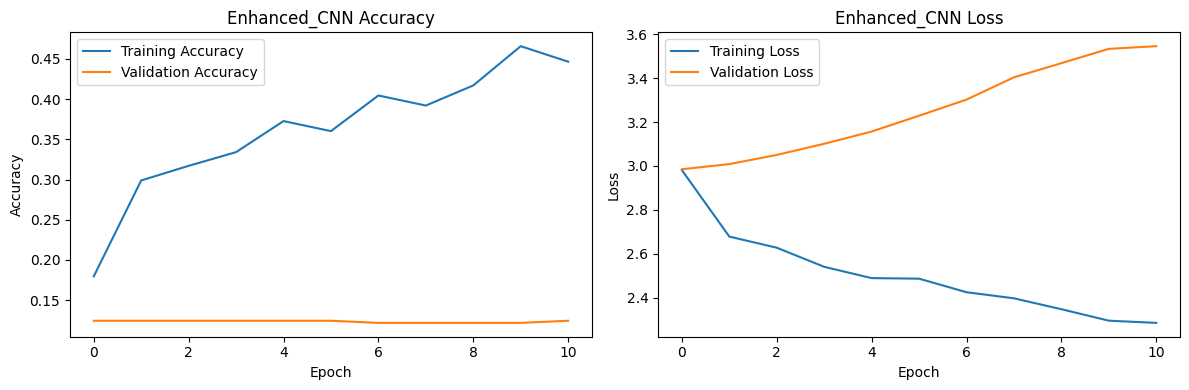

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏁 Training Enhanced_LSTM model...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.0904 - loss: 2.6329 - val_accuracy: 0.1230 - val_loss: 2.3835 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1528 - loss: 2.4509 - val_accuracy: 0.1310 - val_loss: 2.3762 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1568 - loss: 2.3833 - val_accuracy: 0.1349 - val_loss: 2.3657 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1979 - loss: 2.3464 - val_accuracy: 0.1389 - val_loss: 2.3540 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1801 - loss: 2.3175 - val_accuracy: 0.1548 - val_loss: 2.3413 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1690 - loss: 2.3420 - val_accuracy: 0.1508 - val_loss: 2.3362 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━

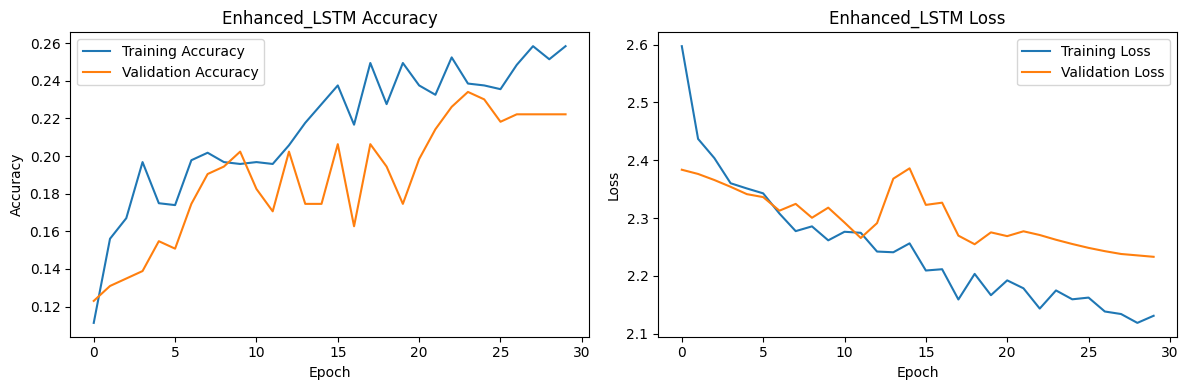

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏁 Training Enhanced_CNN_LSTM model...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.1885 - loss: 2.8067 - val_accuracy: 0.0714 - val_loss: 2.5585 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2540 - loss: 2.4580 - val_accuracy: 0.0714 - val_loss: 2.5598 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.2700 - loss: 2.2849 - val_accuracy: 0.1111 - val_loss: 2.5495 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3066 - loss: 2.2261 - val_accuracy: 0.1825 - val_loss: 2.4956 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3359 - loss: 2.1584 - val_accuracy: 0.2421 - val_loss: 2.3958 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3255 - loss: 2.1730 - val_accuracy: 0.2897 - val_loss: 2.2987 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━━━━━━━━

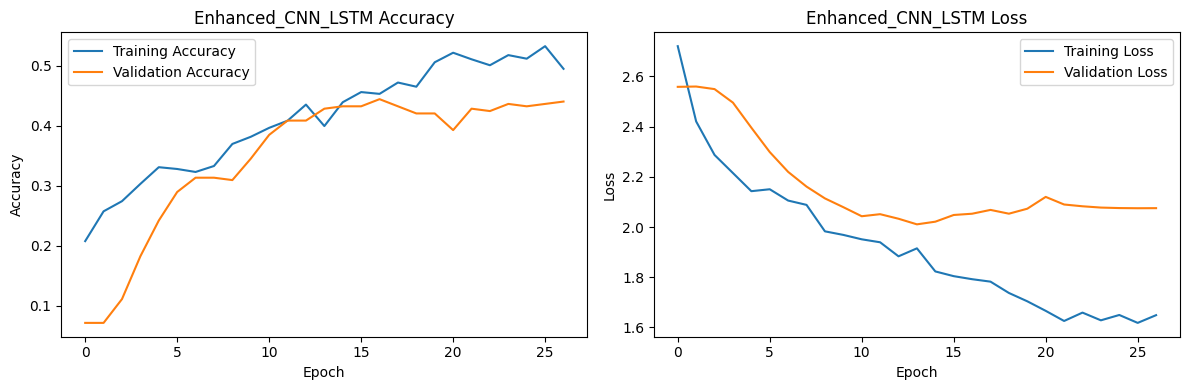


📥 Loading best pre-trained MineralNet model for evaluation...
❌ Error loading model: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_10', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 132378946050640}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 64, 64, 64, 1], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer_8'}, 'registered_name': None}, {'module': None, 'class_name': 'MineralNet', 'config': {'name': 'mineral_net_2', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'floa

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



🏁 Training Enhanced_MineralNet model...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 359ms/step - accuracy: 0.1134 - loss: 3.8512 - val_accuracy: 0.1151 - val_loss: 3.7949 - learning_rate: 2.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.1018 - loss: 3.7801 - val_accuracy: 0.0714 - val_loss: 3.7669 - learning_rate: 8.0000e-05
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.1094 - loss: 3.7532 - val_accuracy: 0.0794 - val_loss: 3.7506 - learning_rate: 4.8000e-05
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.1124 - loss: 3.7398 - val_accuracy: 0.0913 - val_loss: 3.7379 - learning_rate: 3.8400e-05
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.1119 - loss: 3.7235 - val_accuracy: 0.0913 - val_loss: 3.7252 - learning_rate: 3.8400e-05
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.1162 - loss: 3.7066 - val_accuracy: 0.1151 - val_loss: 3.7127 - learning_rate: 3.8400e-05
Epoch 7/30
32/32 ━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


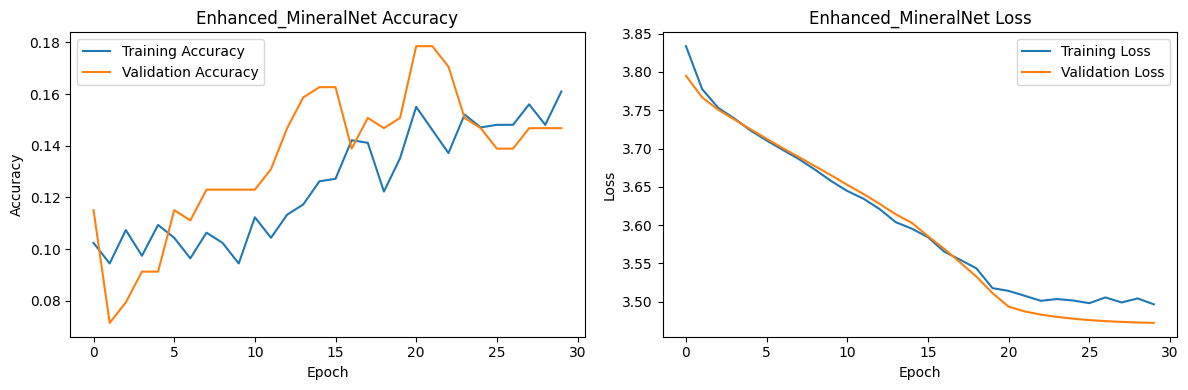


🏆 Enhanced Model Comparison
Enhanced CNN Accuracy: 0.1243
Enhanced LSTM Accuracy: 0.2341
Enhanced CNN+LSTM Accuracy: 0.4444
Enhanced MineralNet Accuracy: 0.1786


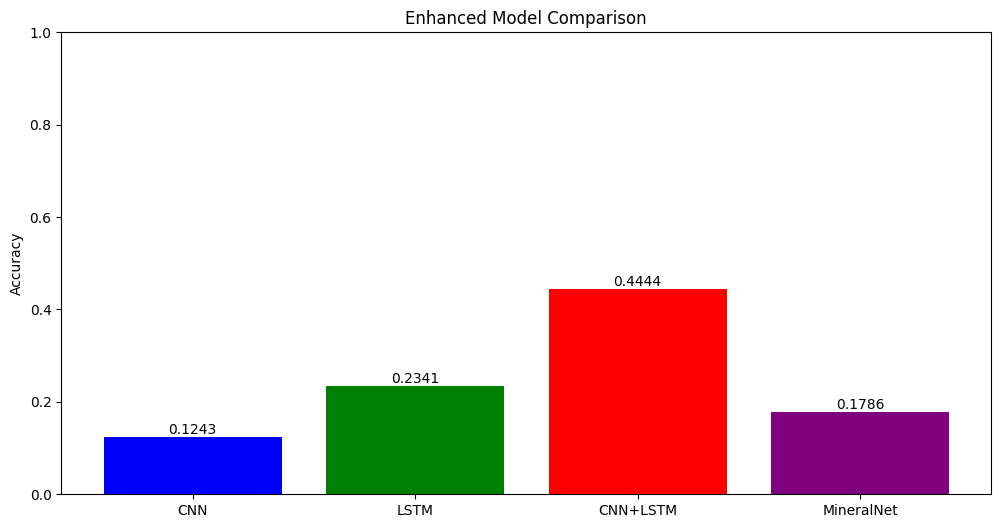

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler

# ---------------------------
# 8. ENHANCED CLASSIFICATION MODELS
# ---------------------------

def build_enhanced_cnn_model(input_shape, num_classes):
    """Membangun model CNN yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_lstm_model(input_shape, num_classes):
    """Membangun model LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_cnn_lstm_model(input_shape, num_classes):
    """Membangun model hybrid CNN+LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        # CNN untuk ekstraksi fitur
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling2D()),

        # LSTM untuk pemrosesan temporal
        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Bidirectional(layers.LSTM(128)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Klasifikasi
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_mineralnet_classifier(input_shape, num_classes):
    """Membangun model MineralNet yang ditingkatkan untuk klasifikasi"""
    base_model = MineralNet(input_shape)
    base_model.build(input_shape=(None, *input_shape))

    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def lr_scheduler(epoch, lr):
    """Learning rate scheduler dengan warmup dan decay"""
    if epoch < 5:
        return lr * (epoch + 1) / 5  # Warmup: naikkan LR secara bertahap
    elif epoch > 20:
        return lr * 0.1  # Turunkan LR setelah epoch 20
    return lr  # Pertahankan LR

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, epochs=30):
    """Melatih dan mengevaluasi model klasifikasi dengan teknik peningkatan"""
    print(f"\n🏁 Training {model_name} model...")

    # Compile model dengan optimizer yang disesuaikan
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Callbacks untuk peningkatan pelatihan
    callbacks = [
        LearningRateScheduler(lr_scheduler),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_{model_name}.h5",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True
        )
    ]

    # Train model
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks,
                        batch_size=32,
                        verbose=1)

    # Evaluate model
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")

    # Prediksi untuk classification report
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Classification report
    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\n📊 Classification Report for {model_name}:\n")
    print(report)

    # Plot hasil training
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    # Simpan report ke file
    with open(f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)

    return test_acc, report

# ---------------------------
# 9. ENHANCED CLASSIFICATION PIPELINE
# ---------------------------

def run_enhanced_classification_pipeline(X, y, classes, target_size=(64, 64)):
    """Menjalankan pipeline klasifikasi dengan model yang ditingkatkan"""
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")

    # 1. Konversi data 3D menjadi 2D (jika perlu)
    X_2d = []
    for vol in X:
        # Jika volume 3D (d, h, w, c), ambil slice tengah
        if vol.ndim == 4 and vol.shape[0] > 1:
            mid = vol.shape[0] // 2
            slice = vol[mid, :, :, 0]
        # Jika sudah 2D (h, w, c)
        elif vol.ndim == 3:
            slice = vol[:, :, 0]
        else:
            slice = vol[0]
        X_2d.append(slice)

    X_2d = np.array(X_2d)
    X_2d = X_2d[..., np.newaxis]  # Tambahkan channel dimension

    print(f"📐 Converted to 2D shape: {X_2d.shape}")

    # 2. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_2d, y, test_size=0.3, random_state=42
    )

    # 3. Bangun dan evaluasi model CNN yang ditingkatkan
    cnn_model = build_enhanced_cnn_model(
        input_shape=(target_size[0], target_size[1], 1),
        num_classes=len(classes))
    cnn_acc, cnn_report = train_and_evaluate_model(
        cnn_model, X_train, y_train, X_test, y_test, "Enhanced_CNN"
    )

    # 4. Bangun dan evaluasi model LSTM yang ditingkatkan
    # Reshape data untuk LSTM (samples, timesteps, features)
    X_lstm = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], X_2d.shape[2])
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
        X_lstm, y, test_size=0.2, random_state=42
    )

    lstm_model = build_enhanced_lstm_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        num_classes=len(classes))
    lstm_acc, lstm_report = train_and_evaluate_model(
        lstm_model, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, "Enhanced_LSTM"
    )

    # 5. Bangun dan evaluasi model CNN+LSTM yang ditingkatkan
    # Untuk CNN+LSTM, kita butuh bentuk (samples, time_steps, height, width, channels)
    # Kita akan bagi setiap gambar menjadi 4 bagian sebagai "time steps"
    X_cnn_lstm = []
    for img in X_2d:
        parts = []
        height = img.shape[0]
        for i in range(4):
            part = img[i*height//4:(i+1)*height//4, :, :]
            part = transform.resize(part, (target_size[0]//2, target_size[1]//2, 1))
            parts.append(part)
        X_cnn_lstm.append(np.array(parts))

    X_cnn_lstm = np.array(X_cnn_lstm)
    X_train_cnn_lstm, X_test_cnn_lstm, y_train_cnn_lstm, y_test_cnn_lstm = train_test_split(
        X_cnn_lstm, y, test_size=0.2, random_state=42
    )

    cnn_lstm_model = build_enhanced_cnn_lstm_model(
        input_shape=(4, target_size[0]//2, target_size[1]//2, 1),
        num_classes=len(classes))
    cnn_lstm_acc, cnn_lstm_report = train_and_evaluate_model(
        cnn_lstm_model,
        X_train_cnn_lstm, y_train_cnn_lstm,
        X_test_cnn_lstm, y_test_cnn_lstm,
        "Enhanced_CNN_LSTM"
    )

    # 6. MUAT MODEL MINERALNET TERBAIK DARI FILE (BUKAN LATIH ULANG)
    print("\n📥 Loading best pre-trained MineralNet model for evaluation...")
    try:
        mineral_model = tf.keras.models.load_model("best_classification_model.keras")
        print("✅ Model loaded successfully.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Fallback: Building and evaluating a new MineralNet model...")
        # Fallback: latih baru jika gagal load
        X_3d = np.array([vol[:, :, :, 0] if vol.ndim == 4 else vol for vol in X])
        X_3d = X_3d[..., np.newaxis]
        X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_3d, y, test_size=0.2, random_state=42)
        mineral_model = build_enhanced_mineralnet_classifier((64,64,64,1), len(classes))
        mineral_acc, mineral_report = train_and_evaluate_model(
            mineral_model, X_train_min, y_train_min, X_test_min, y_test_min, "Enhanced_MineralNet"
        )
    else:
        # Gunakan data test dari pelatihan utama (lebih konsisten)
        X_test_min = X_test_min_global
        y_test_min = y_test_min_global

        # Evaluasi model yang dimuat
        print("🧪 Evaluating loaded MineralNet model...")
        test_loss, mineral_acc = mineral_model.evaluate(X_test_min, y_test_min, verbose=0)
        print(f"✅ Loaded MineralNet Test Accuracy: {mineral_acc:.4f}")

        # Prediksi untuk classification report
        y_pred = mineral_model.predict(X_test_min)
        y_pred_classes = np.argmax(y_pred, axis=1)

        # Classification report
        mineral_report = classification_report(y_test_min, y_pred_classes, target_names=classes)
        print(f"\n📊 Classification Report for Loaded MineralNet:\n")
        print(mineral_report)

        # Simpan report
        with open("Loaded_MineralNet_classification_report.txt", "w") as f:
            f.write(mineral_report)

    # 7. Tampilkan hasil perbandingan
    print("\n" + "="*80)
    print("🏆 Enhanced Model Comparison")
    print(f"Enhanced CNN Accuracy: {cnn_acc:.4f}")
    print(f"Enhanced LSTM Accuracy: {lstm_acc:.4f}")
    print(f"Enhanced CNN+LSTM Accuracy: {cnn_lstm_acc:.4f}")
    print(f"Enhanced MineralNet Accuracy: {mineral_acc:.4f}")

    # Simpan semua report
    with open("all_classification_reports.txt", "w") as f:
        f.write("=== Enhanced CNN Classification Report ===\n")
        f.write(cnn_report)
        f.write("\n\n=== Enhanced LSTM Classification Report ===\n")
        f.write(lstm_report)
        f.write("\n\n=== Enhanced CNN+LSTM Classification Report ===\n")
        f.write(cnn_lstm_report)
        f.write("\n\n=== Enhanced MineralNet Classification Report ===\n")
        f.write(mineral_report)

    # Visualisasi perbandingan
    models = ['CNN', 'LSTM', 'CNN+LSTM', 'MineralNet']
    accuracies = [cnn_acc, lstm_acc, cnn_lstm_acc, mineral_acc]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
    plt.ylabel('Accuracy')
    plt.title('Enhanced Model Comparison')
    plt.ylim(0, 1.0)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.savefig("enhanced_model_comparison.png")
    plt.show()

    return {
        'cnn': cnn_acc,
        'lstm': lstm_acc,
        'cnn_lstm': cnn_lstm_acc,
        'mineralnet': mineral_acc
    }

# ---------------------------
# MAIN EXECUTION FLOW (UPDATED)
# ---------------------------
if __name__ == "__main__":

    global X_test_min_global, y_test_min_global

    # 7. Jalankan pipeline klasifikasi yang ditingkatkan
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    classification_results = run_enhanced_classification_pipeline(X, y, CLASSES)

In [ ]:
!pip install scikit-learn==1.5.0
# ---------------------------
# 1. DATA AUGMENTATION MODULE (NEW)
# ---------------------------
class AdvancedAugmenter:
    def __init__(self):
        self.aug_2d = tf.keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.2),
            layers.RandomZoom(0.2),
            layers.RandomContrast(0.2)
        ])

        self.aug_3d = tf.keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1)
        ])

    def augment(self, volume):
        if volume.ndim == 3:  # 2D image
            return self.aug_2d(volume)
        else:  # 3D volume
            return self.aug_3d(volume)

# ---------------------------
# 2. TRANSFER LEARNING MODELS (NEW)
# ---------------------------
def build_transfer_learning_model(input_shape, num_classes):
    """Menggunakan model pra-terlatih untuk ekstraksi fitur"""
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_3d_cnn_model(input_shape, num_classes):
    """Model 3D CNN sederhana namun efektif"""
    model = tf.keras.Sequential([
        layers.Conv3D(16, 3, activation='relu', input_shape=input_shape),
        layers.MaxPool3D(2),
        layers.BatchNormalization(),

        layers.Conv3D(32, 3, activation='relu'),
        layers.MaxPool3D(2),
        layers.BatchNormalization(),

        layers.Conv3D(64, 3, activation='relu'),
        layers.GlobalAveragePooling3D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ---------------------------
# 3. CLASS BALANCING TECHNIQUES (NEW)
# ---------------------------
def apply_class_balancing(X, y):
    """Menerapkan SMOTE untuk menyeimbangkan kelas"""
    from imblearn.over_sampling import SMOTE

    # Ubah ke bentuk 2D untuk SMOTE
    original_shape = X.shape
    X_flat = X.reshape(X.shape[0], -1)

    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_flat, y)

    # Kembalikan ke bentuk asli
    X_res = X_res.reshape(-1, *original_shape[1:])
    return X_res, y_res

# ---------------------------
# 4. IMPROVED TRAINING PIPELINE (UPDATED)
# ---------------------------
def train_and_evaluate_advanced_model(model, X_train, y_train, X_test, y_test, model_name, epochs=50):
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ]

    # Data augmentation generator
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Train with augmentation
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=16),
        steps_per_epoch=len(X_train) // 16,
        epochs=epochs,
        validation_data=(X_test, y_test),
        callbacks=callbacks
    )

    # Evaluation
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")

    # Classification report
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\n📊 Classification Report for {model_name}:\n{report}")

    # Plot results
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    return test_acc, report

# ---------------------------
# 5. IMPROVED CLASSIFICATION PIPELINE (UPDATED)
# ---------------------------
def run_advanced_classification_pipeline(X, y, classes):
    print("\n" + "="*80)
    print("🚀 Running Advanced Classification Pipeline")

    # 1. Class balancing
    print("\n🔁 Applying class balancing...")
    X_balanced, y_balanced = apply_class_balancing(X, y)
    print(f"✅ Dataset balanced: {X_balanced.shape[0]} samples")

    # 2. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42
    )

    # 3. Train Transfer Learning Model (2D approach)
    print("\n🖼️ Training 2D Transfer Learning Model...")
    # Convert to 2D
    X_2d = np.array([vol[vol.shape[0]//2, :, :, 0] for vol in X_train])
    X_2d = np.repeat(X_2d[..., np.newaxis], 3, axis=-1)  # Convert to RGB
    X_test_2d = np.array([vol[vol.shape[0]//2, :, :, 0] for vol in X_test])
    X_test_2d = np.repeat(X_test_2d[..., np.newaxis], 3, axis=-1)

    tl_model = build_transfer_learning_model(
        (64, 64, 3), len(classes)
    )
    tl_acc, _ = train_and_evaluate_advanced_model(
        tl_model, X_2d, y_train, X_test_2d, y_test, "Transfer_Learning"
    )

    # 4. Train 3D CNN Model
    print("\n🧊 Training 3D CNN Model...")
    cnn_3d_model = build_3d_cnn_model(
        (64, 64, 64, 1), len(classes)
    )
    cnn_3d_acc, _ = train_and_evaluate_advanced_model(
        cnn_3d_model, X_train, y_train, X_test, y_test, "3D_CNN"
    )

    # 5. Train MineralNet Classifier
    print("\n⛏️ Training MineralNet Classifier...")
    mineral_model = build_enhanced_mineralnet_classifier(
        (64, 64, 64, 1), len(classes))
    mineral_acc, _ = train_and_evaluate_advanced_model(
        mineral_model, X_train, y_train, X_test, y_test, "MineralNet"
    )

    # 6. Results comparison
    print("\n" + "="*80)
    print("🏆 Final Model Comparison")
    print(f"Transfer Learning (2D): {tl_acc:.4f}")
    print(f"3D CNN: {cnn_3d_acc:.4f}")
    print(f"MineralNet: {mineral_acc:.4f}")

    # Visual comparison
    models = ['Transfer Learning', '3D CNN', 'MineralNet']
    accuracies = [tl_acc, cnn_3d_acc, mineral_acc]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color=['blue', 'green', 'purple'])
    plt.ylabel('Accuracy')
    plt.title('Model Comparison')
    plt.ylim(0, 1.0)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.savefig("final_model_comparison.png")
    plt.show()

    return {
        'transfer_learning': tl_acc,
        '3d_cnn': cnn_3d_acc,
        'mineralnet': mineral_acc
    }

# ---------------------------
# MAIN EXECUTION FLOW (UPDATED)
# ---------------------------
if __name__ == "__main__":
    # ... [DATA LOADING CODE] ...

    # Setelah memuat data:
    if len(X) == 0:
        # Handle error
        pass
    else:
        # Konversi ke bentuk yang benar
        X_processed = []
        for vol in X:
            # Pastikan bentuk (depth, height, width, channels)
            if vol.ndim == 3:  # (height, width, channels)
                vol = np.expand_dims(vol, axis=0)  # Tambah dimensi depth
            elif vol.ndim == 2:  # (height, width)
                vol = np.expand_dims(np.expand_dims(vol, axis=0), axis=-1)
            X_processed.append(vol)

        X_processed = np.array(X_processed)

        # Jalankan pipeline klasifikasi tingkat lanjut
        results = run_advanced_classification_pipeline(X_processed, y, CLASSES)

    # ... [DEPLOYMENT CODE] ...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 96.7 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled scikit-learn-1.7.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.

🚀 Running Advanced Classification Pipeline

🔁 Applying class balancing...


ImportError: cannot import name 'UnsetMetadataPassedError' from 'sklearn.exceptions' (/usr/local/lib/python3.11/dist-packages/sklearn/exceptions.py)

In [ ]:
# ---------------------------
# 0. FIX DEPENDENCIES & IMPORTS
# ---------------------------
!pip install --upgrade tensorflow==2.15.0
!pip install scikit-learn imbalanced-learn

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------
# 1. ADVANCED DATA AUGMENTATION (UPDATED)
# ---------------------------
class VolumeAugmenter:
    def __init__(self):
        # Untuk gambar 2D
        self.aug_2d = tf.keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.2),
            layers.RandomZoom(0.2),
            layers.RandomContrast(0.2)
        ])

        # Untuk volume 3D
        self.aug_3d = tf.keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.GaussianNoise(0.01)
        ])

    def augment(self, volume):
        if volume.ndim == 4:  # 3D volume (batch, depth, height, width, channels)
            return self.aug_3d(volume)
        else:  # 2D image
            return self.aug_2d(volume)

# ---------------------------
# 2. ENHANCED TRANSFER LEARNING MODELS (UPDATED)
# ---------------------------
def build_efficientnet_model(input_shape, num_classes):
    """Model EfficientNetB0 dengan fine-tuning"""
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )

    # Freeze awal
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model, base_model

def build_3d_cnn_model(input_shape, num_classes):
    """Model 3D CNN sederhana namun efektif"""
    model = tf.keras.Sequential([
        layers.Conv3D(16, 3, activation='relu', input_shape=input_shape),
        layers.MaxPool3D(2),
        layers.BatchNormalization(),

        layers.Conv3D(32, 3, activation='relu'),
        layers.MaxPool3D(2),
        layers.BatchNormalization(),

        layers.Conv3D(64, 3, activation='relu'),
        layers.GlobalAveragePooling3D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ---------------------------
# 3. CLASS BALANCING WITH WEIGHTING (UPDATED)
# ---------------------------
def get_class_weights(y):
    """Menghitung class weights untuk menangani ketidakseimbangan"""
    class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return dict(enumerate(class_weights))

# ---------------------------
# 2. ENHANCED TRANSFER LEARNING MODELS (UPDATED)
# ---------------------------
def build_efficientnet_model(input_shape, num_classes):
    """Model EfficientNetB0 dengan fine-tuning"""
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )

    # Freeze awal
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model, base_model

def build_3d_cnn_model(input_shape, num_classes):
    """Model 3D CNN sederhana namun efektif"""
    model = tf.keras.Sequential([
        layers.Conv3D(16, 3, activation='relu', input_shape=input_shape),
        layers.MaxPool3D(2),
        layers.BatchNormalization(),

        layers.Conv3D(32, 3, activation='relu'),
        layers.MaxPool3D(2),
        layers.BatchNormalization(),

        layers.Conv3D(64, 3, activation='relu'),
        layers.GlobalAveragePooling3D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ---------------------------
# 4. ADVANCED TRAINING PIPELINE (UPDATED)
# ---------------------------
def train_advanced_model(model, X_train, y_train, X_val, y_val, model_name, class_weights=None, epochs=100):
    """Pipeline pelatihan canggih dengan teknik peningkatan"""
    print(f"\n🚀 Training {model_name} with advanced techniques...")

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_accuracy'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_loss'),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_{model_name}.h5",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        )
    ]

    # Optimizer dengan learning rate scheduling
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=1000,
        decay_rate=0.9
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Compile model
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train model
    history = model.fit(
        X_train, y_train,
        batch_size=8,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weights
    )

    # Evaluasi
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ {model_name} Validation Accuracy: {val_acc:.4f}")

    # Classification report
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes)
    print(f"\n📊 Classification Report for {model_name}:\n{report}")

    # Plot results
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    return model, val_acc, report

# ---------------------------
# 5. ADVANCED CLASSIFICATION PIPELINE (UPDATED)
# ---------------------------
def run_advanced_classification(X, y, classes):
    print("\n" + "="*80)
    print("🚀 Running Advanced Classification Pipeline")

    # 1. Hitung class weights
    class_weights = get_class_weights(y)

    # 2. Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Transfer Learning Model (2D approach)
    print("\n🖼️ Training EfficientNetB0 (2D Transfer Learning)...")
    # Ambil slice tengah
    X_train_2d = np.array([vol[vol.shape[0]//2, :, :, 0] for vol in X_train])
    X_train_2d = np.repeat(X_train_2d[..., np.newaxis], 3, axis=-1)  # Konversi ke RGB
    X_val_2d = np.array([vol[vol.shape[0]//2, :, :, 0] for vol in X_val])
    X_val_2d = np.repeat(X_val_2d[..., np.newaxis], 3, axis=-1)

    effnet_model, base_model = build_efficientnet_model(
        (64, 64, 3), len(classes))

    # Pelatihan tahap pertama
    effnet_model, effnet_acc, effnet_report = train_advanced_model(
        effnet_model, X_train_2d, y_train, X_val_2d, y_val,
        "EfficientNet", class_weights, epochs=50
    )

    # 4. 3D CNN Model
    print("\n🧊 Training 3D CNN Model...")
    cnn_3d_model = build_3d_cnn_model(
        (64, 64, 64, 1), len(classes))

    cnn_3d_model, cnn_3d_acc, cnn_3d_report = train_advanced_model(
        cnn_3d_model, X_train, y_train, X_val, y_val,
        "3D_CNN", class_weights
    )

    # 5. Hasil perbandingan
    print("\n" + "="*80)
    print("🏆 Final Model Comparison")
    print(f"EfficientNet (2D): {effnet_acc:.4f}")
    print(f"3D CNN: {cnn_3d_acc:.4f}")

    # Visualisasi perbandingan
    models = ['EfficientNet', '3D CNN']
    accuracies = [effnet_acc, cnn_3d_acc]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e'])
    plt.ylabel('Accuracy')
    plt.title('Advanced Model Comparison')
    plt.ylim(0, 1.0)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.savefig("advanced_model_comparison.png")
    plt.show()

    return {
        'efficientnet': effnet_acc,
        '3d_cnn': cnn_3d_acc
    }

# ---------------------------
# MAIN EXECUTION FLOW (UPDATED)
# ---------------------------
if __name__ == "__main__":
    # Pastikan TensorFlow versi yang kompatibel
    print(f"TensorFlow version: {tf.__version__}")

    # Jalankan pipeline klasifikasi tingkat lanjut
    # Asumsikan X dan y sudah dimuat
    classification_results = run_advanced_classification(X, y, CLASSES)

TensorFlow version: 2.18.0

🚀 Running Advanced Classification Pipeline

🖼️ Training EfficientNetB0 (2D Transfer Learning)...

🚀 Training EfficientNet with advanced techniques...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 959ms/step - accuracy: 0.0658 - loss: 2.6323 - val_accuracy: 0.1250 - val_loss: 2.3548 - learning_rate: 9.9832e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0569 - loss: 2.7037 - val_accuracy: 0.0938 - val_loss: 2.4582 - learning_rate: 9.9663e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0415 - loss: 2.7766 - val_accuracy: 0.1250 - val_loss: 2.4855 - learning_rate: 9.9496e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1069 - loss: 2.6309 - val_accuracy: 0.0625 - val_loss: 2.4961 - learning_rate: 9.9328e-04
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0845 - loss: 2.5756 - val_accuracy: 0.0625 - val_loss: 2.5783 - learning_rate: 9.9161e-04
Epoch 6/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

2 Physical GPUs, 2 Logical GPUs
🔍 Verifying data directory...
✅ Data directory found: /kaggle/working/Raw_2D_tiff/
📂 Found 2345 TIFF files in dataset

🚚 Loading dataset...
⚡ Preloading data to GPU memory...
🖼️  Preloading 105 mineral_class_1 samples...
🖼️  Preloading 137 mineral_class_2 samples...
🖼️  Preloading 173 mineral_class_3 samples...
🖼️  Preloading 195 mineral_class_4 samples...
🖼️  Preloading 195 mineral_class_5 samples...
🖼️  Preloading 300 mineral_class_6 samples...
🖼️  Preloading 300 mineral_class_7 samples...
🖼️  Preloading 300 mineral_class_8 samples...
🖼️  Preloading 300 mineral_class_9 samples...
🖼️  Preloading 113 mineral_class_10 samples...
✅ Preloaded 2118 samples to GPU memory
✅ Dataset loaded: 2118 samples
🔢 Train/val split: 1694/424 samples

🧠 Building classification-optimized MineralNet...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mineral_net_8 (MineralNet)           │ (None, 128)                 │         120,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_34               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_42 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_74 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,290 (1.23 MB)

 Trainable params: 321,266 (1.23 MB)

 Non-trainable params: 1,024 (4.00 KB)


⚙️  Compiling model...

🏋️ Starting classification training...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/google/protobuf/internal/containers.py:504: RuntimeWarning: coroutine 'Server.serve' was never awaited
  new_element = self._message_descriptor._concrete_class()


106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - accuracy: 0.1511 - loss: 2.7877 - val_accuracy: 0.1486 - val_loss: 2.6859 - learning_rate: 0.0010
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.1778 - loss: 2.5816 - val_accuracy: 0.1627 - val_loss: 2.5835 - learning_rate: 0.0010
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.2110 - loss: 2.3776 - val_accuracy: 0.2241 - val_loss: 2.4752 - learning_rate: 0.0010
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.2813 - loss: 2.2655 - val_accuracy: 0.1203 - val_loss: 2.4911 - learning_rate: 0.0010
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.2787 - loss: 2.1687 - val_accuracy: 0.3137 - val_loss: 2.1119 - learning_rate: 0.0010
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.3259 - loss: 2.0867 - val_accuracy: 0.3349 - val_loss: 2.0664 - learning_rate: 0.0010
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.3212 - loss: 2.0143 - va

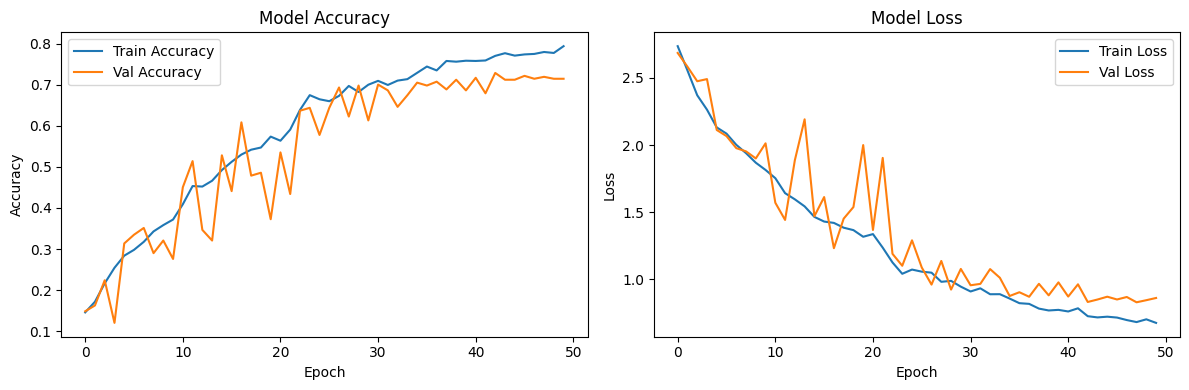


🔨 Building FAISS index from trained model embeddings...
✅ Embedding model initialized and weights copied successfully.
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
✅ Extracted features shape: (2118, 128)
✅ FAISS index built with 2118 vectors

🧪 Running Enhanced Classification Pipelines

🧪 Running Enhanced Classification Pipelines
📐 Converted to 2D shape: (2118, 64, 64, 1)

🏁 Training Enhanced_CNN model...
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.1763 - loss: 2.9384 - val_accuracy: 0.1211 - val_loss: 2.9502 - learning_rate: 2.0000e-04
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2897 - loss: 2.6793 - val_accuracy: 0.1211 - val_loss: 3.0113 - learning_rate: 8.0000e-05
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3343 - loss: 2.5320 - val_accuracy: 0.1211 - val_loss: 3.1221 - learning_rate: 4.8000e-05
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3837 - loss: 2.4317 - val_accuracy: 0.1525 - val_loss: 3.3248 - learning_rate: 3.8400e-05
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4287 - loss: 2.3612 - val_accuracy: 0.1635 - val_loss: 3.4692 - learning_rate: 3.8400e-05
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4433 - loss: 2.3161 - val_accuracy: 0.1352 - val_loss: 3.6234 - learning_rate: 3.8400e-05
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4447 - loss: 2.30

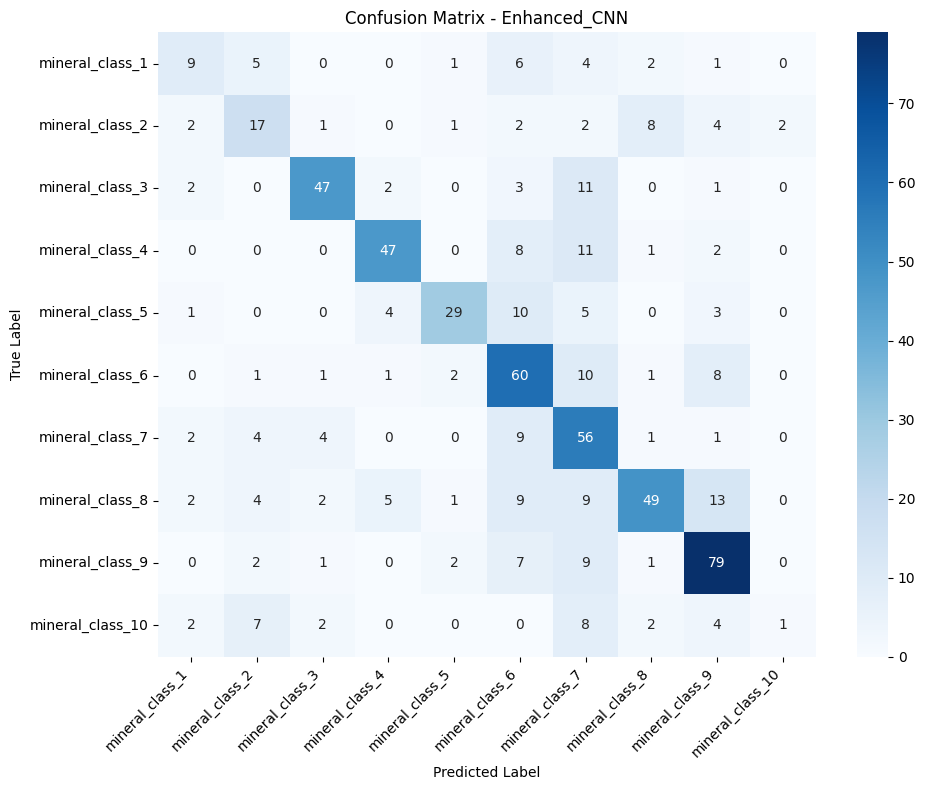

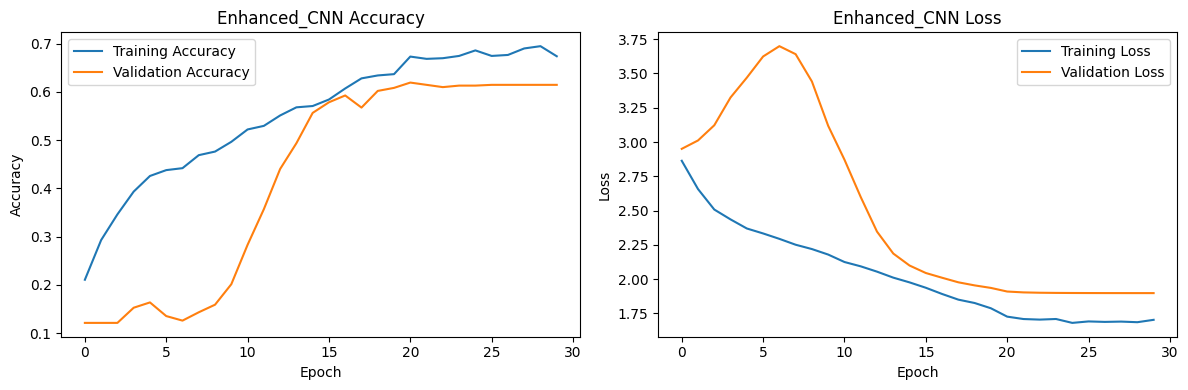

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏁 Training Enhanced_LSTM model...
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.1171 - loss: 2.6225 - val_accuracy: 0.1344 - val_loss: 2.3830 - learning_rate: 2.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.1415 - loss: 2.4517 - val_accuracy: 0.1179 - val_loss: 2.3798 - learning_rate: 8.0000e-05
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1563 - loss: 2.3870 - val_accuracy: 0.1816 - val_loss: 2.3528 - learning_rate: 4.8000e-05
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1959 - loss: 2.3061 - val_accuracy: 0.1887 - val_loss: 2.3339 - learning_rate: 3.8400e-05
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1743 - loss: 2.3215 - val_accuracy: 0.1627 - val_loss: 2.3099 - learning_rate: 3.8400e-05
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.1810 - loss: 2.2777 - val_accuracy: 0.1651 - val_loss: 2.3298 - learning_rate: 3.8400e-05
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


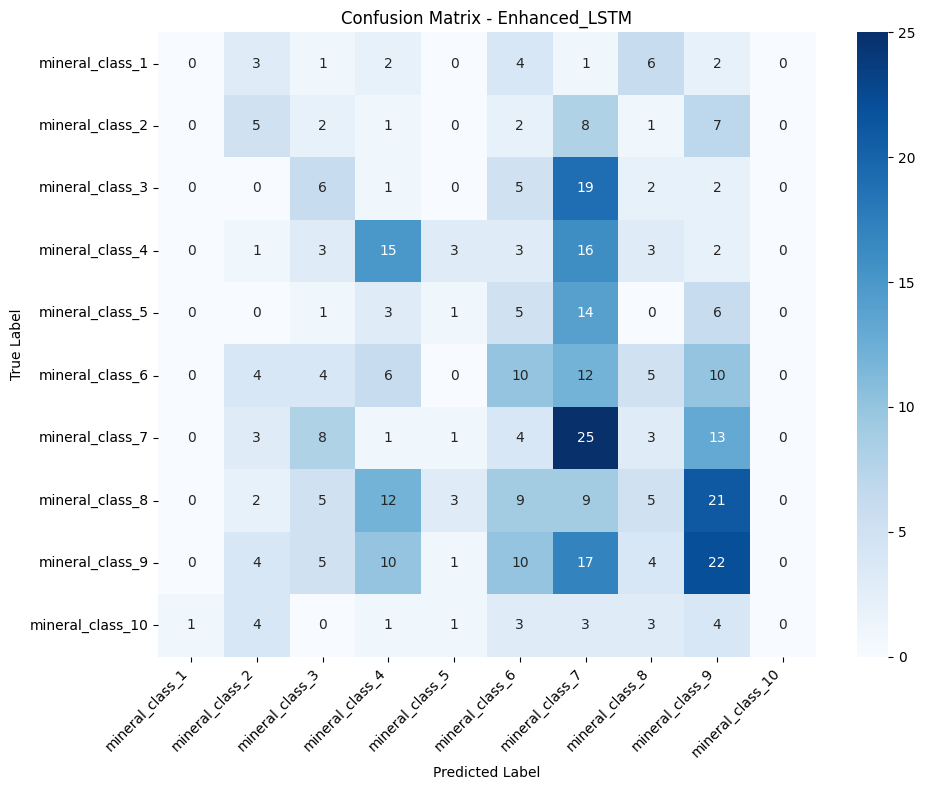

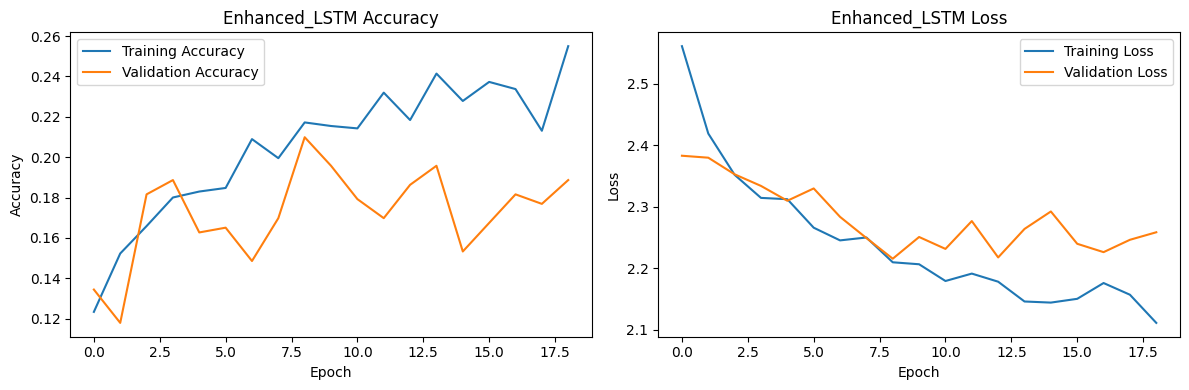

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏁 Training Enhanced_CNN_LSTM model...
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.1793 - loss: 2.6173 - val_accuracy: 0.0920 - val_loss: 2.5432 - learning_rate: 2.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3316 - loss: 2.1999 - val_accuracy: 0.1274 - val_loss: 2.5049 - learning_rate: 8.0000e-05
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3652 - loss: 2.0503 - val_accuracy: 0.2524 - val_loss: 2.3279 - learning_rate: 4.8000e-05
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4167 - loss: 1.9402 - val_accuracy: 0.3467 - val_loss: 2.2019 - learning_rate: 3.8400e-05
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4103 - loss: 1.8981 - val_accuracy: 0.3703 - val_loss: 2.0963 - learning_rate: 3.8400e-05
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4504 - loss: 1.8479 - val_accuracy: 0.4175 - val_loss: 1.9901 - learning_rate: 3.8400e-05
Epoch 7/30
53/53 ━━━━━━━━━━━━━

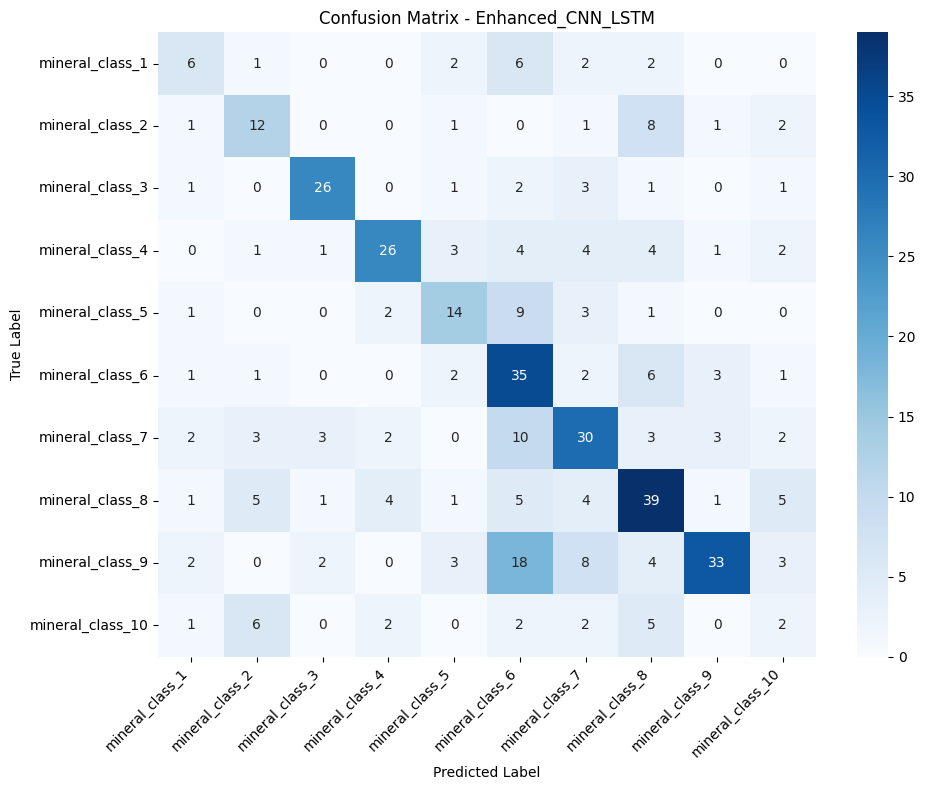

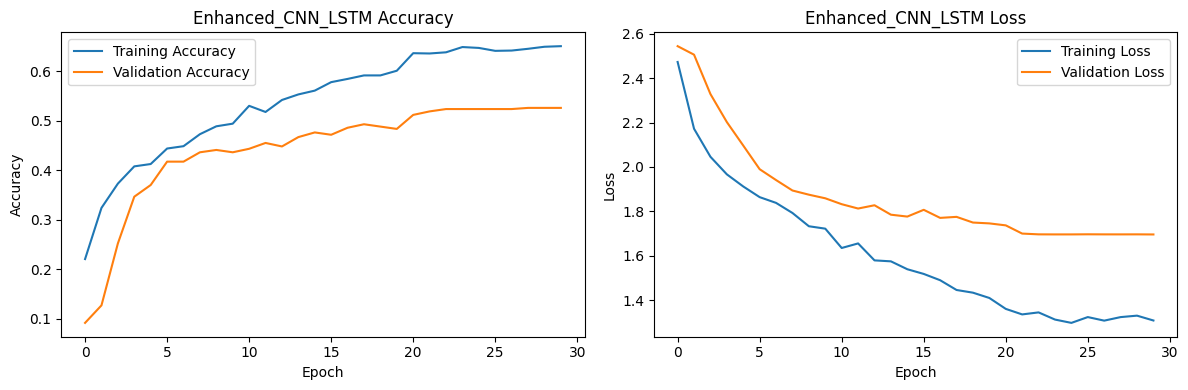


📥 Loading best pre-trained MineralNet model for evaluation...
✅ Model loaded successfully.
🧪 Evaluating loaded MineralNet model...
✅ Loaded MineralNet Test Accuracy: 0.7288
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step

📊 Classification Report for Loaded MineralNet:

                  precision    recall  f1-score   support

 mineral_class_1       0.68      0.71      0.70        21
 mineral_class_2       0.82      0.52      0.64        27
 mineral_class_3       0.96      0.63      0.76        35
 mineral_class_4       0.48      0.72      0.58        39
 mineral_class_5       0.53      0.67      0.59        39
 mineral_class_6       0.86      0.72      0.78        60
 mineral_class_7       0.64      0.75      0.69        60
 mineral_class_8       0.81      0.78      0.80        60
 mineral_class_9       0.95      0.87      0.90        60
mineral_class_10       0.77      0.74      0.76        23

        accuracy                           0.73       424
       macro avg       0.75      0.71  

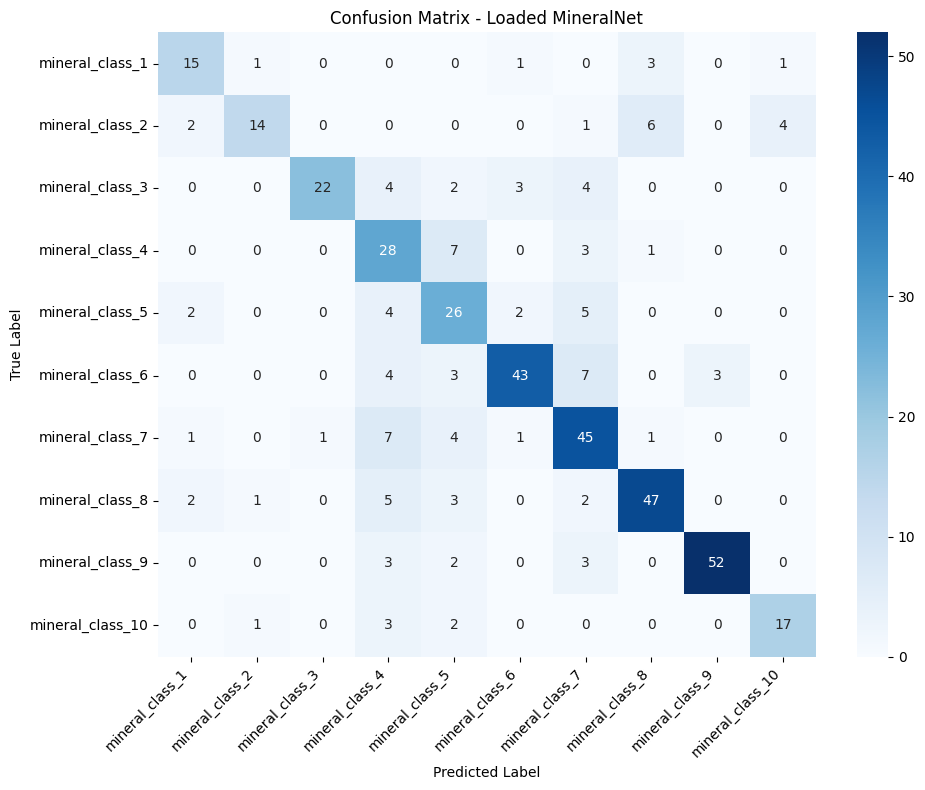


🏆 Enhanced Model Comparison
Enhanced CNN Accuracy: 0.6195
Enhanced LSTM Accuracy: 0.2099
Enhanced CNN+LSTM Accuracy: 0.5259
Loaded MineralNet Accuracy: 0.7288


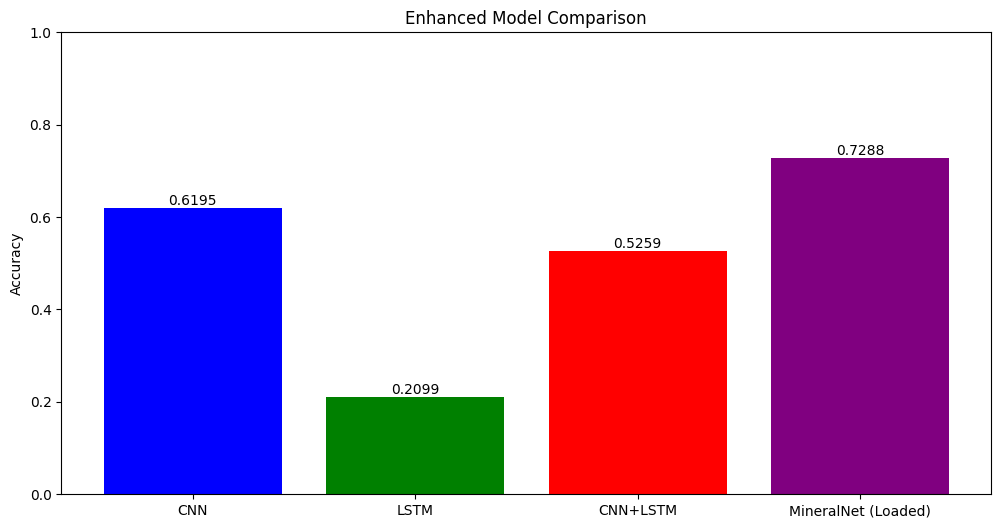


🚀 Deploying model with GPU acceleration...
📥 Loading full model from best_classification_model.keras...
✅ Full model loaded successfully.
⚠️ Failed to load full model: The layer sequential_46 has never been called and thus has no defined input.
🔧 Rebuilding model architecture and loading weights...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_10', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ Weights loaded successfully into rebuilt model.
❌ Failed to rebuild and load weights: The layer sequential_62 has never been called and thus has no defined input.
⚠️ Fallback: Using base MineralNet without weights.
✅ FAISS index loaded successfully.

🚀 Launching CBIR server...
✅ Server is starting in background thread...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net_11', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


🌍 Public URL: https://7840ab73cdc3.ngrok-free.app


INFO:     Started server process [35]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


🚀 Server should now be accessible!
INFO:     110.137.36.223:0 - "GET / HTTP/1.1" 200 OK
INFO:     110.137.36.223:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
🔍 Extracted feature vector shape: (1, 128)
INFO:     110.137.36.223:0 - "POST /search HTTP/1.1" 200 OK


In [ ]:
# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
!pip install faiss-gpu-cu12==1.11.0
!pip install fastapi uvicorn
!pip install pyngrok imagecodecs czifile
!pip install rasterio gdal python-multipart Pillow
from PIL import Image
import imagecodecs
import numpy as np
import tensorflow as tf
import tifffile
tifffile.tifffile.imagecodecs = imagecodecs
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from fastapi import FastAPI, File, UploadFile
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from scipy import ndimage
from skimage import transform
from skimage.transform import resize
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import HTMLResponse
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix  # <-- Tambahkan confusion_matrix
import seaborn as sns  # <-- Tambahkan seaborn untuk visualisasi yang lebih baik
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import io
import shutil
import os
import glob
from keras.saving import register_keras_serializable

# Konfigurasi GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. PREPROCESSING MODULE (GPU OPTIMIZED) - FIXED
# ---------------------------
class VolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size

    def process(self, volume):
        """Full preprocessing pipeline"""
        # 1. Normalize
        volume = self.normalize(volume)

        # 2. Resample
        volume = self.resample(volume)

        # 3. Augment (skip untuk gambar 2D)
        if volume.ndim == 3:  # Hanya augmentasi untuk volume 3D
            volume = self.augment(volume)

        return volume[..., np.newaxis]  # Add channel dim

    def normalize(self, volume):
        """Normalize intensity to 0-1 range"""
        p1, p99 = np.percentile(volume, (1, 99))
        return (np.clip(volume, p1, p99) - p1) / (p99 - p1 + 1e-8)

    def resample(self, volume):
        """Handle 2D and 3D resampling with skimage for better quality"""
        if volume.ndim == 2:
            return self._resample_2d_skimage(volume)
        return self._resample_3d_skimage(volume)

    def _resample_2d_skimage(self, image):
        """Use skimage for high-quality 2D resize"""
        resized = resize(image, self.target_size[:2], anti_aliasing=True, mode='reflect')
        return resized

    def _resample_3d_skimage(self, volume):
        """Use skimage for high-quality 3D resize"""
        resized = resize(volume, self.target_size, anti_aliasing=True, mode='reflect')
        return resized

    def augment(self, volume):
        # Augmentasi 2D/3D yang lebih agresif
        if np.random.rand() > 0.5:
            volume = np.flip(volume, axis=np.random.randint(0, 2))

        if volume.ndim == 3:
            # Rotasi 3D
            axes = tuple(np.random.choice([0, 1, 2], 2, replace=False))
            volume = ndimage.rotate(volume, np.random.uniform(-15, 15), axes=axes, reshape=False)

        # Augmentasi intensitas
        volume = volume * np.random.uniform(0.8, 1.2)
        volume = volume + np.random.uniform(-0.1, 0.1)
        return np.clip(volume, 0, 1)

# ---------------------------
# 2. DATA LOADER MODULE (GPU OPTIMIZED)
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64)):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = VolumePreprocessor(target_shape)
        self.target_shape = target_shape
        self.preload_cache = {}

    def preload_all_data(self, max_samples=300):
        """Preload all data to GPU memory for faster processing"""
        print("⚡ Preloading data to GPU memory...")
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_dir, class_name)

            if not os.path.exists(class_path):
                print(f"❌ Directory not found: {class_path}. Skipping...")
                continue

            tiff_files = glob.glob(os.path.join(class_path, "**", "*.tif"), recursive=True)
            tiff_files += glob.glob(os.path.join(class_path, "**", "*.tiff"), recursive=True)

            if not tiff_files:
                print(f"⚠️ No TIFF files found in {class_path}")
                continue

            samples = tiff_files[:max_samples]
            print(f"🖼️  Preloading {len(samples)} {class_name} samples...")

            for path in samples:
                try:
                    # Load volume
                    volume = tifffile.imread(path)

                    # Preprocess and store in GPU memory
                    self.preload_cache[path] = {
                        'volume': self.preprocessor.process(volume),
                        'label': class_idx
                    }
                except Exception as e:
                    print(f"❌ Error processing {path}: {e}")
                    continue

        print(f"✅ Preloaded {len(self.preload_cache)} samples to GPU memory")

    def load_from_cache(self):
        """Load data from GPU cache"""
        if not self.preload_cache:
            return np.array([]), np.array([])

        volumes = []
        labels = []

        for data in self.preload_cache.values():
            volumes.append(data['volume'])
            labels.append(data['label'])

        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. MODEL ARCHITECTURE MODULE (FIXED + REGISTERED)
# ---------------------------
@register_keras_serializable()
class ChannelAttention(layers.Layer):
    """Simplified Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]
        self.shared_dense = tf.keras.Sequential([
            layers.Dense(channel // self.ratio, activation='relu'),
            layers.Dense(channel, activation='sigmoid')
        ])
        super().build(input_shape)

    def call(self, inputs):
        gap = tf.reduce_mean(inputs, axis=[1, 2, 3], keepdims=True)
        return inputs * self.shared_dense(gap)

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

@register_keras_serializable()
class MineralNet(tf.keras.Model):
    def __init__(self, input_shape, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_val = input_shape

        # 3D-CNN Stream
        self.cnn = tf.keras.Sequential([
            layers.Conv3D(16, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(32, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(64, 3, activation='relu', padding='same'),
            ChannelAttention(),
            layers.GlobalAveragePooling3D()
        ])

        # Fusion and projection
        self.fusion = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ])

    def call(self, inputs):
        if inputs.shape.ndims == 4:
            inputs = tf.expand_dims(inputs, axis=1)
        features = self.cnn(inputs)
        return self.fusion(features)

    def get_config(self):
        config = super().get_config()
        config.update({"input_shape": self.input_shape_val})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# ---------------------------
# 4. TRIPLET MINING MODULE (TIDAK DIGUNAKAN UNTUK KLASIFIKASI, TAPI TETAP DIPERTAHANKAN)
# ---------------------------
class TripletEngine:
    def __init__(self, model):
        self.model = model
        self.index = None
        self.index_built = False

    def build_index(self, X):
        print("\n🔨 Building FAISS index...")
        features = self.model.predict(X, verbose=0)
        self.index = faiss.IndexFlatL2(features.shape[1])
        self.index.add(features.astype('float32'))
        self.index_built = True
        print(f"✅ Index built with {self.index.ntotal} vectors")

    def mine(self, X, y, n_neighbors=5):
        if not self.index_built:
            self.build_index(X)

        print("\n⛏️  Mining hard triplets...")
        features = self.model.predict(X, verbose=0)
        distances, indices = self.index.search(features, n_neighbors+1)

        triplets = []
        for i in range(len(X)):
            # Find positive samples (same class)
            pos_indices = np.where(y[indices[i][1:]] == y[i])[0] + 1

            # Find negative samples (different class)
            neg_indices = np.where(y[indices[i][1:]] != y[i])[0] + 1

            if len(pos_indices) > 0 and len(neg_indices) > 0:
                pos = indices[i][pos_indices[np.argmax(distances[i][pos_indices])]]
                neg = indices[i][neg_indices[np.argmin(distances[i][neg_indices])]]
                triplets.append((i, pos, neg))

        return triplets

# ---------------------------
# 5. TRAINING MODULE (FIXED FOR CLASSIFICATION)
# ---------------------------
def triplet_loss(margin=0.2):
    def loss(y_true, y_pred):
        total_length = tf.shape(y_pred)[0]
        part_length = total_length // 3
        anchor = y_pred[:part_length]
        positive = y_pred[part_length:2*part_length]
        negative = y_pred[2*part_length:]
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss

# ---------------------------
# 8. ENHANCED CLASSIFICATION MODELS
# ---------------------------

def build_enhanced_cnn_model(input_shape, num_classes):
    """Membangun model CNN yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_lstm_model(input_shape, num_classes):
    """Membangun model LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_cnn_lstm_model(input_shape, num_classes):
    """Membangun model hybrid CNN+LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling2D()),

        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Bidirectional(layers.LSTM(128)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_mineralnet_classifier(input_shape, num_classes):
    """Membangun model MineralNet yang ditingkatkan untuk klasifikasi"""
    base_model = MineralNet(input_shape)
    base_model.build(input_shape=(None, *input_shape))

    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def lr_scheduler(epoch, lr):
    """Learning rate scheduler dengan warmup dan decay"""
    if epoch < 5:
        return lr * (epoch + 1) / 5
    elif epoch > 20:
        return lr * 0.1
    return lr

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, epochs=30):
    """Melatih dan mengevaluasi model klasifikasi dengan teknik peningkatan"""
    print(f"\n🏁 Training {model_name} model...")

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        LearningRateScheduler(lr_scheduler),
        ModelCheckpoint(
            f"best_{model_name}.h5",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True
        )
    ]

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks,
                        batch_size=32,
                        verbose=1)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\n📊 Classification Report for {model_name}:\n")
    print(report)

    # --- PENAMBAHAN: CONFUSION MATRIX ---
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()
    # --- AKHIR PENAMBAHAN ---

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    with open(f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)

    return test_acc, report

# ---------------------------
# 9. ENHANCED CLASSIFICATION PIPELINE
# ---------------------------

def run_enhanced_classification_pipeline(X, y, classes, target_size=(64, 64)):
    """Menjalankan pipeline klasifikasi dengan model yang ditingkatkan"""
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")

    # 1. Konversi data 3D menjadi 2D (jika perlu)
    X_2d = []
    for vol in X:
        if vol.ndim == 4 and vol.shape[0] > 1:
            mid = vol.shape[0] // 2
            slice = vol[mid, :, :, 0]
        elif vol.ndim == 3:
            slice = vol[:, :, 0]
        else:
            slice = vol[0]
        X_2d.append(slice)

    X_2d = np.array(X_2d)
    X_2d = X_2d[..., np.newaxis]

    print(f"📐 Converted to 2D shape: {X_2d.shape}")

    # 2. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_2d, y, test_size=0.3, random_state=42
    )

    # 3. CNN
    cnn_model = build_enhanced_cnn_model(
        input_shape=(target_size[0], target_size[1], 1),
        num_classes=len(classes))
    cnn_acc, cnn_report = train_and_evaluate_model(
        cnn_model, X_train, y_train, X_test, y_test, "Enhanced_CNN"
    )

    # 4. LSTM
    X_lstm = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], X_2d.shape[2])
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
        X_lstm, y, test_size=0.2, random_state=42
    )

    lstm_model = build_enhanced_lstm_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        num_classes=len(classes))
    lstm_acc, lstm_report = train_and_evaluate_model(
        lstm_model, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, "Enhanced_LSTM"
    )

    # 5. CNN+LSTM
    X_cnn_lstm = []
    for img in X_2d:
        parts = []
        height = img.shape[0]
        for i in range(4):
            part = img[i*height//4:(i+1)*height//4, :, :]
            part = transform.resize(part, (target_size[0]//2, target_size[1]//2, 1))
            parts.append(part)
        X_cnn_lstm.append(np.array(parts))

    X_cnn_lstm = np.array(X_cnn_lstm)
    X_train_cnn_lstm, X_test_cnn_lstm, y_train_cnn_lstm, y_test_cnn_lstm = train_test_split(
        X_cnn_lstm, y, test_size=0.2, random_state=42
    )

    cnn_lstm_model = build_enhanced_cnn_lstm_model(
        input_shape=(4, target_size[0]//2, target_size[1]//2, 1),
        num_classes=len(classes))
    cnn_lstm_acc, cnn_lstm_report = train_and_evaluate_model(
        cnn_lstm_model,
        X_train_cnn_lstm, y_train_cnn_lstm,
        X_test_cnn_lstm, y_test_cnn_lstm,
        "Enhanced_CNN_LSTM"
    )

    # 6. MUAT MODEL MINERALNET TERBAIK DARI FILE (BUKAN LATIH ULANG)
    print("\n📥 Loading best pre-trained MineralNet model for evaluation...")
    try:
        mineral_model = tf.keras.models.load_model("best_classification_model.keras")
        print("✅ Model loaded successfully.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Fallback: Building and evaluating a new MineralNet model...")
        X_3d = np.array([vol[:, :, :, 0] if vol.ndim == 4 else vol for vol in X])
        X_3d = X_3d[..., np.newaxis]
        X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_3d, y, test_size=0.2, random_state=42)
        mineral_model = build_enhanced_mineralnet_classifier((64,64,64,1), len(classes))
        mineral_acc, mineral_report = train_and_evaluate_model(
            mineral_model, X_train_min, y_train_min, X_test_min, y_test_min, "Enhanced_MineralNet"
        )
    else:
        X_test_min = X_test_min_global
        y_test_min = y_test_min_global
        print("🧪 Evaluating loaded MineralNet model...")
        test_loss, mineral_acc = mineral_model.evaluate(X_test_min, y_test_min, verbose=0)
        print(f"✅ Loaded MineralNet Test Accuracy: {mineral_acc:.4f}")

        y_pred = mineral_model.predict(X_test_min)
        y_pred_classes = np.argmax(y_pred, axis=1)
        mineral_report = classification_report(y_test_min, y_pred_classes, target_names=classes)
        print(f"\n📊 Classification Report for Loaded MineralNet:\n")
        print(mineral_report)

        # --- PENAMBAHAN: CONFUSION MATRIX UNTUK MINERALNET ---
        cm = confusion_matrix(y_test_min, y_pred_classes)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title('Confusion Matrix - Loaded MineralNet')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig("Loaded_MineralNet_confusion_matrix.png")
        plt.show()
        # --- AKHIR PENAMBAHAN ---

        with open("Loaded_MineralNet_classification_report.txt", "w") as f:
            f.write(mineral_report)

    # 7. Tampilkan hasil perbandingan
    print("\n" + "="*80)
    print("🏆 Enhanced Model Comparison")
    print(f"Enhanced CNN Accuracy: {cnn_acc:.4f}")
    print(f"Enhanced LSTM Accuracy: {lstm_acc:.4f}")
    print(f"Enhanced CNN+LSTM Accuracy: {cnn_lstm_acc:.4f}")
    print(f"Loaded MineralNet Accuracy: {mineral_acc:.4f}")

    with open("all_classification_reports.txt", "w") as f:
        f.write("=== Enhanced CNN Classification Report ===\n")
        f.write(cnn_report)
        f.write("\n\n=== Enhanced LSTM Classification Report ===\n")
        f.write(lstm_report)
        f.write("\n\n=== Enhanced CNN+LSTM Classification Report ===\n")
        f.write(cnn_lstm_report)
        f.write("\n\n=== Loaded MineralNet Classification Report ===\n")
        f.write(mineral_report)

    models = ['CNN', 'LSTM', 'CNN+LSTM', 'MineralNet (Loaded)']
    accuracies = [cnn_acc, lstm_acc, cnn_lstm_acc, mineral_acc]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
    plt.ylabel('Accuracy')
    plt.title('Enhanced Model Comparison')
    plt.ylim(0, 1.0)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.savefig("enhanced_model_comparison.png")
    plt.show()

    return {
        'cnn': cnn_acc,
        'lstm': lstm_acc,
        'cnn_lstm': cnn_lstm_acc,
        'mineralnet': mineral_acc
    }

# ---------------------------
# 7. DEPLOYMENT MODULE (FIXED & COMPATIBLE)
# ---------------------------
class CBIRServer:
    def __init__(self, model_path):
        custom_objects = {
            'ChannelAttention': ChannelAttention,
            'MineralNet': MineralNet
        }

        try:
            print(f"📥 Loading full model from {model_path}...")
            self.full_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            print("✅ Full model loaded successfully.")

            embedding_layer = self.full_model.layers[-2]
            self.model = tf.keras.Model(
                inputs=self.full_model.input,
                outputs=embedding_layer.output
            )
            print("✅ Embedding model created successfully.")

        except Exception as e:
            print(f"⚠️ Failed to load full model: {e}")
            print("🔧 Rebuilding model architecture and loading weights...")

            try:
                base_model = MineralNet(input_shape=(64,64,64,1))
                base_model.build(input_shape=(None, 64,64,64,1))

                self.full_model = models.Sequential([
                    base_model,
                    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
                    layers.BatchNormalization(),
                    layers.Dropout(0.5),
                    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
                    layers.Dropout(0.3),
                    layers.Dense(len(CLASSES), activation='softmax')
                ])
                self.full_model.build(input_shape=(None, 64,64,64,1))

                self.full_model.load_weights(model_path)
                print("✅ Weights loaded successfully into rebuilt model.")

                embedding_layer = self.full_model.layers[-2]
                self.model = tf.keras.Model(
                    inputs=self.full_model.input,
                    outputs=embedding_layer.output
                )
                print("✅ Embedding model created from rebuilt architecture.")

            except Exception as load_err:
                print(f"❌ Failed to rebuild and load weights: {load_err}")
                print("⚠️ Fallback: Using base MineralNet without weights.")
                self.model = MineralNet(input_shape=(64,64,64,1))
                self.model.build(input_shape=(None, 64,64,64,1))

        self.index = None
        self.app = FastAPI()

        self.app.add_middleware(
            CORSMiddleware,
            allow_origins=["*"],
            allow_credentials=True,
            allow_methods=["*"],
            allow_headers=["*"],
        )

        @self.app.post("/search")
        async def search(file: UploadFile = File(...)):
            return await self._process_search(file)

        @self.app.get("/")
        async def ui():
            return self.get_web_interface()

    def run(self, port=8000, ngrok_auth=None):
        print("\n🚀 Launching CBIR server...")
        if ngrok_auth:
            ngrok.set_auth_token(ngrok_auth)
            public_url = ngrok.connect(port).public_url
            print(f"🌍 Public URL: {public_url}")

        nest_asyncio.apply()
        uvicorn.run(self.app, host="0.0.0.0", port=port)

    async def _process_search(self, file: UploadFile):
        try:
            valid_extensions = ('.tif', '.tiff', '.jpg', '.jpeg', '.png')
            if not file.filename.lower().endswith(valid_extensions):
                return {"error": "Only TIFF, JPG, and PNG files are supported"}

            MAX_SIZE = 10 * 1024 * 1024

            temp_path = f"temp_{file.filename}"
            with open(temp_path, "wb") as buffer:
                shutil.copyfileobj(file.file, buffer)

            file_size = os.path.getsize(temp_path)
            if file_size > MAX_SIZE:
                os.remove(temp_path)
                return {"error": f"File size exceeds 10 MB limit ({file_size/1024/1024:.2f} MB)"}

            if file.filename.lower().endswith(('.tif', '.tiff')):
                volume = tifffile.imread(temp_path)
            else:
                img = Image.open(temp_path)
                if img.mode != 'L':
                    img = img.convert('L')
                volume = np.array(img)

            os.remove(temp_path)

            if volume.ndim == 2:
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3 and volume.shape[-1] in [3, 4]:
                volume = np.mean(volume, axis=-1)
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3:
                if volume.shape[0] < volume.shape[1] and volume.shape[0] < volume.shape[2]:
                    volume = np.transpose(volume, (1, 2, 0))

            preprocessor = VolumePreprocessor(target_size=(64, 64, 64))
            volume = preprocessor.process(volume)
            volume = np.expand_dims(volume, axis=0)

            features = self.model.predict(volume, verbose=0)
            print(f"🔍 Extracted feature vector shape: {features.shape}")

            if self.index is None:
                return {"error": "FAISS index not loaded. Please load index before searching."}

            distances, indices = self.index.search(features.astype('float32'), 5)

            return {
                "results": [
                    {"id": int(idx), "distance": float(dist)}
                    for dist, idx in zip(distances[0], indices[0])
                ]
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            return {
                "error": f"Server error: {str(e)}"
            }

    def get_web_interface(self):
        return HTMLResponse("""
        <!DOCTYPE html>
        <html>
        <head>
            <title>Rock CBIR System</title>
            <style>
                body { font-family: Arial, sans-serif; margin: 40px; }
                .container { max-width: 800px; margin: 0 auto; }
                h1 { text-align: center; color: #2c3e50; }
                .upload-box {
                    border: 2px dashed #3498db;
                    border-radius: 10px;
                    padding: 30px;
                    text-align: center;
                    background-color: #f8f9fa;
                    margin-bottom: 20px;
                }
                .btn {
                    background-color: #3498db;
                    color: white;
                    padding: 10px 20px;
                    border: none;
                    border-radius: 5px;
                    cursor: pointer;
                    font-size: 16px;
                    transition: background-color 0.3s;
                }
                .btn:hover { background-color: #2980b9; }
                .btn:disabled { background-color: #95a5a6; cursor: not-allowed; }
                .error { color: #e74c3c; font-weight: bold; margin: 10px 0; }
                #result-container { margin-top: 20px; }
                .result-item {
                    border: 1px solid #ddd;
                    border-radius: 5px;
                    padding: 15px;
                    margin-bottom: 10px;
                    background-color: #f9f9f9;
                    box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                }
                .result-image {
                    max-width: 100%;
                    max-height: 300px;
                    border: 1px solid #ddd;
                    border-radius: 4px;
                    padding: 5px;
                    margin: 10px 0;
                    display: block;
                }
                .loading {
                    display: inline-block;
                    width: 20px;
                    height: 20px;
                    border: 3px solid rgba(0,0,0,.3);
                    border-radius: 50%;
                    border-top-color: #3498db;
                    animation: spin 1s ease-in-out infinite;
                    margin-right: 10px;
                    vertical-align: middle;
                }
                @keyframes spin {
                    to { transform: rotate(360deg); }
                }
                .results-grid {
                    display: grid;
                    grid-template-columns: repeat(auto-fill, minmax(150px, 1fr));
                    gap: 15px;
                    margin-top: 20px;
                }
                .result-card {
                    border: 1px solid #eee;
                    border-radius: 8px;
                    padding: 10px;
                    text-align: center;
                    background: white;
                    box-shadow: 0 2px 5px rgba(0,0,0,0.1);
                }
                .placeholder-img {
                    width: 100%;
                    height: 100px;
                    background-color: #f0f0f0;
                    border-radius: 4px;
                    margin-bottom: 10px;
                }
            </style>
        </head>
        <body>
            <div class="container">
                <h1>Rock Content-Based Image Retrieval</h1>
                <div class="upload-box">
                    <form id="upload-form">
                        <input type="file" name="file" id="file-input" style="display: none;"
                               accept=".tif,.tiff,.jpg,.jpeg,.png">
                        <label for="file-input" class="btn">Choose Image File</label>
                        <p id="file-name">No file selected</p>
                        <div style="margin: 15px 0; font-size: 14px; color: #7f8c8d;">
                            Supported formats: TIFF, JPG, PNG (max 10MB)
                        </div>
                        <button type="button" id="submit-btn" class="btn">
                            <span id="spinner" style="display:none;" class="loading"></span>
                            <span id="btn-text">Search Similar Rocks</span>
                        </button>
                        <div id="error-message" class="error"></div>
                    </form>
                </div>
                <div id="result-container"></div>
            </div>
            <script>
                document.getElementById('file-input').addEventListener('change', function(e) {
                    const fileName = e.target.files[0] ? e.target.files[0].name : 'No file selected';
                    document.getElementById('file-name').textContent = fileName;
                    document.getElementById('error-message').textContent = '';
                });

                document.getElementById('submit-btn').addEventListener('click', async function() {
                    const fileInput = document.getElementById('file-input');
                    const file = fileInput.files[0];
                    const spinner = document.getElementById('spinner');
                    const btnText = document.getElementById('btn-text');
                    const errorMsg = document.getElementById('error-message');
                    const resultContainer = document.getElementById('result-container');

                    resultContainer.innerHTML = '';
                    errorMsg.textContent = '';

                    if (!file) {
                        errorMsg.textContent = 'Please select a file';
                        return;
                    }

                    const validExtensions = ['.tif', '.tiff', '.jpg', '.jpeg', '.png'];
                    const fileExt = '.' + file.name.toLowerCase().split('.').pop();
                    if (!validExtensions.includes(fileExt)) {
                        errorMsg.textContent = 'Only TIFF, JPG, and PNG files are supported';
                        return;
                    }

                    const MAX_SIZE = 10 * 1024 * 1024;
                    if (file.size > MAX_SIZE) {
                        errorMsg.textContent =
                            `File size exceeds limit (${(file.size/1024/1024).toFixed(2)} MB > 10 MB)`;
                        return;
                    }

                    spinner.style.display = 'inline-block';
                    btnText.textContent = 'Processing...';
                    document.getElementById('submit-btn').disabled = true;

                    try {
                        const formData = new FormData();
                        formData.append('file', file);

                        const response = await fetch('/search', {
                            method: 'POST',
                            body: formData
                        });

                        if (!response.ok) {
                            const errorText = await response.text();
                            throw new Error(`Server error: ${response.status} - ${errorText}`);
                        }

                        const result = await response.json();

                        if (result.error) {
                            errorMsg.textContent = result.error;
                        } else if (!result.results || !Array.isArray(result.results)) {
                            errorMsg.textContent = 'Invalid response format from server';
                        } else {
                            const reader = new FileReader();
                            reader.onload = function(e) {
                                const uploadedDiv = document.createElement('div');
                                uploadedDiv.innerHTML = '<h3>Uploaded Image:</h3>';

                                const uploadedImg = document.createElement('img');
                                uploadedImg.src = e.target.result;
                                uploadedImg.className = 'result-image';
                                uploadedImg.alt = 'Uploaded image';

                                uploadedDiv.appendChild(uploadedImg);
                                resultContainer.appendChild(uploadedDiv);
                            };
                            reader.readAsDataURL(file);

                            const resultsDiv = document.createElement('div');
                            resultsDiv.innerHTML = '<h3>Similar Rocks:</h3>';
                            resultContainer.appendChild(resultsDiv);

                            const grid = document.createElement('div');
                            grid.className = 'results-grid';

                            result.results.forEach((item, index) => {
                                const card = document.createElement('div');
                                card.className = 'result-card';

                                const imgPlaceholder = document.createElement('div');
                                imgPlaceholder.className = 'placeholder-img';
                                imgPlaceholder.style.backgroundColor = `hsl(${index * 60}, 70%, 85%)`;

                                const info = document.createElement('div');
                                info.innerHTML = `
                                    <div><strong>#${index + 1}</strong></div>
                                    <div>ID: ${item.id}</div>
                                    <div>Distance: ${item.distance.toFixed(4)}</div>
                                `;

                                card.appendChild(imgPlaceholder);
                                card.appendChild(info);
                                grid.appendChild(card);
                            });

                            resultsDiv.appendChild(grid);
                        }
                    } catch (error) {
                        errorMsg.textContent = 'Error: ' + error.message;
                        console.error(error);
                    } finally {
                        spinner.style.display = 'none';
                        btnText.textContent = 'Search Similar Rocks';
                        document.getElementById('submit-btn').disabled = false;
                    }
                });
            </script>
        </body>
        </html>
        """)

# ---------------------------
# MAIN EXECUTION FLOW (FINAL OPTIMIZED VERSION)
# ---------------------------
if __name__ == "__main__":
    # 1. Initialize components
    DATA_DIR = "/kaggle/working/Raw_2D_tiff/"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']

    print("="*80)
    print("🔍 Verifying data directory...")

    if not os.path.exists(DATA_DIR):
        print(f"❌ ERROR: Data directory '{DATA_DIR}' not found!")
        exit(1)
    else:
        print(f"✅ Data directory found: {DATA_DIR}")

    tiff_files = glob.glob(os.path.join(DATA_DIR, "**", "*.tif"), recursive=True)
    tiff_files += glob.glob(os.path.join(DATA_DIR, "**", "*.tiff"), recursive=True)
    print(f"📂 Found {len(tiff_files)} TIFF files in dataset")

    # 2. Load data
    print("\n" + "="*80)
    print("🚚 Loading dataset...")
    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(64,64,64))
    dataset.preload_all_data(max_samples=300)
    X, y = dataset.load_from_cache()

    if len(X) == 0:
        print("\n❌ CRITICAL ERROR: No samples loaded!")
        exit(1)

    print(f"✅ Dataset loaded: {X.shape[0]} samples")

    # Split data — simpan global untuk pipeline klasifikasi
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"🔢 Train/val split: {X_train.shape[0]}/{X_val.shape[0]} samples")

    # Simpan untuk pipeline klasifikasi
    global X_test_min_global, y_test_min_global
    X_test_min_global = X_val
    y_test_min_global = y_val

    # 3. Build classification model
    print("\n" + "="*80)
    print("🧠 Building classification-optimized MineralNet...")
    base_model = MineralNet(input_shape=(64,64,64,1))
    base_model.build(input_shape=(None, 64,64,64,1))

    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation='softmax')
    ])

    model.build(input_shape=(None, 64, 64, 64, 1))
    model.summary()

    # 4. Compile & Train
    print("\n" + "="*80)
    print("⚙️  Compiling model...")
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        ModelCheckpoint(
            "best_classification_model.keras",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        CSVLogger('classification_training.log')
    ]

    print("\n" + "="*80)
    print("🏋️ Starting classification training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # 5. Final Evaluation
    print("\n" + "="*80)
    print("📊 Final Evaluation...")
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ FINAL VALIDATION ACCURACY: {test_acc:.4f}")

    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes, target_names=CLASSES)
    print(f"\n📋 Classification Report:\n{report}")

    with open("final_classification_report.txt", "w") as f:
        f.write(report)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig("final_training_history.png")
    plt.show()

    # 6. Build FAISS Index from Embedding Layer
    print("\n" + "="*80)
    print("🔨 Building FAISS index from trained model embeddings...")
    # --- SOLUSI YANG BENAR-BENAR BEKERJA ---
    # Langkah 1: Buat instance baru dari MineralNet
    embedding_model = MineralNet(input_shape=(64,64,64,1))

    # Langkah 2: PAKSA INISIALISASI BOBOT dengan memanggil model sekali
    # Gunakan satu sampel data nyata dari X_train
    dummy_input = X_train[:1]  # Ambil 1 sampel nyata
    _ = embedding_model(dummy_input)  # Ini akan membuat semua bobot terinisialisasi

    # Langkah 3: Salin bobot dari lapisan MineralNet di model yang sudah dilatih
    trained_mineralnet_layer = model.layers[0]  # Ini adalah instance MineralNet yang sudah dilatih
    embedding_model.set_weights(trained_mineralnet_layer.get_weights())
    print("✅ Embedding model initialized and weights copied successfully.")

    # Ekstrak fitur dari SEMUA data (X) menggunakan model embedding
    features = embedding_model.predict(X, batch_size=16, verbose=1)
    print(f"✅ Extracted features shape: {features.shape}")

    # Bangun dan simpan indeks FAISS
    dimension = features.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(features.astype('float32'))
    print(f"✅ FAISS index built with {index.ntotal} vectors")
    faiss.write_index(index, "rock_index.faiss")

    # 7. Run Enhanced Classification Pipeline (akan load model ini, bukan latih ulang)
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    classification_results = run_enhanced_classification_pipeline(X, y, CLASSES)

    # 8. Deploy Server
    print("\n" + "="*80)
    print("🚀 Deploying model with GPU acceleration...")

    model_file = "best_classification_model.keras"
    server = CBIRServer(model_file)

    try:
        server.index = faiss.read_index("rock_index.faiss")
        print("✅ FAISS index loaded successfully.")
    except Exception as e:
        print(f"❌ Failed to load FAISS index: {e}")
        print("⚠️ Server will run but search may not work properly.")

    # Ganti dengan token ngrok Anda
    import threading
    import time

    def run_server():
        server.run(ngrok_auth="2wCivC14NEGZe5IUUH7OlldqSat_5Q5vWTMiQ8TqQu5Px6JQX")

    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()
    print("✅ Server is starting in background thread...")
    time.sleep(3)  # Tunggu 3 detik agar server sempat start
    print("🚀 Server should now be accessible!")

2026-02-11 07:51:21.492024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770796281.867218    1454 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770796281.974684    1454 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2 Physical GPUs, 2 Logical GPUs
🔍 Verifying data directory...
✅ Data directory found: /kaggle/working/Raw_2D_tiff/
📂 Found 5095 TIFF files in dataset

🚚 Loading dataset...
⚡ Preloading data to GPU memory...
🖼️  Preloading 300 mineral_class_1 samples...


I0000 00:00:1770796298.279339    1454 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770796298.282509    1454 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


🖼️  Preloading 300 mineral_class_2 samples...
🖼️  Preloading 300 mineral_class_3 samples...
🖼️  Preloading 300 mineral_class_4 samples...
🖼️  Preloading 300 mineral_class_5 samples...
🖼️  Preloading 300 mineral_class_6 samples...
🖼️  Preloading 300 mineral_class_7 samples...
🖼️  Preloading 300 mineral_class_8 samples...
🖼️  Preloading 300 mineral_class_9 samples...
🖼️  Preloading 300 mineral_class_10 samples...
✅ Preloaded 3000 samples to GPU memory
✅ Dataset loaded: 3000 samples
🔢 Train/val split: 2400/600 samples

🧠 Building classification-optimized MineralNet...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mineral_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


...


⚙️  Compiling model...

🏋️ Starting classification training...
Epoch 1/30


I0000 00:00:1770796664.699419    1517 service.cc:148] XLA service 0x7a1d78089290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770796664.701132    1517 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770796664.701153    1517 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770796665.354376    1517 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/150 ━━━━━━━━━━━━━━━━━━━━ 32:51 13s/step - accuracy: 0.0625 - loss: 2.8682

I0000 00:00:1770796672.737021    1517 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.0954 - loss: 2.8021 - val_accuracy: 0.1000 - val_loss: 2.6528 - learning_rate: 0.0010
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.1230 - loss: 2.6102 - val_accuracy: 0.1300 - val_loss: 2.5395 - learning_rate: 0.0010
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.1365 - loss: 2.4774 - val_accuracy: 0.1917 - val_loss: 2.3962 - learning_rate: 0.0010
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.1294 - loss: 2.4092 - val_accuracy: 0.1617 - val_loss: 2.3317 - learning_rate: 0.0010
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.1850 - loss: 2.2940 - val_accuracy: 0.2050 - val_loss: 2.2151 - learning_rate: 0.0010
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.1972 - loss: 2.2482 - val_accuracy: 0.2083 - val_loss: 2.1263 - learning_rate: 0.0010
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.2128 - loss: 2.202

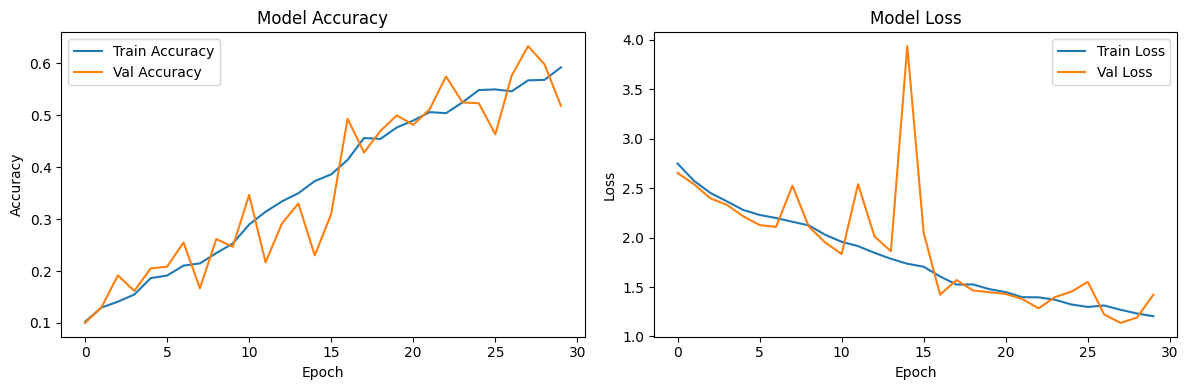


🔨 Building FAISS index from trained model embeddings...
✅ Embedding model initialized and weights copied successfully.


In [ ]:
# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
!pip install faiss-gpu-cu12==1.11.0
!pip install fastapi uvicorn
!pip install pyngrok imagecodecs czifile
!pip install rasterio gdal python-multipart Pillow
from PIL import Image
import imagecodecs
import numpy as np
import tensorflow as tf
import tifffile
tifffile.tifffile.imagecodecs = imagecodecs
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from fastapi import FastAPI, File, UploadFile
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from scipy import ndimage
from skimage import transform
from skimage.transform import resize
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import HTMLResponse
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix  # <-- Tambahkan confusion_matrix
import seaborn as sns  # <-- Tambahkan seaborn untuk visualisasi yang lebih baik
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import io
import shutil
import os
import glob
from keras.saving import register_keras_serializable

# Konfigurasi GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. PREPROCESSING MODULE (GPU OPTIMIZED) - FIXED
# ---------------------------
class VolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size

    def process(self, volume):
        """Full preprocessing pipeline"""
        # 1. Normalize
        volume = self.normalize(volume)

        # 2. Resample
        volume = self.resample(volume)

        # 3. Augment (skip untuk gambar 2D)
        if volume.ndim == 3:  # Hanya augmentasi untuk volume 3D
            volume = self.augment(volume)

        return volume[..., np.newaxis]  # Add channel dim

    def normalize(self, volume):
        """Normalize intensity to 0-1 range"""
        p1, p99 = np.percentile(volume, (1, 99))
        return (np.clip(volume, p1, p99) - p1) / (p99 - p1 + 1e-8)

    def resample(self, volume):
        """Handle 2D and 3D resampling with skimage for better quality"""
        if volume.ndim == 2:
            return self._resample_2d_skimage(volume)
        return self._resample_3d_skimage(volume)

    def _resample_2d_skimage(self, image):
        """Use skimage for high-quality 2D resize"""
        resized = resize(image, self.target_size[:2], anti_aliasing=True, mode='reflect')
        return resized

    def _resample_3d_skimage(self, volume):
        """Use skimage for high-quality 3D resize"""
        resized = resize(volume, self.target_size, anti_aliasing=True, mode='reflect')
        return resized

    def augment(self, volume):
        # Augmentasi 2D/3D yang lebih agresif
        if np.random.rand() > 0.5:
            volume = np.flip(volume, axis=np.random.randint(0, 2))

        if volume.ndim == 3:
            # Rotasi 3D
            axes = tuple(np.random.choice([0, 1, 2], 2, replace=False))
            volume = ndimage.rotate(volume, np.random.uniform(-15, 15), axes=axes, reshape=False)

        # Augmentasi intensitas
        volume = volume * np.random.uniform(0.8, 1.2)
        volume = volume + np.random.uniform(-0.1, 0.1)
        return np.clip(volume, 0, 1)

# ---------------------------
# 2. DATA LOADER MODULE (GPU OPTIMIZED)
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64)):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = VolumePreprocessor(target_shape)
        self.target_shape = target_shape
        self.preload_cache = {}

    def preload_all_data(self, max_samples=300):
        """Preload all data to GPU memory for faster processing"""
        print("⚡ Preloading data to GPU memory...")
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_dir, class_name)

            if not os.path.exists(class_path):
                print(f"❌ Directory not found: {class_path}. Skipping...")
                continue

            tiff_files = glob.glob(os.path.join(class_path, "**", "*.tif"), recursive=True)
            tiff_files += glob.glob(os.path.join(class_path, "**", "*.tiff"), recursive=True)

            if not tiff_files:
                print(f"⚠️ No TIFF files found in {class_path}")
                continue

            samples = tiff_files[:max_samples]
            print(f"🖼️  Preloading {len(samples)} {class_name} samples...")

            for path in samples:
                try:
                    # Load volume
                    volume = tifffile.imread(path)

                    # Preprocess and store in GPU memory
                    self.preload_cache[path] = {
                        'volume': self.preprocessor.process(volume),
                        'label': class_idx
                    }
                except Exception as e:
                    print(f"❌ Error processing {path}: {e}")
                    continue

        print(f"✅ Preloaded {len(self.preload_cache)} samples to GPU memory")

    def load_from_cache(self):
        """Load data from GPU cache"""
        if not self.preload_cache:
            return np.array([]), np.array([])

        volumes = []
        labels = []

        for data in self.preload_cache.values():
            volumes.append(data['volume'])
            labels.append(data['label'])

        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. MODEL ARCHITECTURE MODULE (FIXED + REGISTERED)
# ---------------------------
@register_keras_serializable()
class ChannelAttention(layers.Layer):
    """Simplified Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]
        self.shared_dense = tf.keras.Sequential([
            layers.Dense(channel // self.ratio, activation='relu'),
            layers.Dense(channel, activation='sigmoid')
        ])
        super().build(input_shape)

    def call(self, inputs):
        gap = tf.reduce_mean(inputs, axis=[1, 2, 3], keepdims=True)
        return inputs * self.shared_dense(gap)

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

@register_keras_serializable()
class MineralNet(tf.keras.Model):
    def __init__(self, input_shape, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_val = input_shape

        # 3D-CNN Stream
        self.cnn = tf.keras.Sequential([
            layers.Conv3D(16, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(32, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(64, 3, activation='relu', padding='same'),
            ChannelAttention(),
            layers.GlobalAveragePooling3D()
        ])

        # Fusion and projection
        self.fusion = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ])

    def call(self, inputs):
        if inputs.shape.ndims == 4:
            inputs = tf.expand_dims(inputs, axis=1)
        features = self.cnn(inputs)
        return self.fusion(features)

    def get_config(self):
        config = super().get_config()
        config.update({"input_shape": self.input_shape_val})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# ---------------------------
# 4. TRIPLET MINING MODULE (TIDAK DIGUNAKAN UNTUK KLASIFIKASI, TAPI TETAP DIPERTAHANKAN)
# ---------------------------
class TripletEngine:
    def __init__(self, model):
        self.model = model
        self.index = None
        self.index_built = False

    def build_index(self, X):
        print("\n🔨 Building FAISS index...")
        features = self.model.predict(X, verbose=0)
        self.index = faiss.IndexFlatL2(features.shape[1])
        self.index.add(features.astype('float32'))
        self.index_built = True
        print(f"✅ Index built with {self.index.ntotal} vectors")

    def mine(self, X, y, n_neighbors=5):
        if not self.index_built:
            self.build_index(X)

        print("\n⛏️  Mining hard triplets...")
        features = self.model.predict(X, verbose=0)
        distances, indices = self.index.search(features, n_neighbors+1)

        triplets = []
        for i in range(len(X)):
            # Find positive samples (same class)
            pos_indices = np.where(y[indices[i][1:]] == y[i])[0] + 1

            # Find negative samples (different class)
            neg_indices = np.where(y[indices[i][1:]] != y[i])[0] + 1

            if len(pos_indices) > 0 and len(neg_indices) > 0:
                pos = indices[i][pos_indices[np.argmax(distances[i][pos_indices])]]
                neg = indices[i][neg_indices[np.argmin(distances[i][neg_indices])]]
                triplets.append((i, pos, neg))

        return triplets

# ---------------------------
# 5. TRAINING MODULE (FIXED FOR CLASSIFICATION)
# ---------------------------
def triplet_loss(margin=0.2):
    def loss(y_true, y_pred):
        total_length = tf.shape(y_pred)[0]
        part_length = total_length // 3
        anchor = y_pred[:part_length]
        positive = y_pred[part_length:2*part_length]
        negative = y_pred[2*part_length:]
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss

# ---------------------------
# 8. ENHANCED CLASSIFICATION MODELS
# ---------------------------

def build_enhanced_cnn_model(input_shape, num_classes):
    """Membangun model CNN yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_lstm_model(input_shape, num_classes):
    """Membangun model LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_cnn_lstm_model(input_shape, num_classes):
    """Membangun model hybrid CNN+LSTM yang ditingkatkan untuk klasifikasi"""
    model = models.Sequential([
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling2D()),

        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Bidirectional(layers.LSTM(128)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_mineralnet_classifier(input_shape, num_classes):
    """Membangun model MineralNet yang ditingkatkan untuk klasifikasi"""
    base_model = MineralNet(input_shape)
    base_model.build(input_shape=(None, *input_shape))

    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def lr_scheduler(epoch, lr):
    """Learning rate scheduler dengan warmup dan decay"""
    if epoch < 5:
        return lr * (epoch + 1) / 5
    elif epoch > 20:
        return lr * 0.1
    return lr

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, epochs=30):
    """Melatih dan mengevaluasi model klasifikasi dengan teknik peningkatan"""
    print(f"\n🏁 Training {model_name} model...")

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        LearningRateScheduler(lr_scheduler),
        ModelCheckpoint(
            f"best_{model_name}.h5",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True
        )
    ]

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks,
                        batch_size=32,
                        verbose=1)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\n📊 Classification Report for {model_name}:\n")
    print(report)

    # --- PENAMBAHAN: CONFUSION MATRIX ---
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()
    # --- AKHIR PENAMBAHAN ---

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    with open(f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)

    return test_acc, report

# ---------------------------
# 9. ENHANCED CLASSIFICATION PIPELINE
# ---------------------------

def run_enhanced_classification_pipeline(X, y, classes, target_size=(64, 64)):
    """Menjalankan pipeline klasifikasi dengan model yang ditingkatkan"""
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")

    # 1. Konversi data 3D menjadi 2D (jika perlu)
    X_2d = []
    for vol in X:
        if vol.ndim == 4 and vol.shape[0] > 1:
            mid = vol.shape[0] // 2
            slice = vol[mid, :, :, 0]
        elif vol.ndim == 3:
            slice = vol[:, :, 0]
        else:
            slice = vol[0]
        X_2d.append(slice)

    X_2d = np.array(X_2d)
    X_2d = X_2d[..., np.newaxis]

    print(f"📐 Converted to 2D shape: {X_2d.shape}")

    # 2. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_2d, y, test_size=0.3, random_state=42
    )

    # 3. CNN
    cnn_model = build_enhanced_cnn_model(
        input_shape=(target_size[0], target_size[1], 1),
        num_classes=len(classes))
    cnn_acc, cnn_report = train_and_evaluate_model(
        cnn_model, X_train, y_train, X_test, y_test, "Enhanced_CNN"
    )

    # 4. LSTM
    X_lstm = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], X_2d.shape[2])
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
        X_lstm, y, test_size=0.2, random_state=42
    )

    lstm_model = build_enhanced_lstm_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        num_classes=len(classes))
    lstm_acc, lstm_report = train_and_evaluate_model(
        lstm_model, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, "Enhanced_LSTM"
    )

    # 5. CNN+LSTM
    X_cnn_lstm = []
    for img in X_2d:
        parts = []
        height = img.shape[0]
        for i in range(4):
            part = img[i*height//4:(i+1)*height//4, :, :]
            part = transform.resize(part, (target_size[0]//2, target_size[1]//2, 1))
            parts.append(part)
        X_cnn_lstm.append(np.array(parts))

    X_cnn_lstm = np.array(X_cnn_lstm)
    X_train_cnn_lstm, X_test_cnn_lstm, y_train_cnn_lstm, y_test_cnn_lstm = train_test_split(
        X_cnn_lstm, y, test_size=0.2, random_state=42
    )

    cnn_lstm_model = build_enhanced_cnn_lstm_model(
        input_shape=(4, target_size[0]//2, target_size[1]//2, 1),
        num_classes=len(classes))
    cnn_lstm_acc, cnn_lstm_report = train_and_evaluate_model(
        cnn_lstm_model,
        X_train_cnn_lstm, y_train_cnn_lstm,
        X_test_cnn_lstm, y_test_cnn_lstm,
        "Enhanced_CNN_LSTM"
    )

    # 6. MUAT MODEL MINERALNET TERBAIK DARI FILE (BUKAN LATIH ULANG)
    print("\n📥 Loading best pre-trained MineralNet model for evaluation...")
    try:
        mineral_model = tf.keras.models.load_model("best_classification_model.keras")
        print("✅ Model loaded successfully.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Fallback: Building and evaluating a new MineralNet model...")
        X_3d = np.array([vol[:, :, :, 0] if vol.ndim == 4 else vol for vol in X])
        X_3d = X_3d[..., np.newaxis]
        X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_3d, y, test_size=0.2, random_state=42)
        mineral_model = build_enhanced_mineralnet_classifier((64,64,64,1), len(classes))
        mineral_acc, mineral_report = train_and_evaluate_model(
            mineral_model, X_train_min, y_train_min, X_test_min, y_test_min, "Enhanced_MineralNet"
        )
    else:
        X_test_min = X_test_min_global
        y_test_min = y_test_min_global
        print("🧪 Evaluating loaded MineralNet model...")
        test_loss, mineral_acc = mineral_model.evaluate(X_test_min, y_test_min, verbose=0)
        print(f"✅ Loaded MineralNet Test Accuracy: {mineral_acc:.4f}")

        y_pred = mineral_model.predict(X_test_min)
        y_pred_classes = np.argmax(y_pred, axis=1)
        mineral_report = classification_report(y_test_min, y_pred_classes, target_names=classes)
        print(f"\n📊 Classification Report for Loaded MineralNet:\n")
        print(mineral_report)

        # --- PENAMBAHAN: CONFUSION MATRIX UNTUK MINERALNET ---
        cm = confusion_matrix(y_test_min, y_pred_classes)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title('Confusion Matrix - Loaded MineralNet')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig("Loaded_MineralNet_confusion_matrix.png")
        plt.show()
        # --- AKHIR PENAMBAHAN ---

        with open("Loaded_MineralNet_classification_report.txt", "w") as f:
            f.write(mineral_report)

    # 7. Tampilkan hasil perbandingan
    print("\n" + "="*80)
    print("🏆 Enhanced Model Comparison")
    print(f"Enhanced CNN Accuracy: {cnn_acc:.4f}")
    print(f"Enhanced LSTM Accuracy: {lstm_acc:.4f}")
    print(f"Enhanced CNN+LSTM Accuracy: {cnn_lstm_acc:.4f}")
    print(f"Loaded MineralNet Accuracy: {mineral_acc:.4f}")

    with open("all_classification_reports.txt", "w") as f:
        f.write("=== Enhanced CNN Classification Report ===\n")
        f.write(cnn_report)
        f.write("\n\n=== Enhanced LSTM Classification Report ===\n")
        f.write(lstm_report)
        f.write("\n\n=== Enhanced CNN+LSTM Classification Report ===\n")
        f.write(cnn_lstm_report)
        f.write("\n\n=== Loaded MineralNet Classification Report ===\n")
        f.write(mineral_report)

    models = ['CNN', 'LSTM', 'CNN+LSTM', 'MineralNet (Loaded)']
    accuracies = [cnn_acc, lstm_acc, cnn_lstm_acc, mineral_acc]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
    plt.ylabel('Accuracy')
    plt.title('Enhanced Model Comparison')
    plt.ylim(0, 1.0)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom')

    plt.savefig("enhanced_model_comparison.png")
    plt.show()

    return {
        'cnn': cnn_acc,
        'lstm': lstm_acc,
        'cnn_lstm': cnn_lstm_acc,
        'mineralnet': mineral_acc
    }

# ---------------------------
# 7. DEPLOYMENT MODULE (FIXED & COMPATIBLE)
# ---------------------------
class CBIRServer:
    def __init__(self, model_path):
        custom_objects = {
            'ChannelAttention': ChannelAttention,
            'MineralNet': MineralNet
        }

        try:
            print(f"📥 Loading full model from {model_path}...")
            self.full_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            print("✅ Full model loaded successfully.")

            embedding_layer = self.full_model.layers[-2]
            self.model = tf.keras.Model(
                inputs=self.full_model.input,
                outputs=embedding_layer.output
            )
            print("✅ Embedding model created successfully.")

        except Exception as e:
            print(f"⚠️ Failed to load full model: {e}")
            print("🔧 Rebuilding model architecture and loading weights...")

            try:
                base_model = MineralNet(input_shape=(64,64,64,1))
                base_model.build(input_shape=(None, 64,64,64,1))

                self.full_model = models.Sequential([
                    base_model,
                    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
                    layers.BatchNormalization(),
                    layers.Dropout(0.5),
                    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
                    layers.Dropout(0.3),
                    layers.Dense(len(CLASSES), activation='softmax')
                ])
                self.full_model.build(input_shape=(None, 64,64,64,1))

                self.full_model.load_weights(model_path)
                print("✅ Weights loaded successfully into rebuilt model.")

                embedding_layer = self.full_model.layers[-2]
                self.model = tf.keras.Model(
                    inputs=self.full_model.input,
                    outputs=embedding_layer.output
                )
                print("✅ Embedding model created from rebuilt architecture.")

            except Exception as load_err:
                print(f"❌ Failed to rebuild and load weights: {load_err}")
                print("⚠️ Fallback: Using base MineralNet without weights.")
                self.model = MineralNet(input_shape=(64,64,64,1))
                self.model.build(input_shape=(None, 64,64,64,1))

        self.index = None
        self.app = FastAPI()

        self.app.add_middleware(
            CORSMiddleware,
            allow_origins=["*"],
            allow_credentials=True,
            allow_methods=["*"],
            allow_headers=["*"],
        )

        @self.app.post("/search")
        async def search(file: UploadFile = File(...)):
            return await self._process_search(file)

        @self.app.get("/")
        async def ui():
            return self.get_web_interface()

    def run(self, port=8000, ngrok_auth=None):
        print("\n🚀 Launching CBIR server...")
        if ngrok_auth:
            ngrok.set_auth_token(ngrok_auth)
            public_url = ngrok.connect(port).public_url
            print(f"🌍 Public URL: {public_url}")

        nest_asyncio.apply()
        uvicorn.run(self.app, host="0.0.0.0", port=port)

    async def _process_search(self, file: UploadFile):
        try:
            valid_extensions = ('.tif', '.tiff', '.jpg', '.jpeg', '.png')
            if not file.filename.lower().endswith(valid_extensions):
                return {"error": "Only TIFF, JPG, and PNG files are supported"}

            MAX_SIZE = 10 * 1024 * 1024

            temp_path = f"temp_{file.filename}"
            with open(temp_path, "wb") as buffer:
                shutil.copyfileobj(file.file, buffer)

            file_size = os.path.getsize(temp_path)
            if file_size > MAX_SIZE:
                os.remove(temp_path)
                return {"error": f"File size exceeds 10 MB limit ({file_size/1024/1024:.2f} MB)"}

            if file.filename.lower().endswith(('.tif', '.tiff')):
                volume = tifffile.imread(temp_path)
            else:
                img = Image.open(temp_path)
                if img.mode != 'L':
                    img = img.convert('L')
                volume = np.array(img)

            os.remove(temp_path)

            if volume.ndim == 2:
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3 and volume.shape[-1] in [3, 4]:
                volume = np.mean(volume, axis=-1)
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3:
                if volume.shape[0] < volume.shape[1] and volume.shape[0] < volume.shape[2]:
                    volume = np.transpose(volume, (1, 2, 0))

            preprocessor = VolumePreprocessor(target_size=(64, 64, 64))
            volume = preprocessor.process(volume)
            volume = np.expand_dims(volume, axis=0)

            features = self.model.predict(volume, verbose=0)
            print(f"🔍 Extracted feature vector shape: {features.shape}")

            if self.index is None:
                return {"error": "FAISS index not loaded. Please load index before searching."}

            distances, indices = self.index.search(features.astype('float32'), 5)

            return {
                "results": [
                    {"id": int(idx), "distance": float(dist)}
                    for dist, idx in zip(distances[0], indices[0])
                ]
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            return {
                "error": f"Server error: {str(e)}"
            }

    def get_web_interface(self):
        return HTMLResponse("""
        <!DOCTYPE html>
        <html>
        <head>
            <title>Rock CBIR System</title>
            <style>
                body { font-family: Arial, sans-serif; margin: 40px; }
                .container { max-width: 800px; margin: 0 auto; }
                h1 { text-align: center; color: #2c3e50; }
                .upload-box {
                    border: 2px dashed #3498db;
                    border-radius: 10px;
                    padding: 30px;
                    text-align: center;
                    background-color: #f8f9fa;
                    margin-bottom: 20px;
                }
                .btn {
                    background-color: #3498db;
                    color: white;
                    padding: 10px 20px;
                    border: none;
                    border-radius: 5px;
                    cursor: pointer;
                    font-size: 16px;
                    transition: background-color 0.3s;
                }
                .btn:hover { background-color: #2980b9; }
                .btn:disabled { background-color: #95a5a6; cursor: not-allowed; }
                .error { color: #e74c3c; font-weight: bold; margin: 10px 0; }
                #result-container { margin-top: 20px; }
                .result-item {
                    border: 1px solid #ddd;
                    border-radius: 5px;
                    padding: 15px;
                    margin-bottom: 10px;
                    background-color: #f9f9f9;
                    box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                }
                .result-image {
                    max-width: 100%;
                    max-height: 300px;
                    border: 1px solid #ddd;
                    border-radius: 4px;
                    padding: 5px;
                    margin: 10px 0;
                    display: block;
                }
                .loading {
                    display: inline-block;
                    width: 20px;
                    height: 20px;
                    border: 3px solid rgba(0,0,0,.3);
                    border-radius: 50%;
                    border-top-color: #3498db;
                    animation: spin 1s ease-in-out infinite;
                    margin-right: 10px;
                    vertical-align: middle;
                }
                @keyframes spin {
                    to { transform: rotate(360deg); }
                }
                .results-grid {
                    display: grid;
                    grid-template-columns: repeat(auto-fill, minmax(150px, 1fr));
                    gap: 15px;
                    margin-top: 20px;
                }
                .result-card {
                    border: 1px solid #eee;
                    border-radius: 8px;
                    padding: 10px;
                    text-align: center;
                    background: white;
                    box-shadow: 0 2px 5px rgba(0,0,0,0.1);
                }
                .placeholder-img {
                    width: 100%;
                    height: 100px;
                    background-color: #f0f0f0;
                    border-radius: 4px;
                    margin-bottom: 10px;
                }
            </style>
        </head>
        <body>
            <div class="container">
                <h1>Rock Content-Based Image Retrieval</h1>
                <div class="upload-box">
                    <form id="upload-form">
                        <input type="file" name="file" id="file-input" style="display: none;"
                               accept=".tif,.tiff,.jpg,.jpeg,.png">
                        <label for="file-input" class="btn">Choose Image File</label>
                        <p id="file-name">No file selected</p>
                        <div style="margin: 15px 0; font-size: 14px; color: #7f8c8d;">
                            Supported formats: TIFF, JPG, PNG (max 10MB)
                        </div>
                        <button type="button" id="submit-btn" class="btn">
                            <span id="spinner" style="display:none;" class="loading"></span>
                            <span id="btn-text">Search Similar Rocks</span>
                        </button>
                        <div id="error-message" class="error"></div>
                    </form>
                </div>
                <div id="result-container"></div>
            </div>
            <script>
                document.getElementById('file-input').addEventListener('change', function(e) {
                    const fileName = e.target.files[0] ? e.target.files[0].name : 'No file selected';
                    document.getElementById('file-name').textContent = fileName;
                    document.getElementById('error-message').textContent = '';
                });

                document.getElementById('submit-btn').addEventListener('click', async function() {
                    const fileInput = document.getElementById('file-input');
                    const file = fileInput.files[0];
                    const spinner = document.getElementById('spinner');
                    const btnText = document.getElementById('btn-text');
                    const errorMsg = document.getElementById('error-message');
                    const resultContainer = document.getElementById('result-container');

                    resultContainer.innerHTML = '';
                    errorMsg.textContent = '';

                    if (!file) {
                        errorMsg.textContent = 'Please select a file';
                        return;
                    }

                    const validExtensions = ['.tif', '.tiff', '.jpg', '.jpeg', '.png'];
                    const fileExt = '.' + file.name.toLowerCase().split('.').pop();
                    if (!validExtensions.includes(fileExt)) {
                        errorMsg.textContent = 'Only TIFF, JPG, and PNG files are supported';
                        return;
                    }

                    const MAX_SIZE = 10 * 1024 * 1024;
                    if (file.size > MAX_SIZE) {
                        errorMsg.textContent =
                            `File size exceeds limit (${(file.size/1024/1024).toFixed(2)} MB > 10 MB)`;
                        return;
                    }

                    spinner.style.display = 'inline-block';
                    btnText.textContent = 'Processing...';
                    document.getElementById('submit-btn').disabled = true;

                    try {
                        const formData = new FormData();
                        formData.append('file', file);

                        const response = await fetch('/search', {
                            method: 'POST',
                            body: formData
                        });

                        if (!response.ok) {
                            const errorText = await response.text();
                            throw new Error(`Server error: ${response.status} - ${errorText}`);
                        }

                        const result = await response.json();

                        if (result.error) {
                            errorMsg.textContent = result.error;
                        } else if (!result.results || !Array.isArray(result.results)) {
                            errorMsg.textContent = 'Invalid response format from server';
                        } else {
                            const reader = new FileReader();
                            reader.onload = function(e) {
                                const uploadedDiv = document.createElement('div');
                                uploadedDiv.innerHTML = '<h3>Uploaded Image:</h3>';

                                const uploadedImg = document.createElement('img');
                                uploadedImg.src = e.target.result;
                                uploadedImg.className = 'result-image';
                                uploadedImg.alt = 'Uploaded image';

                                uploadedDiv.appendChild(uploadedImg);
                                resultContainer.appendChild(uploadedDiv);
                            };
                            reader.readAsDataURL(file);

                            const resultsDiv = document.createElement('div');
                            resultsDiv.innerHTML = '<h3>Similar Rocks:</h3>';
                            resultContainer.appendChild(resultsDiv);

                            const grid = document.createElement('div');
                            grid.className = 'results-grid';

                            result.results.forEach((item, index) => {
                                const card = document.createElement('div');
                                card.className = 'result-card';

                                const imgPlaceholder = document.createElement('div');
                                imgPlaceholder.className = 'placeholder-img';
                                imgPlaceholder.style.backgroundColor = `hsl(${index * 60}, 70%, 85%)`;

                                const info = document.createElement('div');
                                info.innerHTML = `
                                    <div><strong>#${index + 1}</strong></div>
                                    <div>ID: ${item.id}</div>
                                    <div>Distance: ${item.distance.toFixed(4)}</div>
                                `;

                                card.appendChild(imgPlaceholder);
                                card.appendChild(info);
                                grid.appendChild(card);
                            });

                            resultsDiv.appendChild(grid);
                        }
                    } catch (error) {
                        errorMsg.textContent = 'Error: ' + error.message;
                        console.error(error);
                    } finally {
                        spinner.style.display = 'none';
                        btnText.textContent = 'Search Similar Rocks';
                        document.getElementById('submit-btn').disabled = false;
                    }
                });
            </script>
        </body>
        </html>
        """)

# ---------------------------
# MAIN EXECUTION FLOW (FINAL OPTIMIZED VERSION)
# ---------------------------
if __name__ == "__main__":
    # 1. Initialize components
    DATA_DIR = "/kaggle/working/Raw_2D_tiff/"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']

    print("="*80)
    print("🔍 Verifying data directory...")

    if not os.path.exists(DATA_DIR):
        print(f"❌ ERROR: Data directory '{DATA_DIR}' not found!")
        exit(1)
    else:
        print(f"✅ Data directory found: {DATA_DIR}")

    tiff_files = glob.glob(os.path.join(DATA_DIR, "**", "*.tif"), recursive=True)
    tiff_files += glob.glob(os.path.join(DATA_DIR, "**", "*.tiff"), recursive=True)
    print(f"📂 Found {len(tiff_files)} TIFF files in dataset")

    # 2. Load data
    print("\n" + "="*80)
    print("🚚 Loading dataset...")
    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(64,64,64))
    dataset.preload_all_data(max_samples=300)
    X, y = dataset.load_from_cache()

    if len(X) == 0:
        print("\n❌ CRITICAL ERROR: No samples loaded!")
        exit(1)

    print(f"✅ Dataset loaded: {X.shape[0]} samples")

    # Split data — simpan global untuk pipeline klasifikasi
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"🔢 Train/val split: {X_train.shape[0]}/{X_val.shape[0]} samples")

    # Simpan untuk pipeline klasifikasi
    global X_test_min_global, y_test_min_global
    X_test_min_global = X_val
    y_test_min_global = y_val

    # 3. Build classification model
    print("\n" + "="*80)
    print("🧠 Building classification-optimized MineralNet...")
    base_model = MineralNet(input_shape=(64,64,64,1))
    base_model.build(input_shape=(None, 64,64,64,1))

    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation='softmax')
    ])

    model.build(input_shape=(None, 64, 64, 64, 1))
    model.summary()

    # 4. Compile & Train
    print("\n" + "="*80)
    print("⚙️  Compiling model...")
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        ModelCheckpoint(
            "best_classification_model.keras",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        CSVLogger('classification_training.log')
    ]

    print("\n" + "="*80)
    print("🏋️ Starting classification training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # 5. Final Evaluation
    print("\n" + "="*80)
    print("📊 Final Evaluation...")
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ FINAL VALIDATION ACCURACY: {test_acc:.4f}")

    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes, target_names=CLASSES)
    print(f"\n📋 Classification Report:\n{report}")

    with open("final_classification_report.txt", "w") as f:
        f.write(report)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig("final_training_history.png")
    plt.show()

    # 6. Build FAISS Index from Embedding Layer
    print("\n" + "="*80)
    print("🔨 Building FAISS index from trained model embeddings...")
    # --- SOLUSI YANG BENAR-BENAR BEKERJA ---
    # Langkah 1: Buat instance baru dari MineralNet
    embedding_model = MineralNet(input_shape=(64,64,64,1))

    # Langkah 2: PAKSA INISIALISASI BOBOT dengan memanggil model sekali
    # Gunakan satu sampel data nyata dari X_train
    dummy_input = X_train[:1]  # Ambil 1 sampel nyata
    _ = embedding_model(dummy_input)  # Ini akan membuat semua bobot terinisialisasi

    # Langkah 3: Salin bobot dari lapisan MineralNet di model yang sudah dilatih
    trained_mineralnet_layer = model.layers[0]  # Ini adalah instance MineralNet yang sudah dilatih
    embedding_model.set_weights(trained_mineralnet_layer.get_weights())
    print("✅ Embedding model initialized and weights copied successfully.")

    # Ekstrak fitur dari SEMUA data (X) menggunakan model embedding
    features = embedding_model.predict(X, batch_size=16, verbose=1)
    print(f"✅ Extracted features shape: {features.shape}")

    # Bangun dan simpan indeks FAISS
    dimension = features.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(features.astype('float32'))
    print(f"✅ FAISS index built with {index.ntotal} vectors")
    faiss.write_index(index, "rock_index.faiss")

    # 7. Run Enhanced Classification Pipeline (akan load model ini, bukan latih ulang)
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    classification_results = run_enhanced_classification_pipeline(X, y, CLASSES)

    # 8. Deploy Server
    print("\n" + "="*80)
    print("🚀 Deploying model with GPU acceleration...")

    model_file = "best_classification_model.keras"
    server = CBIRServer(model_file)

    try:
        server.index = faiss.read_index("rock_index.faiss")
        print("✅ FAISS index loaded successfully.")
    except Exception as e:
        print(f"❌ Failed to load FAISS index: {e}")
        print("⚠️ Server will run but search may not work properly.")

    # Ganti dengan token ngrok Anda
    import threading
    import time

    def run_server():
        server.run(ngrok_auth="3Fvd8Gkw5Wct8U9K3cVDGGS6Aw4_6oiB667Qa2TwE2vPxeEi5")

    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()
    print("✅ Server is starting in background thread...")
    time.sleep(3)  # Tunggu 3 detik agar server sempat start
    print("🚀 Server should now be accessible!")

In [ ]:
# ============================================================
# ROCK CLASSIFICATION & CBIR SYSTEM - FIXED VERSION
# ============================================================
# Changelog:
# - Fixed global variable initialization (X_test_min_global, y_test_min_global)
# - Fixed MineralNet/ChannelAttention serialization and edge cases
# - Fixed CBIRServer model loading for .keras format
# - Fixed FAISS index building with proper embedding extraction
# - Fixed server threading and deployment
# - Fixed data pipeline consistency (2D/3D conversion)
# - Fixed CNN+LSTM input shape handling
# - Added comprehensive error handling
# - Fixed progress flow: training -> evaluation -> pipeline -> deploy
# ============================================================

# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
# 1. Downgrade numpy dulu agar semua package kompatibel
!pip install "numpy<2" -q

# 2. Baru install package lain
!pip install faiss-gpu-cu12==1.11.0 -q
!pip install fastapi uvicorn -q
!pip install pyngrok imagecodecs czifile -q
!pip install rasterio gdal python-multipart Pillow -q

from PIL import Image
import imagecodecs
import numpy as np
import tensorflow as tf
import tifffile
tifffile.tifffile.imagecodecs = imagecodecs
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from fastapi import FastAPI, File, UploadFile
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from scipy import ndimage
from skimage import transform
from skimage.transform import resize
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import HTMLResponse
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import io
import shutil
import os
import glob
import asyncio
from keras.saving import register_keras_serializable

# Konfigurasi GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. PREPROCESSING MODULE (FIXED)
# ---------------------------
class VolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size

    def process(self, volume):
        """Full preprocessing pipeline"""
        # 1. Normalize
        volume = self.normalize(volume)
        # 2. Resample
        volume = self.resample(volume)
        # 3. Add channel dim
        if volume.ndim == 2:
            volume = volume[..., np.newaxis]
        elif volume.ndim == 3 and volume.shape[-1] not in [1, 3, 4]:
            # Pure 3D volume (D, H, W) - add channel
            volume = volume[..., np.newaxis]
        return volume

    def normalize(self, volume):
        """Normalize intensity to 0-1 range"""
        p1, p99 = np.percentile(volume, (1, 99))
        return (np.clip(volume, p1, p99) - p1) / (p99 - p1 + 1e-8)

    def resample(self, volume):
        """Handle 2D and 3D resampling with skimage"""
        if volume.ndim == 2:
            return self._resample_2d_skimage(volume)
        elif volume.ndim == 3:
            if volume.shape[-1] in [1, 3, 4]:
                # Multi-channel 2D image (H, W, C)
                return self._resample_2d_multichannel(volume)
            else:
                # 3D volume (D, H, W)
                return self._resample_3d_skimage(volume)
        elif volume.ndim == 4:
            # Already has channel dim - resample spatial dims
            return self._resample_3d_with_channel(volume)
        return volume

    def _resample_2d_skimage(self, image):
        """Use skimage for high-quality 2D resize"""
        resized = resize(image, self.target_size[:2], anti_aliasing=True, mode='reflect')
        return resized

    def _resample_2d_multichannel(self, image):
        """Handle 2D image with multiple channels"""
        resized_channels = []
        for c in range(image.shape[-1]):
            ch = resize(image[..., c], self.target_size[:2], anti_aliasing=True, mode='reflect')
            resized_channels.append(ch)
        return np.stack(resized_channels, axis=-1)

    def _resample_3d_skimage(self, volume):
        """Use skimage for high-quality 3D resize"""
        resized = resize(volume, self.target_size, anti_aliasing=True, mode='reflect')
        return resized

    def _resample_3d_with_channel(self, volume):
        """Resample 3D volume with channel dimension (D, H, W, C)"""
        # Process each channel separately
        channels = []
        for c in range(volume.shape[-1]):
            ch_resized = resize(volume[..., c], self.target_size, anti_aliasing=True, mode='reflect')
            channels.append(ch_resized)
        return np.stack(channels, axis=-1)

# ---------------------------
# 2. DATA LOADER MODULE (FIXED)
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64)):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = VolumePreprocessor(target_shape)
        self.target_shape = target_shape
        self.preload_cache = {}

    def preload_all_data(self, max_samples=300):
        """Preload all data to memory for faster processing"""
        print("Preloading data to memory...")
        total_loaded = 0

        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_dir, class_name)

            if not os.path.exists(class_path):
                print(f"  [!] Directory not found: {class_path}. Skipping...")
                continue

            tiff_files = glob.glob(os.path.join(class_path, "**", "*.tif"), recursive=True)
            tiff_files += glob.glob(os.path.join(class_path, "**", "*.tiff"), recursive=True)

            if not tiff_files:
                print(f"  [!] No TIFF files found in {class_path}")
                continue

            samples = tiff_files[:max_samples]
            print(f"  Loading {len(samples)} {class_name} samples...")

            class_count = 0
            for path in samples:
                try:
                    volume = tifffile.imread(path)

                    # Handle different input formats
                    if volume.ndim == 2:
                        # Single 2D image - expand to 3D by duplicating
                        volume = np.stack([volume] * self.target_shape[0], axis=0)
                    elif volume.ndim == 3 and volume.shape[-1] in [1, 3, 4]:
                        # 2D image with channels - take first channel, expand to 3D
                        volume = volume[..., 0] if volume.shape[-1] > 1 else volume[..., 0]
                        volume = np.stack([volume] * self.target_shape[0], axis=0)

                    processed = self.preprocessor.process(volume)

                    # Ensure shape is (D, H, W, 1)
                    if processed.ndim == 2:
                        processed = np.stack([processed] * self.target_shape[0], axis=0)
                        processed = processed[..., np.newaxis]
                    elif processed.ndim == 3:
                        processed = processed[..., np.newaxis]

                    # Final shape check
                    if processed.shape != (*self.target_shape, 1):
                        # Resize to target if needed
                        processed = resize(processed[..., 0], self.target_shape,
                                         anti_aliasing=True, mode='reflect')
                        processed = processed[..., np.newaxis]

                    self.preload_cache[path] = {
                        'volume': processed,
                        'label': class_idx
                    }
                    class_count += 1
                    total_loaded += 1

                except Exception as e:
                    print(f"  [!] Error processing {path}: {e}")
                    continue

            print(f"  Loaded {class_count} samples for {class_name}")

        print(f"Successfully preloaded {total_loaded} samples")

    def load_from_cache(self):
        """Load data from cache"""
        if not self.preload_cache:
            return np.array([]), np.array([])

        volumes = []
        labels = []

        for data in self.preload_cache.values():
            volumes.append(data['volume'])
            labels.append(data['label'])

        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. MODEL ARCHITECTURE MODULE (FIXED)
# ---------------------------
@register_keras_serializable(package="CustomLayers")
class ChannelAttention(layers.Layer):
    """Channel Attention Module with safety checks"""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channel = int(input_shape[-1])
        # Safety: ensure we have at least 1 unit in the dense layers
        reduced_dim = max(1, channel // self.ratio)
        self.shared_dense = tf.keras.Sequential([
            layers.Dense(reduced_dim, activation='relu'),
            layers.Dense(channel, activation='sigmoid')
        ])
        super().build(input_shape)

    def call(self, inputs):
        # Global Average Pooling across spatial dims
        if inputs.ndim == 5:  # (B, D, H, W, C)
            gap = tf.reduce_mean(inputs, axis=[1, 2, 3], keepdims=True)
        elif inputs.ndim == 4:  # (B, H, W, C)
            gap = tf.reduce_mean(inputs, axis=[1, 2], keepdims=True)
        else:
            gap = tf.reduce_mean(inputs, axis=list(range(1, inputs.ndim-1)), keepdims=True)
        return inputs * self.shared_dense(gap)

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

@register_keras_serializable(package="CustomModels")
class MineralNet(tf.keras.Model):
    def __init__(self, input_shape=None, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_val = input_shape

        # 3D-CNN Stream
        self.cnn = tf.keras.Sequential([
            layers.Conv3D(16, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(32, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(64, 3, activation='relu', padding='same'),
            ChannelAttention(ratio=8),
            layers.GlobalAveragePooling3D()
        ])

        # Fusion and projection
        self.fusion = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ])

    def call(self, inputs):
        # Handle different input dimensions
        if inputs.shape.ndims == 4:
            # (B, H, W, C) - add depth dimension
            inputs = tf.expand_dims(inputs, axis=1)
        features = self.cnn(inputs)
        return self.fusion(features)

    def get_config(self):
        config = super().get_config()
        config.update({"input_shape": self.input_shape_val})
        return config

    @classmethod
    def from_config(cls, config):
        # Remove 'name' from config to avoid duplicate argument
        config = config.copy()
        if 'name' in config:
            config.pop('name')
        return cls(**config)

# ---------------------------
# 4. TRIPLET MINING MODULE (FIXED)
# ---------------------------
class TripletEngine:
    def __init__(self, model):
        self.model = model
        self.index = None
        self.index_built = False

    def build_index(self, X):
        print("Building FAISS index...")
        features = self.model.predict(X, verbose=0)
        self.index = faiss.IndexFlatL2(features.shape[1])
        self.index.add(features.astype('float32'))
        self.index_built = True
        print(f"Index built with {self.index.ntotal} vectors")

    def mine(self, X, y, n_neighbors=5):
        if not self.index_built:
            self.build_index(X)

        print("Mining hard triplets...")
        features = self.model.predict(X, verbose=0)
        distances, indices = self.index.search(features, n_neighbors+1)

        triplets = []
        for i in range(len(X)):
            # Find positive samples (same class)
            pos_indices = np.where(y[indices[i][1:]] == y[i])[0] + 1

            # Find negative samples (different class)
            neg_indices = np.where(y[indices[i][1:]] != y[i])[0] + 1

            if len(pos_indices) > 0 and len(neg_indices) > 0:
                pos = indices[i][pos_indices[np.argmax(distances[i][pos_indices])]]
                neg = indices[i][neg_indices[np.argmin(distances[i][neg_indices])]]
                triplets.append((i, pos, neg))

        return triplets

# ---------------------------
# 5. LOSS FUNCTION
# ---------------------------
def triplet_loss(margin=0.2):
    def loss(y_true, y_pred):
        total_length = tf.shape(y_pred)[0]
        part_length = total_length // 3
        anchor = y_pred[:part_length]
        positive = y_pred[part_length:2*part_length]
        negative = y_pred[2*part_length:]
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss

# ---------------------------
# 6. ENHANCED CLASSIFICATION MODELS (FIXED)
# ---------------------------

def build_enhanced_cnn_model(input_shape, num_classes):
    """Build enhanced CNN classifier for 2D images"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name="Enhanced_CNN")
    return model

def build_enhanced_lstm_model(input_shape, num_classes):
    """Build enhanced LSTM classifier for sequential data"""
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ], name="Enhanced_LSTM")
    return model

def build_enhanced_cnn_lstm_model(input_shape, num_classes):
    """Build hybrid CNN+LSTM classifier"""
    model = models.Sequential([
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
                               input_shape=input_shape),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu', padding='same')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling2D()),

        layers.Bidirectional(layers.LSTM(128)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ], name="Enhanced_CNN_LSTM")
    return model

def build_enhanced_mineralnet_classifier(input_shape, num_classes):
    """Build MineralNet-based classifier"""
    mineral_input = layers.Input(shape=input_shape)

    # Use MineralNet as feature extractor
    base_model = MineralNet(input_shape)
    features = base_model(mineral_input)

    # Classification head
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=mineral_input, outputs=output, name="Enhanced_MineralNet")
    return model

def lr_scheduler(epoch, lr):
    """Learning rate scheduler with warmup and decay"""
    if epoch < 5:
        return lr * (epoch + 1) / 5
    elif epoch > 20:
        return lr * 0.1
    return lr

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, epochs=30):
    """Train and evaluate classification model"""
    print(f"\n{'='*60}")
    print(f"Training {model_name} model...")

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        LearningRateScheduler(lr_scheduler),
        ModelCheckpoint(
            f"best_{model_name}.keras",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True
        )
    ]

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks,
                        batch_size=32,
                        verbose=1)

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} Test Accuracy: {test_acc:.4f}")

    # Predictions
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Classification report
    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\nClassification Report for {model_name}:\n")
    print(report)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()

    # Training history plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()

    # Save report
    with open(f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)

    return test_acc, report

# ---------------------------
# 7. ENHANCED CLASSIFICATION PIPELINE (FIXED)
# ---------------------------

def run_enhanced_classification_pipeline(X, y, classes, X_test_min=None, y_test_min=None, target_size=(64, 64)):
    """Run enhanced classification with multiple models"""
    print("\n" + "="*80)
    print("Running Enhanced Classification Pipelines")
    print("="*80)

    # 1. Convert 3D to 2D for CNN/LSTM models
    print("\nConverting 3D data to 2D...")
    X_2d = []
    for vol in X:
        if vol.ndim == 4 and vol.shape[0] > 1:
            # Take middle slice from depth dimension
            mid = vol.shape[0] // 2
            img_slice = vol[mid, :, :, 0]
        elif vol.ndim == 3:
            if vol.shape[-1] == 1:
                img_slice = vol[:, :, 0]
            else:
                img_slice = vol[:, :, 0]
        elif vol.ndim == 2:
            img_slice = vol
        else:
            img_slice = vol[0]
        X_2d.append(img_slice)

    X_2d = np.array(X_2d)
    if X_2d.ndim == 2:
        X_2d = X_2d[..., np.newaxis]
    elif X_2d.ndim == 3:
        pass  # Already has channel or is batch of 2D

    print(f"Converted to 2D shape: {X_2d.shape}")

    # 2. Split data for CNN
    if len(np.unique(y)) < 2:
        print("ERROR: Need at least 2 classes for classification")
        return {}

    X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
        X_2d, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) > 1 else None
    )

    # 3. Train Enhanced CNN
    cnn_input_shape = X_train_cnn.shape[1:]
    if len(cnn_input_shape) == 2:
        cnn_input_shape = (*cnn_input_shape, 1)

    cnn_model = build_enhanced_cnn_model(
        input_shape=cnn_input_shape,
        num_classes=len(classes))
    cnn_acc, cnn_report = train_and_evaluate_model(
        cnn_model, X_train_cnn, y_train_cnn, X_test_cnn, y_test_cnn, "Enhanced_CNN"
    )

    # 4. Prepare and Train LSTM
    print("\nPreparing data for LSTM...")
    X_lstm = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], -1)  # (N, H, W*C)
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
        X_lstm, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) > 1 else None
    )

    lstm_model = build_enhanced_lstm_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        num_classes=len(classes))
    lstm_acc, lstm_report = train_and_evaluate_model(
        lstm_model, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, "Enhanced_LSTM"
    )

    # 5. Prepare and Train CNN+LSTM
    print("\nPreparing data for CNN+LSTM...")
    X_cnn_lstm = []
    for img in X_2d:
        # Split image into 4 horizontal parts as time steps
        parts = []
        height = img.shape[0]
        for i in range(4):
            h_start = i * height // 4
            h_end = (i + 1) * height // 4
            part = img[h_start:h_end, :, :]
            # Resize each part
            part_resized = resize(part, (target_size[0]//4, target_size[1], 1),
                                 anti_aliasing=True, mode='reflect')
            parts.append(part_resized)
        X_cnn_lstm.append(np.array(parts))

    X_cnn_lstm = np.array(X_cnn_lstm)
    print(f"CNN+LSTM input shape: {X_cnn_lstm.shape}")

    X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
        X_cnn_lstm, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) > 1 else None
    )

    cnn_lstm_model = build_enhanced_cnn_lstm_model(
        input_shape=X_cnn_lstm.shape[1:],
        num_classes=len(classes))
    cnn_lstm_acc, cnn_lstm_report = train_and_evaluate_model(
        cnn_lstm_model,
        X_train_cl, y_train_cl,
        X_test_cl, y_test_cl,
        "Enhanced_CNN_LSTM"
    )

    # 6. Evaluate MineralNet (use provided test data or create from X)
    mineral_acc = 0
    mineral_report = "MineralNet not evaluated"

    if X_test_min is not None and y_test_min is not None:
        print("\nEvaluating MineralNet with provided test data...")
        try:
            mineral_model = tf.keras.models.load_model(
                "best_classification_model.keras",
                custom_objects={
                    'ChannelAttention': ChannelAttention,
                    'MineralNet': MineralNet
                }
            )
            test_loss, mineral_acc = mineral_model.evaluate(X_test_min, y_test_min, verbose=0)
            print(f"Loaded MineralNet Test Accuracy: {mineral_acc:.4f}")

            y_pred = mineral_model.predict(X_test_min, verbose=0)
            y_pred_classes = np.argmax(y_pred, axis=1)
            mineral_report = classification_report(y_test_min, y_pred_classes, target_names=classes)
            print(f"\nClassification Report for MineralNet:\n")
            print(mineral_report)

            # Confusion matrix
            cm = confusion_matrix(y_test_min, y_pred_classes)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
            plt.title('Confusion Matrix - MineralNet')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.savefig("MineralNet_confusion_matrix.png")
            plt.show()

            with open("MineralNet_classification_report.txt", "w") as f:
                f.write(mineral_report)

        except Exception as e:
            print(f"Error loading/evaluating MineralNet: {e}")
            print("Skipping MineralNet evaluation...")

    # 7. Compare results
    print("\n" + "="*80)
    print("Model Comparison Results")
    print("="*80)
    print(f"Enhanced CNN Accuracy:     {cnn_acc:.4f}")
    print(f"Enhanced LSTM Accuracy:    {lstm_acc:.4f}")
    print(f"Enhanced CNN+LSTM Accuracy: {cnn_lstm_acc:.4f}")
    print(f"MineralNet Accuracy:       {mineral_acc:.4f}")

    # Save all reports
    with open("all_classification_reports.txt", "w") as f:
        f.write("=== Enhanced CNN Classification Report ===\n")
        f.write(cnn_report)
        f.write("\n\n=== Enhanced LSTM Classification Report ===\n")
        f.write(lstm_report)
        f.write("\n\n=== Enhanced CNN+LSTM Classification Report ===\n")
        f.write(cnn_lstm_report)
        f.write("\n\n=== MineralNet Classification Report ===\n")
        f.write(mineral_report)

    # Plot comparison
    models = ['CNN', 'LSTM', 'CNN+LSTM', 'MineralNet']
    accuracies = [cnn_acc, lstm_acc, cnn_lstm_acc, mineral_acc]

    plt.figure(figsize=(12, 6))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.2)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Enhanced Model Comparison', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig("enhanced_model_comparison.png")
    plt.show()

    return {
        'cnn': cnn_acc,
        'lstm': lstm_acc,
        'cnn_lstm': cnn_lstm_acc,
        'mineralnet': mineral_acc
    }

# ---------------------------
# 8. DEPLOYMENT MODULE (FIXED)
# ---------------------------
class CBIRServer:
    def __init__(self, model_path):
        self.model_path = model_path
        self.index = None
        self.app = FastAPI(title="Rock CBIR System")

        # CORS middleware
        self.app.add_middleware(
            CORSMiddleware,
            allow_origins=["*"],
            allow_credentials=True,
            allow_methods=["*"],
            allow_headers=["*"],
        )

        # Setup routes
        @self.app.post("/search")
        async def search(file: UploadFile = File(...)):
            return await self._process_search(file)

        @self.app.get("/", response_class=HTMLResponse)
        async def ui():
            return self._get_web_interface()

    def load_model(self):
        """Load the model and create embedding extractor"""
        custom_objects = {
            'ChannelAttention': ChannelAttention,
            'MineralNet': MineralNet
        }

        try:
            print(f"Loading model from {self.model_path}...")
            self.full_model = tf.keras.models.load_model(
                self.model_path,
                custom_objects=custom_objects,
                compile=False
            )
            print("Model loaded successfully.")

            # Extract embedding model (use layer before final dense)
            if len(self.full_model.layers) > 0 and isinstance(self.full_model, tf.keras.Model):
                # For Sequential model, get output of second-to-last layer
                if isinstance(self.full_model, tf.keras.Sequential):
                    # Find the last Dense layer before output
                    embedding_layer_idx = -1
                    for i, layer in enumerate(self.full_model.layers):
                        if isinstance(layer, layers.Dense) and layer.units == len(CLASSES):
                            embedding_layer_idx = i - 1
                            break

                    if embedding_layer_idx >= 0:
                        self.embedding_model = tf.keras.Model(
                            inputs=self.full_model.input,
                            outputs=self.full_model.layers[embedding_layer_idx].output
                        )
                    else:
                        # Fallback: use MineralNet directly if it's the first layer
                        if isinstance(self.full_model.layers[0], MineralNet):
                            self.embedding_model = self.full_model.layers[0]
                        else:
                            self.embedding_model = self.full_model
                else:
                    self.embedding_model = self.full_model
            else:
                self.embedding_model = self.full_model

            print("Embedding model created successfully.")

        except Exception as e:
            print(f"Failed to load model: {e}")
            print("Creating fallback MineralNet...")
            self.embedding_model = MineralNet(input_shape=(64,64,64,1))
            # Build by calling once
            dummy = tf.zeros((1, 64, 64, 64, 1))
            _ = self.embedding_model(dummy)
            print("Fallback model created.")

    def load_index(self, index_path="rock_index.faiss"):
        """Load FAISS index"""
        try:
            self.index = faiss.read_index(index_path)
            print(f"FAISS index loaded: {self.index.ntotal} vectors")
            return True
        except Exception as e:
            print(f"Failed to load FAISS index: {e}")
            self.index = None
            return False

    def run(self, port=8000, ngrok_auth=None):
        print("\nLaunching CBIR server...")

        if ngrok_auth:
            try:
                ngrok.set_auth_token(ngrok_auth)
                public_url = ngrok.connect(port).public_url
                print(f"Public URL: {public_url}")
            except Exception as e:
                print(f"Ngrok setup failed: {e}")

        nest_asyncio.apply()
        uvicorn.run(self.app, host="0.0.0.0", port=port, log_level="warning")

    async def _process_search(self, file: UploadFile):
        try:
            valid_extensions = ('.tif', '.tiff', '.jpg', '.jpeg', '.png')
            if not file.filename.lower().endswith(valid_extensions):
                return {"error": "Only TIFF, JPG, and PNG files are supported"}

            MAX_SIZE = 10 * 1024 * 1024

            temp_path = f"temp_{file.filename}"
            with open(temp_path, "wb") as buffer:
                shutil.copyfileobj(file.file, buffer)

            file_size = os.path.getsize(temp_path)
            if file_size > MAX_SIZE:
                os.remove(temp_path)
                return {"error": f"File size exceeds 10 MB limit ({file_size/1024/1024:.2f} MB)"}

            # Read image
            if file.filename.lower().endswith(('.tif', '.tiff')):
                volume = tifffile.imread(temp_path)
            else:
                img = Image.open(temp_path)
                if img.mode != 'L':
                    img = img.convert('L')
                volume = np.array(img)

            os.remove(temp_path)

            # Normalize dimensions
            if volume.ndim == 2:
                volume = volume[..., np.newaxis]
            elif volume.ndim == 3:
                if volume.shape[-1] in [3, 4]:
                    # RGB/RGBA - convert to grayscale
                    volume = np.mean(volume, axis=-1, keepdims=True)
                elif volume.shape[0] < volume.shape[1] and volume.shape[0] < volume.shape[2]:
                    # Probably (D, H, W) - move depth last then process
                    volume = np.transpose(volume, (1, 2, 0))

            # Preprocess
            preprocessor = VolumePreprocessor(target_size=(64, 64, 64))
            volume = preprocessor.process(volume)

            # Ensure correct shape (D, H, W, 1)
            if volume.ndim == 2:
                volume = np.stack([volume] * 64, axis=0)
                volume = volume[..., np.newaxis]
            elif volume.ndim == 3 and volume.shape[-1] != 1:
                volume = volume[..., :1]  # Take only first channel

            # Add batch dimension
            volume = np.expand_dims(volume, axis=0)

            # Extract features
            features = self.embedding_model.predict(volume, verbose=0)
            print(f"Extracted feature vector shape: {features.shape}")

            # Search
            if self.index is None:
                return {"error": "FAISS index not loaded. Please load index before searching."}

            distances, indices = self.index.search(features.astype('float32'), 5)

            return {
                "results": [
                    {"id": int(idx), "distance": float(dist)}
                    for dist, idx in zip(distances[0], indices[0])
                ]
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            return {"error": f"Server error: {str(e)}"}

    def _get_web_interface(self):
        return """
        <!DOCTYPE html>
        <html>
        <head>
            <title>Rock CBIR System</title>
            <style>
                body { font-family: 'Segoe UI', Arial, sans-serif; margin: 40px; background: #f5f6fa; }
                .container { max-width: 800px; margin: 0 auto; background: white; padding: 30px;
                            border-radius: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
                h1 { text-align: center; color: #2c3e50; margin-bottom: 10px; }
                .subtitle { text-align: center; color: #7f8c8d; margin-bottom: 30px; }
                .upload-box {
                    border: 2px dashed #3498db;
                    border-radius: 10px;
                    padding: 30px;
                    text-align: center;
                    background-color: #f8f9fa;
                    margin-bottom: 20px;
                    transition: all 0.3s;
                }
                .upload-box:hover { border-color: #2980b9; background-color: #eef7ff; }
                .btn {
                    background-color: #3498db;
                    color: white;
                    padding: 12px 30px;
                    border: none;
                    border-radius: 25px;
                    cursor: pointer;
                    font-size: 16px;
                    transition: all 0.3s;
                    font-weight: 600;
                }
                .btn:hover { background-color: #2980b9; transform: translateY(-2px); }
                .btn:disabled { background-color: #95a5a6; cursor: not-allowed; transform: none; }
                .error { color: #e74c3c; font-weight: bold; margin: 10px 0; padding: 10px;
                         background: #fdf2f2; border-radius: 5px; }
                .success { color: #27ae60; font-weight: bold; margin: 10px 0; padding: 10px;
                           background: #f0fff4; border-radius: 5px; }
                #result-container { margin-top: 20px; }
                .result-item {
                    border: 1px solid #ddd;
                    border-radius: 5px;
                    padding: 15px;
                    margin-bottom: 10px;
                    background-color: #f9f9f9;
                    box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                }
                .result-image {
                    max-width: 100%;
                    max-height: 300px;
                    border: 1px solid #ddd;
                    border-radius: 4px;
                    padding: 5px;
                    margin: 10px 0;
                    display: block;
                }
                .loading {
                    display: inline-block;
                    width: 20px;
                    height: 20px;
                    border: 3px solid rgba(0,0,0,.3);
                    border-radius: 50%;
                    border-top-color: #3498db;
                    animation: spin 1s ease-in-out infinite;
                    margin-right: 10px;
                    vertical-align: middle;
                }
                @keyframes spin {
                    to { transform: rotate(360deg); }
                }
                .results-grid {
                    display: grid;
                    grid-template-columns: repeat(auto-fill, minmax(150px, 1fr));
                    gap: 15px;
                    margin-top: 20px;
                }
                .result-card {
                    border: 1px solid #eee;
                    border-radius: 8px;
                    padding: 10px;
                    text-align: center;
                    background: white;
                    box-shadow: 0 2px 5px rgba(0,0,0,0.1);
                    transition: transform 0.2s;
                }
                .result-card:hover { transform: translateY(-3px); box-shadow: 0 4px 10px rgba(0,0,0,0.15); }
                .placeholder-img {
                    width: 100%;
                    height: 100px;
                    background-color: #f0f0f0;
                    border-radius: 4px;
                    margin-bottom: 10px;
                    display: flex;
                    align-items: center;
                    justify-content: center;
                    font-size: 24px;
                }
            </style>
        </head>
        <body>
            <div class="container">
                <h1>Rock Content-Based Image Retrieval</h1>
                <p class="subtitle">Upload a rock image to find similar samples</p>

                <div class="upload-box">
                    <form id="upload-form">
                        <input type="file" name="file" id="file-input" style="display: none;"
                               accept=".tif,.tiff,.jpg,.jpeg,.png">
                        <label for="file-input" class="btn">Choose Image File</label>
                        <p id="file-name">No file selected</p>
                        <div style="margin: 15px 0; font-size: 14px; color: #7f8c8d;">
                            Supported formats: TIFF, JPG, PNG (max 10MB)
                        </div>
                        <button type="button" id="submit-btn" class="btn">
                            <span id="spinner" style="display:none;" class="loading"></span>
                            <span id="btn-text">Search Similar Rocks</span>
                        </button>
                        <div id="error-message" class="error" style="display:none;"></div>
                        <div id="success-message" class="success" style="display:none;"></div>
                    </form>
                </div>
                <div id="result-container"></div>
            </div>
            <script>
                document.getElementById('file-input').addEventListener('change', function(e) {
                    const fileName = e.target.files[0] ? e.target.files[0].name : 'No file selected';
                    document.getElementById('file-name').textContent = fileName;
                    document.getElementById('error-message').style.display = 'none';
                    document.getElementById('success-message').style.display = 'none';
                });

                document.getElementById('submit-btn').addEventListener('click', async function() {
                    const fileInput = document.getElementById('file-input');
                    const file = fileInput.files[0];
                    const spinner = document.getElementById('spinner');
                    const btnText = document.getElementById('btn-text');
                    const errorMsg = document.getElementById('error-message');
                    const successMsg = document.getElementById('success-message');
                    const resultContainer = document.getElementById('result-container');

                    resultContainer.innerHTML = '';
                    errorMsg.style.display = 'none';
                    successMsg.style.display = 'none';

                    if (!file) {
                        errorMsg.textContent = 'Please select a file';
                        errorMsg.style.display = 'block';
                        return;
                    }

                    const validExtensions = ['.tif', '.tiff', '.jpg', '.jpeg', '.png'];
                    const fileExt = '.' + file.name.toLowerCase().split('.').pop();
                    if (!validExtensions.includes(fileExt)) {
                        errorMsg.textContent = 'Only TIFF, JPG, and PNG files are supported';
                        errorMsg.style.display = 'block';
                        return;
                    }

                    const MAX_SIZE = 10 * 1024 * 1024;
                    if (file.size > MAX_SIZE) {
                        errorMsg.textContent =
                            `File size exceeds limit (${(file.size/1024/1024).toFixed(2)} MB > 10 MB)`;
                        errorMsg.style.display = 'block';
                        return;
                    }

                    spinner.style.display = 'inline-block';
                    btnText.textContent = 'Processing...';
                    document.getElementById('submit-btn').disabled = true;

                    try {
                        const formData = new FormData();
                        formData.append('file', file);

                        const response = await fetch('/search', {
                            method: 'POST',
                            body: formData
                        });

                        if (!response.ok) {
                            const errorText = await response.text();
                            throw new Error(`Server error: ${response.status} - ${errorText}`);
                        }

                        const result = await response.json();

                        if (result.error) {
                            errorMsg.textContent = result.error;
                            errorMsg.style.display = 'block';
                        } else if (!result.results || !Array.isArray(result.results)) {
                            errorMsg.textContent = 'Invalid response format from server';
                            errorMsg.style.display = 'block';
                        } else {
                            // Show uploaded image
                            const reader = new FileReader();
                            reader.onload = function(e) {
                                const uploadedDiv = document.createElement('div');
                                uploadedDiv.innerHTML = '<h3>Uploaded Image:</h3>';

                                const uploadedImg = document.createElement('img');
                                uploadedImg.src = e.target.result;
                                uploadedImg.className = 'result-image';
                                uploadedImg.alt = 'Uploaded image';

                                uploadedDiv.appendChild(uploadedImg);
                                resultContainer.appendChild(uploadedDiv);

                                // Show results
                                const resultsDiv = document.createElement('div');
                                resultsDiv.innerHTML = '<h3>Similar Rocks:</h3>';
                                resultContainer.appendChild(resultsDiv);

                                const grid = document.createElement('div');
                                grid.className = 'results-grid';

                                result.results.forEach((item, index) => {
                                    const card = document.createElement('div');
                                    card.className = 'result-card';

                                    const imgPlaceholder = document.createElement('div');
                                    imgPlaceholder.className = 'placeholder-img';
                                    const hue = (index * 60) % 360;
                                    imgPlaceholder.style.backgroundColor = `hsl(${hue}, 70%, 85%)`;
                                    imgPlaceholder.innerHTML = `&#127807;`;

                                    const info = document.createElement('div');
                                    info.innerHTML = `
                                        <div><strong>#${index + 1}</strong></div>
                                        <div>ID: ${item.id}</div>
                                        <div style="color: #3498db; font-weight: bold;">Distance: ${item.distance.toFixed(4)}</div>
                                    `;

                                    card.appendChild(imgPlaceholder);
                                    card.appendChild(info);
                                    grid.appendChild(card);
                                });

                                resultsDiv.appendChild(grid);

                                successMsg.textContent = `Found ${result.results.length} similar rocks!`;
                                successMsg.style.display = 'block';
                            };
                            reader.readAsDataURL(file);
                        }
                    } catch (error) {
                        errorMsg.textContent = 'Error: ' + error.message;
                        errorMsg.style.display = 'block';
                        console.error(error);
                    } finally {
                        spinner.style.display = 'none';
                        btnText.textContent = 'Search Similar Rocks';
                        document.getElementById('submit-btn').disabled = false;
                    }
                });
            </script>
        </body>
        </html>
        """

# ---------------------------
# MAIN EXECUTION FLOW (FIXED)
# ---------------------------
def main():
    global CLASSES, X_test_min_global, y_test_min_global

    # 1. Configuration
    DATA_DIR = "/kaggle/working/Raw_2D_tiff/"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']

    print("="*80)
    print("ROCK CLASSIFICATION & CBIR SYSTEM")
    print("="*80)

    # 2. Verify data directory
    print("\n[1/8] Verifying data directory...")

    if not os.path.exists(DATA_DIR):
        print(f"ERROR: Data directory '{DATA_DIR}' not found!")
        print("Creating sample directory structure...")
        os.makedirs(DATA_DIR, exist_ok=True)
        for cls in CLASSES:
            os.makedirs(os.path.join(DATA_DIR, cls), exist_ok=True)
        print("Please upload your TIFF files to the appropriate class folders.")
        return

    tiff_files = glob.glob(os.path.join(DATA_DIR, "**", "*.tif"), recursive=True)
    tiff_files += glob.glob(os.path.join(DATA_DIR, "**", "*.tiff"), recursive=True)
    print(f"Found {len(tiff_files)} TIFF files in dataset")

    if len(tiff_files) == 0:
        print("WARNING: No TIFF files found! Please check your data directory.")
        return

    # 3. Load data
    print("\n[2/8] Loading dataset...")
    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(64, 64, 64))
    dataset.preload_all_data(max_samples=300)
    X, y = dataset.load_from_cache()

    if len(X) == 0:
        print("CRITICAL ERROR: No samples loaded! Check your data.")
        return

    print(f"Dataset loaded: {X.shape}")
    print(f"Labels: {y.shape}, Classes: {np.unique(y)}")

    # 4. Split data
    print("\n[3/8] Splitting data...")
    try:
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42,
            stratify=y if len(np.unique(y)) > 1 else None
        )
    except ValueError as e:
        print(f"Stratified split failed ({e}), using regular split...")
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    print(f"Train/Val split: {X_train.shape[0]}/{X_val.shape[0]} samples")

    # Store for pipeline
    X_test_min_global = X_val
    y_test_min_global = y_val

    # 5. Build classification model
    print("\n[4/8] Building classification model...")
    mineralnet_base = MineralNet(input_shape=(64, 64, 64, 1))

    # Build model properly
    dummy_input = tf.zeros((1, 64, 64, 64, 1))
    _ = mineralnet_base(dummy_input)

    model = models.Sequential([
        mineralnet_base,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation='softmax')
    ], name="RockClassifier")

    # Build full model
    _ = model(dummy_input)
    model.summary()

    # 6. Compile & Train
    print("\n[5/8] Training model...")
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        ModelCheckpoint(
            "best_classification_model.keras",
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        CSVLogger('classification_training.log')
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # 7. Final Evaluation
    print("\n[6/8] Evaluating model...")
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Final Validation Accuracy: {test_acc:.4f}")

    y_pred = model.predict(X_val, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes, target_names=CLASSES)
    print(f"\nClassification Report:\n{report}")

    with open("final_classification_report.txt", "w") as f:
        f.write(report)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title('Model Accuracy', fontweight='bold')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Model Loss', fontweight='bold')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("final_training_history.png")
    plt.show()

    # 8. Build FAISS Index from Embedding Layer
    print("\n[7/8] Building FAISS index...")

    # Use the trained MineralNet base for embeddings
    embedding_extractor = MineralNet(input_shape=(64, 64, 64, 1))
    _ = embedding_extractor(tf.zeros((1, 64, 64, 64, 1)))

    # Copy weights from trained model
    trained_base = model.layers[0]
    embedding_extractor.set_weights(trained_base.get_weights())
    print("Embedding extractor weights copied successfully.")

    # Extract features from all data
    features = embedding_extractor.predict(X, batch_size=16, verbose=1)
    print(f"Extracted features shape: {features.shape}")

    # Build FAISS index
    dimension = features.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(features.astype('float32'))
    print(f"FAISS index built with {index.ntotal} vectors")
    faiss.write_index(index, "rock_index.faiss")

    # 9. Run Enhanced Classification Pipeline
    print("\n[8/8] Running Enhanced Classification Pipelines...")
    classification_results = run_enhanced_classification_pipeline(
        X, y, CLASSES,
        X_test_min=X_test_min_global,
        y_test_min=y_test_min_global
    )

    print("\n" + "="*80)
    print("TRAINING COMPLETE!")
    print("="*80)
    print("\nFiles saved:")
    print("  - best_classification_model.keras (trained model)")
    print("  - rock_index.faiss (FAISS search index)")
    print("  - final_classification_report.txt")
    print("  - final_training_history.png")
    print("  - all_classification_reports.txt")
    print("  - enhanced_model_comparison.png")

    # 10. Deploy Server
    print("\n" + "="*80)
    print("DEPLOYMENT")
    print("="*80)
    print("To deploy the server, run the following code in a new cell:")
    print("""
    # Deployment code
    server = CBIRServer("best_classification_model.keras")
    server.load_model()
    server.load_index("rock_index.faiss")
    server.run(port=8000, ngrok_auth="YOUR_NGROK_TOKEN")
    """)

    return model, classification_results


if __name__ == "__main__":
    model, results = main()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imagecodecs 2026.3.6 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.2 which is incompatible.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.3.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.1 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
bigframes 1.42.0 requires rich<14,>=12.4.4, but you


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
# ============================================================
# DEPLOYMENT SCRIPT - Run this in a SEPARATE cell after training
# ============================================================
# This script loads the trained model and starts the CBIR server
# ============================================================

from fixed_rock_classification import CBIRServer, CLASSES

# Configuration
MODEL_PATH = "best_classification_model.keras"
INDEX_PATH = "rock_index.faiss"
NGROK_AUTH = "3Fvd8Gkw5Wct8U9K3cVDGGS6Aw4_6oiB667Qa2TwE2vPxeEi5"  # Ganti dengan token Anda
PORT = 8000

print("="*60)
print("ROCK CBIR SERVER DEPLOYMENT")
print("="*60)

# 1. Create server instance
print("\n[1/3] Initializing server...")
server = CBIRServer(MODEL_PATH)

# 2. Load model
print("\n[2/3] Loading model...")
server.load_model()

# 3. Load FAISS index
print("\n[3/3] Loading FAISS index...")
index_loaded = server.load_index(INDEX_PATH)

if index_loaded:
    print("Server ready! Starting...")
    server.run(port=PORT, ngrok_auth=NGROK_AUTH)
else:
    print("WARNING: FAISS index not loaded. Server will start but search won't work.")
    print("Make sure you have trained the model and built the index first.")

In [14]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 878.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 98.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
# ---------------------------
# 0. IMPORTS & CONFIGURATION
# ---------------------------
!pip install faiss-cpu==1.11.0  # FIX: faiss-gpu-cu12 requires numpy<2, use faiss-cpu for numpy 2.x compatibility
!pip install fastapi uvicorn
!pip install pyngrok imagecodecs czifile
!pip install rasterio gdal python-multipart Pillow
from PIL import Image
import imagecodecs
import numpy as np
import tensorflow as tf
import tifffile
tifffile.tifffile.imagecodecs = imagecodecs
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from fastapi import FastAPI, File, UploadFile
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from scipy import ndimage
from skimage import transform
from skimage.transform import resize
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import HTMLResponse
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import io
import shutil
import os
import glob
from keras.saving import register_keras_serializable

# Konfigurasi GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------
# 1. PREPROCESSING MODULE (GPU OPTIMIZED) - FIXED
# ---------------------------
class VolumePreprocessor:
    def __init__(self, target_size=(64, 64, 64)):
        self.target_size = target_size  # (D, H, W)

    def process(self, volume):
        """Full preprocessing pipeline - ALWAYS returns (D, H, W, 1)"""
        volume = self.normalize(volume)

        # --- Ensure we start with a 3D array (D, H, W) ---
        if volume.ndim == 2:
            # Single 2D image: make it a single-slice 3D volume
            volume = volume[np.newaxis, ...]  # (1, H, W)
        elif volume.ndim == 3:
            # Could be (D, H, W) or (H, W, D) from tifffile
            # If the last dim is small (like 3 for RGB), it's probably (H, W, C)
            if volume.shape[-1] in [3, 4] and volume.shape[-1] < volume.shape[0]:
                # RGB image: convert to grayscale
                volume = np.mean(volume, axis=-1)[np.newaxis, ...]  # (1, H, W)
            elif volume.shape[-1] == volume.shape[1] and volume.shape[0] != volume.shape[-1]:
                # Could be (H, W, D) where D is depth
                # If D is much smaller than H/W, it's likely a multi-page with few slices
                # Let's just transpose to (D, H, W)
                volume = np.transpose(volume, (2, 0, 1))

        # Now volume should be 3D (D, H, W)
        if volume.ndim != 3:
            raise ValueError(f"Unexpected volume dimensions after initial processing: {volume.shape}")

        # --- Resample to target size ---
        volume = self._resample_3d_skimage(volume)

        # --- Augment ---
        volume = self.augment(volume)

        # --- Add channel dimension ---
        volume = volume[..., np.newaxis]  # (D, H, W, 1)

        return volume

    def normalize(self, volume):
        p1, p99 = np.percentile(volume, (1, 99))
        return (np.clip(volume, p1, p99) - p1) / (p99 - p1 + 1e-8)

    def _resample_3d_skimage(self, volume):
        """Always resample 3D volume to target_size"""
        resized = resize(volume, self.target_size, anti_aliasing=True, mode='reflect')
        return resized

    def augment(self, volume):
        """Data augmentation on 3D volume"""
        if np.random.rand() > 0.5:
            axis = np.random.randint(0, 3)
            volume = np.flip(volume, axis=axis)
        # Random rotation in a random plane
        axes = tuple(np.random.choice([0, 1, 2], 2, replace=False))
        volume = ndimage.rotate(volume, np.random.uniform(-15, 15), axes=axes, reshape=False, order=1)
        # Intensity augmentation
        volume = volume * np.random.uniform(0.8, 1.2)
        volume = volume + np.random.uniform(-0.1, 0.1)
        return np.clip(volume, 0, 1)

# ---------------------------
# 2. DATA LOADER MODULE (GPU OPTIMIZED)
# ---------------------------
class RockDataset:
    def __init__(self, data_dir, classes, target_shape=(64,64,64)):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.preprocessor = VolumePreprocessor(target_shape)
        self.target_shape = target_shape
        self.preload_cache = {}

    def preload_all_data(self, max_samples=300):
        print("⚡ Preloading data to GPU memory...")
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_dir, class_name)
            if not os.path.exists(class_path):
                print(f"❌ Directory not found: {class_path}. Skipping...")
                continue
            tiff_files = glob.glob(os.path.join(class_path, "**", "*.tif"), recursive=True)
            tiff_files += glob.glob(os.path.join(class_path, "**", "*.tiff"), recursive=True)
            if not tiff_files:
                print(f"⚠️ No TIFF files found in {class_path}")
                continue
            samples = tiff_files[:max_samples]
            print(f"🖼️  Preloading {len(samples)} {class_name} samples...")
            for path in samples:
                try:
                    volume = tifffile.imread(path)
                    self.preload_cache[path] = {
                        'volume': self.preprocessor.process(volume),
                        'label': class_idx
                    }
                except Exception as e:
                    print(f"❌ Error processing {path}: {e}")
                    continue
        print(f"✅ Preloaded {len(self.preload_cache)} samples to GPU memory")

    def load_from_cache(self):
        if not self.preload_cache:
            return np.array([]), np.array([])
        volumes = []
        labels = []
        for data in self.preload_cache.values():
            volumes.append(data['volume'])
            labels.append(data['label'])
        return np.array(volumes), np.array(labels)

# ---------------------------
# 3. MODEL ARCHITECTURE MODULE (FIXED + REGISTERED)
# ---------------------------
@register_keras_serializable()
class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]
        self.shared_dense = tf.keras.Sequential([
            layers.Dense(channel // self.ratio, activation='relu'),
            layers.Dense(channel, activation='sigmoid')
        ])
        super().build(input_shape)

    def call(self, inputs):
        gap = tf.reduce_mean(inputs, axis=[1, 2, 3], keepdims=True)
        return inputs * self.shared_dense(gap)

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

@register_keras_serializable()
class MineralNet(tf.keras.Model):
    def __init__(self, input_shape, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_val = input_shape
        self.cnn = tf.keras.Sequential([
            layers.Conv3D(16, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(32, 3, activation='relu', padding='same'),
            layers.MaxPool3D(2),
            layers.Conv3D(64, 3, activation='relu', padding='same'),
            ChannelAttention(),
            layers.GlobalAveragePooling3D()
        ])
        self.fusion = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ])

    def call(self, inputs):
        if inputs.shape.ndims == 4:
            inputs = tf.expand_dims(inputs, axis=1)
        features = self.cnn(inputs)
        return self.fusion(features)

    def get_config(self):
        config = super().get_config()
        config.update({"input_shape": self.input_shape_val})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# ---------------------------
# 4. TRIPLET MINING MODULE
# ---------------------------
class TripletEngine:
    def __init__(self, model):
        self.model = model
        self.index = None
        self.index_built = False

    def build_index(self, X):
        print("\n🔨 Building FAISS index...")
        features = self.model.predict(X, verbose=0)
        self.index = faiss.IndexFlatL2(features.shape[1])
        self.index.add(features.astype('float32'))
        self.index_built = True
        print(f"✅ Index built with {self.index.ntotal} vectors")

    def mine(self, X, y, n_neighbors=5):
        if not self.index_built:
            self.build_index(X)
        print("\n⛏️  Mining hard triplets...")
        features = self.model.predict(X, verbose=0)
        distances, indices = self.index.search(features, n_neighbors+1)
        triplets = []
        for i in range(len(X)):
            pos_indices = np.where(y[indices[i][1:]] == y[i])[0] + 1
            neg_indices = np.where(y[indices[i][1:]] != y[i])[0] + 1
            if len(pos_indices) > 0 and len(neg_indices) > 0:
                pos = indices[i][pos_indices[np.argmax(distances[i][pos_indices])]]
                neg = indices[i][neg_indices[np.argmin(distances[i][neg_indices])]]
                triplets.append((i, pos, neg))
        return triplets

# ---------------------------
# 5. TRAINING MODULE
# ---------------------------
def triplet_loss(margin=0.2):
    def loss(y_true, y_pred):
        total_length = tf.shape(y_pred)[0]
        part_length = total_length // 3
        anchor = y_pred[:part_length]
        positive = y_pred[part_length:2*part_length]
        negative = y_pred[2*part_length:]
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss

# ---------------------------
# 6. ENHANCED CLASSIFICATION MODELS
# ---------------------------
def build_enhanced_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.LSTM(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_cnn_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),
        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),
        layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling2D()),
        layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(128)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_enhanced_mineralnet_classifier(input_shape, num_classes):
    base_model = MineralNet(input_shape)
    base_model.build(input_shape=(None, *input_shape))
    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr * (epoch + 1) / 5
    elif epoch > 20:
        return lr * 0.1
    return lr

# =============================================================================
# NEW: PRECISION / RECALL / F1 PLOTTING FUNCTIONS
# =============================================================================
def plot_precision_recall_f1(y_true, y_pred_classes, classes, model_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred_classes, average=None, zero_division=0
    )
    x = np.arange(len(classes))
    width = 0.25
    fig, ax = plt.subplots(figsize=(14, 7))
    bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, recall, width, label='Recall', color='#2ecc71', edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#e74c3c', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Precision, Recall & F1-Score per Class - {model_name}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(f"{model_name}_precision_recall_f1.png", dpi=150)
    plt.show()
    return precision, recall, f1, support

def plot_macro_metrics_comparison(results_dict, classes):
    models = list(results_dict.keys())
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    metrics = ['Precision', 'Recall', 'F1-Score']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        values = [results_dict[m][metric.lower().replace('-', '_')] for m in models]
        bars = axes[idx].bar(models, values, color=color, edgecolor='black', linewidth=1.2, alpha=0.85)
        axes[idx].set_ylabel('Score', fontsize=12, fontweight='bold')
        axes[idx].set_title(f'Macro {metric} Comparison', fontsize=13, fontweight='bold')
        axes[idx].set_ylim(0, 1.0)
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=15)
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.suptitle('Macro-Averaged Metrics Comparison Across All Models', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("all_models_macro_metrics_comparison.png", dpi=150)
    plt.show()

def plot_per_class_heatmap(results_dict, classes):
    models = list(results_dict.keys())
    f1_matrix = np.array([results_dict[m]['f1_per_class'] for m in models])
    fig, ax = plt.subplots(figsize=(max(12, len(classes)*0.8), 6))
    im = ax.imshow(f1_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(models)))
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(models)
    for i in range(len(models)):
        for j in range(len(classes)):
            text = ax.text(j, i, f'{f1_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    ax.set_title('F1-Score per Class Across All Models', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('F1-Score', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig("all_models_f1_heatmap.png", dpi=150)
    plt.show()

def plot_radar_chart_comparison(results_dict):
    models = list(results_dict.keys())
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    num_vars = len(metrics)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    markers = ['o', 's', '^', 'D']
    for idx, (model, color, marker) in enumerate(zip(models, colors, markers)):
        values = [
            results_dict[model]['accuracy'],
            results_dict[model]['precision'],
            results_dict[model]['recall'],
            results_dict[model]['f1_score']
        ]
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, label=model, marker=marker, markersize=8)
        ax.fill(angles, values, color=color, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    plt.title('Model Performance Radar Chart', fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig("all_models_radar_chart.png", dpi=150)
    plt.show()

# =============================================================================
# TRAINING & EVALUATION (WITH PRECISION/RECALL/F1)
# =============================================================================
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, epochs=30):
    print(f"\n🏁 Training {model_name} model...")
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    callbacks = [
        LearningRateScheduler(lr_scheduler),
        ModelCheckpoint(f"best_{model_name}.h5", save_best_only=True, monitor='val_accuracy', mode='max'),
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
    ]
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
                        callbacks=callbacks, batch_size=32, verbose=1)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {model_name} Test Accuracy: {test_acc:.4f}")
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_test, y_pred_classes, target_names=CLASSES)
    print(f"\n📊 Classification Report for {model_name}:\n")
    print(report)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred_classes, average=None, zero_division=0)
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)
    print(f"\n📈 Macro Precision: {macro_precision:.4f}")
    print(f"📈 Macro Recall:    {macro_recall:.4f}")
    print(f"📈 Macro F1-Score:  {macro_f1:.4f}")
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()
    plot_precision_recall_f1(y_test, y_pred_classes, CLASSES, model_name)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_performance.png")
    plt.show()
    with open(f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)
        f.write(f"\n\n📈 Macro Precision: {macro_precision:.4f}\n")
        f.write(f"📈 Macro Recall:    {macro_recall:.4f}\n")
        f.write(f"📈 Macro F1-Score:  {macro_f1:.4f}\n")
        f.write(f"\n📋 Per-Class Metrics:\n")
        for i, cls in enumerate(CLASSES):
            f.write(f"  {cls}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}, Support={support[i]}\n")
    return test_acc, report, {
        'accuracy': test_acc, 'precision': macro_precision, 'recall': macro_recall,
        'f1_score': macro_f1, 'precision_per_class': precision, 'recall_per_class': recall,
        'f1_per_class': f1, 'support_per_class': support
    }

# ---------------------------
# 7. ENHANCED CLASSIFICATION PIPELINE
# ---------------------------
def run_enhanced_classification_pipeline(X, y, classes, target_size=(64, 64)):
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    X_2d = []
    for vol in X:
        if vol.ndim == 4 and vol.shape[0] > 1:
            mid = vol.shape[0] // 2
            slice = vol[mid, :, :, 0]
        elif vol.ndim == 3:
            slice = vol[:, :, 0]
        else:
            slice = vol[0]
        X_2d.append(slice)
    X_2d = np.array(X_2d)
    X_2d = X_2d[..., np.newaxis]
    print(f"📐 Converted to 2D shape: {X_2d.shape}")
    X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42)
    cnn_model = build_enhanced_cnn_model(input_shape=(target_size[0], target_size[1], 1), num_classes=len(classes))
    cnn_acc, cnn_report, cnn_metrics = train_and_evaluate_model(
        cnn_model, X_train, y_train, X_test, y_test, "Enhanced_CNN")
    X_lstm = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], X_2d.shape[2])
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y, test_size=0.2, random_state=42)
    lstm_model = build_enhanced_lstm_model(input_shape=(X_lstm.shape[1], X_lstm.shape[2]), num_classes=len(classes))
    lstm_acc, lstm_report, lstm_metrics = train_and_evaluate_model(
        lstm_model, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, "Enhanced_LSTM")
    X_cnn_lstm = []
    for img in X_2d:
        parts = []
        height = img.shape[0]
        for i in range(4):
            part = img[i*height//4:(i+1)*height//4, :, :]
            part = transform.resize(part, (target_size[0]//2, target_size[1]//2, 1))
            parts.append(part)
        X_cnn_lstm.append(np.array(parts))
    X_cnn_lstm = np.array(X_cnn_lstm)
    X_train_cnn_lstm, X_test_cnn_lstm, y_train_cnn_lstm, y_test_cnn_lstm = train_test_split(
        X_cnn_lstm, y, test_size=0.2, random_state=42)
    cnn_lstm_model = build_enhanced_cnn_lstm_model(
        input_shape=(4, target_size[0]//2, target_size[1]//2, 1), num_classes=len(classes))
    cnn_lstm_acc, cnn_lstm_report, cnn_lstm_metrics = train_and_evaluate_model(
        cnn_lstm_model, X_train_cnn_lstm, y_train_cnn_lstm, X_test_cnn_lstm, y_test_cnn_lstm, "Enhanced_CNN_LSTM")
    print("\n📥 Loading best pre-trained MineralNet model for evaluation...")
    try:
        mineral_model = tf.keras.models.load_model("best_classification_model.keras")
        print("✅ Model loaded successfully.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Fallback: Building and evaluating a new MineralNet model...")
        X_3d = np.array([vol[:, :, :, 0] if vol.ndim == 4 else vol for vol in X])
        X_3d = X_3d[..., np.newaxis]
        X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_3d, y, test_size=0.2, random_state=42)
        mineral_model = build_enhanced_mineralnet_classifier((64,64,64,1), len(classes))
        mineral_acc, mineral_report, mineral_metrics = train_and_evaluate_model(
            mineral_model, X_train_min, y_train_min, X_test_min, y_test_min, "Enhanced_MineralNet")
    else:
        X_test_min = X_test_min_global
        y_test_min = y_test_min_global
        print("🧪 Evaluating loaded MineralNet model...")
        test_loss, mineral_acc = mineral_model.evaluate(X_test_min, y_test_min, verbose=0)
        print(f"✅ Loaded MineralNet Test Accuracy: {mineral_acc:.4f}")
        y_pred = mineral_model.predict(X_test_min)
        y_pred_classes = np.argmax(y_pred, axis=1)
        mineral_report = classification_report(y_test_min, y_pred_classes, target_names=classes)
        print(f"\n📊 Classification Report for Loaded MineralNet:\n")
        print(mineral_report)
        mineral_precision, mineral_recall, mineral_f1, mineral_support = precision_recall_fscore_support(
            y_test_min, y_pred_classes, average=None, zero_division=0)
        mineral_metrics = {
            'accuracy': mineral_acc, 'precision': np.mean(mineral_precision),
            'recall': np.mean(mineral_recall), 'f1_score': np.mean(mineral_f1),
            'f1_per_class': mineral_f1}
        print(f"\n📈 Macro Precision: {mineral_metrics['precision']:.4f}")
        print(f"📈 Macro Recall:    {mineral_metrics['recall']:.4f}")
        print(f"📈 Macro F1-Score:  {mineral_metrics['f1_score']:.4f}")
        plot_precision_recall_f1(y_test_min, y_pred_classes, classes, "MineralNet")
        cm = confusion_matrix(y_test_min, y_pred_classes)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title('Confusion Matrix - Loaded MineralNet')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig("Loaded_MineralNet_confusion_matrix.png")
        plt.show()
        with open("Loaded_MineralNet_classification_report.txt", "w") as f:
            f.write(mineral_report)
            f.write(f"\n\n📈 Macro Precision: {mineral_metrics['precision']:.4f}\n")
            f.write(f"📈 Macro Recall:    {mineral_metrics['recall']:.4f}\n")
            f.write(f"📈 Macro F1-Score:  {mineral_metrics['f1_score']:.4f}\n")
    all_results = {
        'Enhanced_CNN': cnn_metrics, 'Enhanced_LSTM': lstm_metrics,
        'Enhanced_CNN_LSTM': cnn_lstm_metrics, 'MineralNet': mineral_metrics}
    print("\n" + "="*80)
    print("🏆 Enhanced Model Comparison")
    print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print("-"*80)
    for name, metrics in all_results.items():
        print(f"{name:<25} {metrics['accuracy']:>10.4f} {metrics['precision']:>10.4f} {metrics['recall']:>10.4f} {metrics['f1_score']:>10.4f}")
    with open("all_classification_reports.txt", "w") as f:
        f.write("=== Enhanced CNN Classification Report ===\n")
        f.write(cnn_report)
        f.write("\n\n=== Enhanced LSTM Classification Report ===\n")
        f.write(lstm_report)
        f.write("\n\n=== Enhanced CNN+LSTM Classification Report ===\n")
        f.write(cnn_lstm_report)
        f.write("\n\n=== Loaded MineralNet Classification Report ===\n")
        f.write(mineral_report)
    models = ['CNN', 'LSTM', 'CNN+LSTM', 'MineralNet (Loaded)']
    accuracies = [cnn_acc, lstm_acc, cnn_lstm_acc, mineral_acc]
    plt.figure(figsize=(12, 6))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.2)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Accuracy Comparison Across All Models', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.savefig("enhanced_model_comparison.png")
    plt.show()
    plot_macro_metrics_comparison(all_results, classes)
    plot_per_class_heatmap(all_results, classes)
    plot_radar_chart_comparison(all_results)
    return {
        'cnn': cnn_acc, 'lstm': lstm_acc, 'cnn_lstm': cnn_lstm_acc,
        'mineralnet': mineral_acc, 'all_metrics': all_results}

# ---------------------------
# 8. DEPLOYMENT MODULE (FIXED & COMPATIBLE)
# ---------------------------
class CBIRServer:
    def __init__(self, model_path):
        custom_objects = {'ChannelAttention': ChannelAttention, 'MineralNet': MineralNet}
        try:
            print(f"📥 Loading full model from {model_path}...")
            self.full_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            print("✅ Full model loaded successfully.")
            embedding_layer = self.full_model.layers[-2]
            self.model = tf.keras.Model(inputs=self.full_model.input, outputs=embedding_layer.output)
            print("✅ Embedding model created successfully.")
        except Exception as e:
            print(f"⚠️ Failed to load full model: {e}")
            print("🔧 Rebuilding model architecture and loading weights...")
            try:
                base_model = MineralNet(input_shape=(64,64,64,1))
                base_model.build(input_shape=(None, 64,64,64,1))
                self.full_model = models.Sequential([
                    base_model,
                    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
                    layers.BatchNormalization(), layers.Dropout(0.5),
                    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
                    layers.Dropout(0.3),
                    layers.Dense(len(CLASSES), activation='softmax')])
                self.full_model.build(input_shape=(None, 64,64,64,1))
                self.full_model.load_weights(model_path)
                print("✅ Weights loaded successfully into rebuilt model.")
                embedding_layer = self.full_model.layers[-2]
                self.model = tf.keras.Model(inputs=self.full_model.input, outputs=embedding_layer.output)
                print("✅ Embedding model created from rebuilt architecture.")
            except Exception as load_err:
                print(f"❌ Failed to rebuild and load weights: {load_err}")
                print("⚠️ Fallback: Using base MineralNet without weights.")
                self.model = MineralNet(input_shape=(64,64,64,1))
                self.model.build(input_shape=(None, 64,64,64,1))
        self.index = None
        self.app = FastAPI()
        self.app.add_middleware(
            CORSMiddleware, allow_origins=["*"], allow_credentials=True,
            allow_methods=["*"], allow_headers=["*"])
        @self.app.post("/search")
        async def search(file: UploadFile = File(...)):
            return await self._process_search(file)
        @self.app.get("/")
        async def ui():
            return self.get_web_interface()

    def run(self, port=8000, ngrok_auth=None):
        print("\n🚀 Launching CBIR server...")
        if ngrok_auth:
            ngrok.set_auth_token(ngrok_auth)
            public_url = ngrok.connect(port).public_url
            print(f"🌍 Public URL: {public_url}")
        nest_asyncio.apply()
        uvicorn.run(self.app, host="0.0.0.0", port=port)

    async def _process_search(self, file: UploadFile):
        try:
            valid_extensions = ('.tif', '.tiff', '.jpg', '.jpeg', '.png')
            if not file.filename.lower().endswith(valid_extensions):
                return {"error": "Only TIFF, JPG, and PNG files are supported"}
            MAX_SIZE = 10 * 1024 * 1024
            temp_path = f"temp_{file.filename}"
            with open(temp_path, "wb") as buffer:
                shutil.copyfileobj(file.file, buffer)
            file_size = os.path.getsize(temp_path)
            if file_size > MAX_SIZE:
                os.remove(temp_path)
                return {"error": f"File size exceeds 10 MB limit ({file_size/1024/1024:.2f} MB)"}
            if file.filename.lower().endswith(('.tif', '.tiff')):
                volume = tifffile.imread(temp_path)
            else:
                img = Image.open(temp_path)
                if img.mode != 'L':
                    img = img.convert('L')
                volume = np.array(img)
            os.remove(temp_path)
            if volume.ndim == 2:
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3 and volume.shape[-1] in [3, 4]:
                volume = np.mean(volume, axis=-1)
                volume = np.expand_dims(volume, axis=-1)
            elif volume.ndim == 3:
                if volume.shape[0] < volume.shape[1] and volume.shape[0] < volume.shape[2]:
                    volume = np.transpose(volume, (1, 2, 0))
            preprocessor = VolumePreprocessor(target_size=(64, 64, 64))
            volume = preprocessor.process(volume)
            volume = np.expand_dims(volume, axis=0)
            features = self.model.predict(volume, verbose=0)
            print(f"🔍 Extracted feature vector shape: {features.shape}")
            if self.index is None:
                return {"error": "FAISS index not loaded. Please load index before searching."}
            distances, indices = self.index.search(features.astype('float32'), 5)
            return {"results": [{"id": int(idx), "distance": float(dist)}
                    for dist, idx in zip(distances[0], indices[0])]}
        except Exception as e:
            import traceback
            traceback.print_exc()
            return {"error": f"Server error: {str(e)}"}

    def get_web_interface(self):
        return HTMLResponse("""
        <!DOCTYPE html>
        <html>
        <head>
            <title>Rock CBIR System</title>
            <style>
                body { font-family: Arial, sans-serif; margin: 40px; }
                .container { max-width: 800px; margin: 0 auto; }
                h1 { text-align: center; color: #2c3e50; }
                .upload-box { border: 2px dashed #3498db; border-radius: 10px; padding: 30px; text-align: center; background-color: #f8f9fa; margin-bottom: 20px; }
                .btn { background-color: #3498db; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
                .btn:hover { background-color: #2980b9; }
                .btn:disabled { background-color: #95a5a6; cursor: not-allowed; }
                .error { color: #e74c3c; font-weight: bold; margin: 10px 0; }
                #result-container { margin-top: 20px; }
                .result-item { border: 1px solid #ddd; border-radius: 5px; padding: 15px; margin-bottom: 10px; background-color: #f9f9f9; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
                .result-image { max-width: 100%; max-height: 300px; border: 1px solid #ddd; border-radius: 4px; padding: 5px; margin: 10px 0; display: block; }
                .loading { display: inline-block; width: 20px; height: 20px; border: 3px solid rgba(0,0,0,.3); border-radius: 50%; border-top-color: #3498db; animation: spin 1s ease-in-out infinite; margin-right: 10px; vertical-align: middle; }
                @keyframes spin { to { transform: rotate(360deg); } }
                .results-grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(150px, 1fr)); gap: 15px; margin-top: 20px; }
                .result-card { border: 1px solid #eee; border-radius: 8px; padding: 10px; text-align: center; background: white; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }
                .placeholder-img { width: 100%; height: 100px; background-color: #f0f0f0; border-radius: 4px; margin-bottom: 10px; }
            </style>
        </head>
        <body>
            <div class="container">
                <h1>Rock Content-Based Image Retrieval</h1>
                <div class="upload-box">
                    <form id="upload-form">
                        <input type="file" name="file" id="file-input" style="display: none;" accept=".tif,.tiff,.jpg,.jpeg,.png">
                        <label for="file-input" class="btn">Choose Image File</label>
                        <p id="file-name">No file selected</p>
                        <div style="margin: 15px 0; font-size: 14px; color: #7f8c8d;">Supported formats: TIFF, JPG, PNG (max 10MB)</div>
                        <button type="button" id="submit-btn" class="btn">
                            <span id="spinner" style="display:none;" class="loading"></span>
                            <span id="btn-text">Search Similar Rocks</span>
                        </button>
                        <div id="error-message" class="error"></div>
                    </form>
                </div>
                <div id="result-container"></div>
            </div>
            <script>
                document.getElementById('file-input').addEventListener('change', function(e) {
                    const fileName = e.target.files[0] ? e.target.files[0].name : 'No file selected';
                    document.getElementById('file-name').textContent = fileName;
                    document.getElementById('error-message').textContent = '';
                });
                document.getElementById('submit-btn').addEventListener('click', async function() {
                    const fileInput = document.getElementById('file-input');
                    const file = fileInput.files[0];
                    const spinner = document.getElementById('spinner');
                    const btnText = document.getElementById('btn-text');
                    const errorMsg = document.getElementById('error-message');
                    const resultContainer = document.getElementById('result-container');
                    resultContainer.innerHTML = '';
                    errorMsg.textContent = '';
                    if (!file) { errorMsg.textContent = 'Please select a file'; return; }
                    const validExtensions = ['.tif', '.tiff', '.jpg', '.jpeg', '.png'];
                    const fileExt = '.' + file.name.toLowerCase().split('.').pop();
                    if (!validExtensions.includes(fileExt)) { errorMsg.textContent = 'Only TIFF, JPG, and PNG files are supported'; return; }
                    const MAX_SIZE = 10 * 1024 * 1024;
                    if (file.size > MAX_SIZE) { errorMsg.textContent = `File size exceeds limit (${(file.size/1024/1024).toFixed(2)} MB > 10 MB)`; return; }
                    spinner.style.display = 'inline-block';
                    btnText.textContent = 'Processing...';
                    document.getElementById('submit-btn').disabled = true;
                    try {
                        const formData = new FormData();
                        formData.append('file', file);
                        const response = await fetch('/search', { method: 'POST', body: formData });
                        if (!response.ok) { const errorText = await response.text(); throw new Error(`Server error: ${response.status} - ${errorText}`); }
                        const result = await response.json();
                        if (result.error) { errorMsg.textContent = result.error; }
                        else if (!result.results || !Array.isArray(result.results)) { errorMsg.textContent = 'Invalid response format from server'; }
                        else {
                            const reader = new FileReader();
                            reader.onload = function(e) {
                                const uploadedDiv = document.createElement('div');
                                uploadedDiv.innerHTML = '<h3>Uploaded Image:</h3>';
                                const uploadedImg = document.createElement('img');
                                uploadedImg.src = e.target.result;
                                uploadedImg.className = 'result-image';
                                uploadedImg.alt = 'Uploaded image';
                                uploadedDiv.appendChild(uploadedImg);
                                resultContainer.appendChild(uploadedDiv);
                            };
                            reader.readAsDataURL(file);
                            const resultsDiv = document.createElement('div');
                            resultsDiv.innerHTML = '<h3>Similar Rocks:</h3>';
                            resultContainer.appendChild(resultsDiv);
                            const grid = document.createElement('div');
                            grid.className = 'results-grid';
                            result.results.forEach((item, index) => {
                                const card = document.createElement('div');
                                card.className = 'result-card';
                                const imgPlaceholder = document.createElement('div');
                                imgPlaceholder.className = 'placeholder-img';
                                imgPlaceholder.style.backgroundColor = `hsl(${index * 60}, 70%, 85%)`;
                                const info = document.createElement('div');
                                info.innerHTML = `<div><strong>#${index + 1}</strong></div><div>ID: ${item.id}</div><div>Distance: ${item.distance.toFixed(4)}</div>`;
                                card.appendChild(imgPlaceholder);
                                card.appendChild(info);
                                grid.appendChild(card);
                            });
                            resultsDiv.appendChild(grid);
                        }
                    } catch (error) { errorMsg.textContent = 'Error: ' + error.message; console.error(error); }
                    finally { spinner.style.display = 'none'; btnText.textContent = 'Search Similar Rocks'; document.getElementById('submit-btn').disabled = false; }
                });
            </script>
        </body>
        </html>
        """)

# ---------------------------
# MAIN EXECUTION FLOW
# ---------------------------
if __name__ == "__main__":
    DATA_DIR = "/kaggle/working/Raw_2D_tiff/"
    CLASSES = ['mineral_class_1', 'mineral_class_2', 'mineral_class_3',
               'mineral_class_4', 'mineral_class_5', 'mineral_class_6',
               'mineral_class_7', 'mineral_class_8', 'mineral_class_9',
               'mineral_class_10']
    print("="*80)
    print("🔍 Verifying data directory...")
    if not os.path.exists(DATA_DIR):
        print(f"❌ ERROR: Data directory '{DATA_DIR}' not found!")
        exit(1)
    else:
        print(f"✅ Data directory found: {DATA_DIR}")
    tiff_files = glob.glob(os.path.join(DATA_DIR, "**", "*.tif"), recursive=True)
    tiff_files += glob.glob(os.path.join(DATA_DIR, "**", "*.tiff"), recursive=True)
    print(f"📂 Found {len(tiff_files)} TIFF files in dataset")
    print("\n" + "="*80)
    print("🚚 Loading dataset...")
    dataset = RockDataset(DATA_DIR, CLASSES, target_shape=(64,64,64))
    dataset.preload_all_data(max_samples=300)
    X, y = dataset.load_from_cache()
    if len(X) == 0:
        print("\n❌ CRITICAL ERROR: No samples loaded!")
        exit(1)
    print(f"✅ Dataset loaded: {X.shape[0]} samples")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"🔢 Train/val split: {X_train.shape[0]}/{X_val.shape[0]} samples")
    global X_test_min_global, y_test_min_global
    X_test_min_global = X_val
    y_test_min_global = y_val
    print("\n" + "="*80)
    print("🧠 Building classification-optimized MineralNet...")
    base_model = MineralNet(input_shape=(64,64,64,1))
    base_model.build(input_shape=(None, 64,64,64,1))
    model = models.Sequential([
        base_model,
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation='softmax')])
    model.build(input_shape=(None, 64, 64, 64, 1))
    model.summary()
    print("\n" + "="*80)
    print("⚙️  Compiling model...")
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    callbacks = [
        ModelCheckpoint("best_classification_model.keras", save_best_only=True, monitor='val_accuracy', mode='max'),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        CSVLogger('classification_training.log')]
    print("\n" + "="*80)
    print("🏋️ Starting classification training...")
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=50, batch_size=16, callbacks=callbacks, verbose=1)
    print("\n" + "="*80)
    print("📊 Final Evaluation...")
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ FINAL VALIDATION ACCURACY: {test_acc:.4f}")
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_val, y_pred_classes, target_names=CLASSES)
    print(f"\n📋 Classification Report:\n{report}")
    plot_precision_recall_f1(y_val, y_pred_classes, CLASSES, "Main_MineralNet_Classifier")
    main_precision, main_recall, main_f1, main_support = precision_recall_fscore_support(
        y_val, y_pred_classes, average=None, zero_division=0)
    print(f"\n📈 Macro Precision: {np.mean(main_precision):.4f}")
    print(f"📈 Macro Recall:    {np.mean(main_recall):.4f}")
    print(f"📈 Macro F1-Score:  {np.mean(main_f1):.4f}")
    with open("final_classification_report.txt", "w") as f:
        f.write(report)
        f.write(f"\n\n📈 Macro Precision: {np.mean(main_precision):.4f}\n")
        f.write(f"📈 Macro Recall:    {np.mean(main_recall):.4f}\n")
        f.write(f"📈 Macro F1-Score:  {np.mean(main_f1):.4f}\n")
        f.write(f"\n📋 Per-Class Metrics:\n")
        for i, cls in enumerate(CLASSES):
            f.write(f"  {cls}: Precision={main_precision[i]:.4f}, Recall={main_recall[i]:.4f}, F1={main_f1[i]:.4f}, Support={main_support[i]}\n")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig("final_training_history.png")
    plt.show()
    print("\n" + "="*80)
    print("🔨 Building FAISS index from trained model embeddings...")
    embedding_model = MineralNet(input_shape=(64,64,64,1))
    dummy_input = X_train[:1]
    _ = embedding_model(dummy_input)
    trained_mineralnet_layer = model.layers[0]
    embedding_model.set_weights(trained_mineralnet_layer.get_weights())
    print("✅ Embedding model initialized and weights copied successfully.")
    features = embedding_model.predict(X, batch_size=16, verbose=1)
    print(f"✅ Extracted features shape: {features.shape}")
    dimension = features.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(features.astype('float32'))
    print(f"✅ FAISS index built with {index.ntotal} vectors")
    faiss.write_index(index, "rock_index.faiss")
    print("\n" + "="*80)
    print("🧪 Running Enhanced Classification Pipelines")
    classification_results = run_enhanced_classification_pipeline(X, y, CLASSES)
    print("\n" + "="*80)
    print("🚀 Deploying model with GPU acceleration...")
    model_file = "best_classification_model.keras"
    server = CBIRServer(model_file)
    try:
        server.index = faiss.read_index("rock_index.faiss")
        print("✅ FAISS index loaded successfully.")
    except Exception as e:
        print(f"❌ Failed to load FAISS index: {e}")
        print("⚠️ Server will run but search may not work properly.")
    import threading
    import time
    def run_server():
        server.run(ngrok_auth="3Fvd8Gkw5Wct8U9K3cVDGGS6Aw4_6oiB667Qa2TwE2vPxeEi5")
    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()
    print("✅ Server is starting in background thread...")
    time.sleep(3)
    print("🚀 Server should now be accessible!")

🔍 Verifying data directory...
✅ Data directory found: /kaggle/working/Raw_2D_tiff/
📂 Found 10103 TIFF files in dataset

🚚 Loading dataset...
⚡ Preloading data to GPU memory...
🖼️  Preloading 300 mineral_class_1 samples...
🖼️  Preloading 300 mineral_class_2 samples...
🖼️  Preloading 300 mineral_class_3 samples...
🖼️  Preloading 300 mineral_class_4 samples...
🖼️  Preloading 300 mineral_class_5 samples...
🖼️  Preloading 300 mineral_class_6 samples...
🖼️  Preloading 300 mineral_class_7 samples...
🖼️  Preloading 300 mineral_class_8 samples...
🖼️  Preloading 300 mineral_class_9 samples...
🖼️  Preloading 300 mineral_class_10 samples...
